<div style="display: flex; background-color: RGB(198,131,70);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DE L'ACTIVITE DU SITE DE VENTE EN LIGNE DE LAPAGE</h1>
</div>

<div style="background-color: RGB(214,181,136);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(198,131,70);" >
<h3 style="margin: auto; padding: 20px; color: RGB(214,181,136); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
# importation des librairies utiles aux analyses présentes dans ce notebook

import pandas as pd                 # pour lire, manipuler et représenter les données sous forme de dataframes (tableaux pouvant contenir plusieurs types de données)
import numpy as np                  # pour effectuer des opérations numériques complexes sur arrays (tableaux contenant un type de données unique)
import matplotlib.pyplot as plt     # pour pouvoir créer des graphiques simples
import seaborn as sns               # pour pouvoir créer des graphiques plus complexes
import scipy.stats as stats         # pour effectuer des tests statistiques
import copy                         # pour pouvoir effectuer des copies de dataframe pour les analyses


<div style="border: 1px solid RGB(198,131,70);" >
<h3 style="margin: auto; padding: 20px; color: RGB(214,181,136); ">1.2 - Chargement des fichiers</h3>
</div>

In [2]:

df_cust = pd.read_csv("customers.csv", sep = ";")                            # Importation du fichier Customers + indication que les colonnes sont séparées par des ";" pour la lecture

df_prod = pd.read_csv("products.csv", sep = ";")                             # Importation du fichier Products + indication que les colonnes sont séparées par des ";" pour la lecture

df_trans = pd.read_csv("Transactions.csv", sep = ";", low_memory = False)    # Importation du fichier Transactions + indication que les colonnes sont séparées par des ";" pour la lecture 
                                                                             # + low_memory permet de forcer la lecture du fichier malgré la présence de plusieurs types différents de données


<div style="background-color: RGB(214,181,136);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(198,131,70);" >
<h3 style="margin: auto; padding: 20px; color: RGB(214,181,136); ">2.1 - Analyse exploratoire du fichier Customers</h3>
</div>

In [3]:
# affichage des dimensions du tableau

print(f"Le tableau Customers contient {df_cust.shape[0]} lignes et {df_cust.shape[1]} colonnes {df_cust.columns.tolist()}.")


Le tableau Customers contient 8621 lignes et 3 colonnes ['client_id', 'sex', 'birth'].


In [4]:
# affichage des 3 premières lignes du tableau pour vérifier qu'il est correctement configuré (colonnes séparées et toutes présentes)

df_cust.head(3)     


,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984


In [5]:
# affichage du type des données et du nombre de valeurs présentes dans chaque colonne du tableau

df_cust.info()       


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB


In [6]:
# affichage du nombre de valeurs, + (moyenne, écart-type, min et max) pour chaque colonne numérique, ou (nombre de valeurs uniques et max) pour chaque colonne texte

df_cust.describe()      


,birth
count,8621.000000
mean,1978.275606
std,16.917958
min,1929.000000
25%,1966.000000
50%,1979.000000
75%,1992.000000
max,2004.000000


In [7]:
# recherche de la présence d'erreurs de type dans les colonnes  (texte dans numérique ou numérique dans texte)
 
valeurs_sex = df_cust["sex"].unique()                                                            # recherche les différentes valeurs présentes dans la colonne Sex
print(f"Les valeurs uniques de la colonne Sex sont : {valeurs_sex}.")                 

pattern_birth = r'^\d{4}$'                                                                      # les années de naissance (Birth) sont notées sous format d'un nombre de 4 chiffres
df_cust["birth_valide"] = df_cust["birth"].astype(str).str.match(pattern_birth)                 # force la conversion des valeurs en chaîne de caractères et vérifie qu'elles correspondent au pattern (True si valide)
birth_invalides = df_cust[df_cust["birth_valide"] == False]                                     # tri et sélectionne uniquement les lignes dont les valeurs de Birth ne sont pas valides (pattern non respecté)
print(f"Il y a {birth_invalides["birth"].count()} valeurs qui ne respectent pas le pattern dans la colonne Birth : {birth_invalides["birth"].tolist()}.")

pattern_id_client = r'^c_\d+$'                                                                  # les identifiants clients (client_id) sont notés sous format d'une chaîne de caractères composée de la lettre c reliée à au moins 1 chiffre par un underscore
df_cust["id_client_valide"] = df_cust["client_id"].astype(str).str.match(pattern_id_client)     # force la conversion des valeurs en chaîne de caractères et vérifie qu'elles correspondent au pattern (True si valide)
id_client_invalides = df_cust[df_cust["id_client_valide"] == False]                             # tri et sélectionne uniquement les lignes dont les valeurs de Client_id ne sont pas valides (pattern non respecté)
print(f"Il y a {id_client_invalides["client_id"].count()} valeurs qui ne respectent pas le pattern dans la colonne Client_id : {id_client_invalides["client_id"].tolist()}.")

df_cust.drop(columns = ["birth_valide", "id_client_valide"], inplace = True)                    # supprime les colonnes créées uniquement pour cette analyse

## Il n'y a pas de valeur au format numérique dans la colonne Sex, donc pas d'erreur de type.
## Il n'y a pas non plus d'erreurs de type dans la colonne Birth (format respecté).
## Il n'y a pas non plus d'erreurs de type dans la colonne Client_id (format respecté).


Les valeurs uniques de la colonne Sex sont : ['f' 'm'].
Il y a 0 valeurs qui ne respectent pas le pattern dans la colonne Birth : [].
Il y a 0 valeurs qui ne respectent pas le pattern dans la colonne Client_id : [].


In [8]:
# Vérification que chaque client_id est bien unique (recherche de doublons)

doublons_id_client = df_cust.duplicated(subset = ["client_id"])                                 # recherche dans la colonne "id_client" si la valeur est présente plusieurs fois (doublon)
doublons_id_client = df_cust[doublons_id_client == True]                                        # sélectionne uniquement les lignes dont la valeur est présente en doublon (= True)
print(f"Il y a {doublons_id_client["client_id"].count()} client_id présents en doublon : {doublons_id_client["client_id"].tolist()}.")

## Il n'y a pas de doublons dans les identifiants clients. Les identifiants sont donc tous bien uniques et pourront être utilisés comme clé.
## Je ne recherche pas les doublons dans les colonnes Sex et Birth car par défaut nous savons qu'il y en aura : plusieurs clients peuvent être de même sexe ou nés la même année.


Il y a 0 client_id présents en doublon : [].


In [9]:
# recherche de la présence de valeurs manquantes (vides) dans les colonnes

id_client_nulls = df_cust[df_cust["client_id"].isnull()]                                        # sélectionne uniquement les lignes dont la valeur Client_id est vide
nb_client_nulls = id_client_nulls["client_id"].count()                                          # compte le nombre de lignes dont la valeur est vide dans la colonne Client_id
print(f"Il manque {nb_client_nulls} valeurs dans la colonne Client_id.")

sex_nulls = df_cust[df_cust["sex"].isnull()]                                                    # sélectionne uniquement les lignes dont la valeur Sex est vide
nb_sex_nulls = sex_nulls["sex"].count()                                                         # compte le nombre de lignes dont la valeur est vide dans la colonne Sex
print(f"Il manque {nb_sex_nulls} valeurs dans la colonne Sex.")

birth_nulls = df_cust[df_cust["birth"].isnull()]                                                # sélectionne uniquement les lignes dont la valeur Birth est vide
nb_birth_nulls = birth_nulls["birth"].count()                                                   # compte le nombre de lignes dont la valeur est vide dans la colonne Birth
print(f"Il manque {nb_birth_nulls} valeurs dans la colonne Birth.")

## Il ne manque pas de valeurs dans les colonnes de ce dataframe.


Il manque 0 valeurs dans la colonne Client_id.
Il manque 0 valeurs dans la colonne Sex.
Il manque 0 valeurs dans la colonne Birth.


In [10]:
# recherche de la présence de valeurs aberrantes / extrêmes dans les années de naissance (Birth)               

min_birth = df_cust["birth"].min()                                                               # récupère la date de naissance minimum trouvée dans la colonne Birth
max_birth = df_cust["birth"].max()                                                               # récupère la date de naissance maximum trouvée dans la colonne Birth

neg_birth = copy.deepcopy(df_cust.loc[df_cust["birth"] < 0, "birth"])                            # sélectionne uniquement les lignes dont la valeur de Birth est négative             
nb_neg_birth = neg_birth.count()                                                                 # compte le nombre de lignes dont la valeur de Birth est négative

zero_birth = copy.deepcopy(df_cust.loc[df_cust["birth"] == 0, "birth"])                          # sélectionne uniquement les lignes dont la valeur de Birth = 0             
nb_zero_birth = zero_birth.count()                                                               # compte le nombre de lignes dont la valeur de Birth = 0

print(f"La date de naissance maximum trouvée est {max_birth}. La date de naissance minimum trouvée est {min_birth}.")
print(f"Il y a {nb_neg_birth} dates de naissances négatives, et {nb_zero_birth} dates égales à 0.")

## En prenant en compte que l'année de l'analyse est 2023 (transaction la plus ancienne le 01/03/2021 et la plus récente le 28/02/2023), les années limites acceptables seraient de 1923 (100 ans) à 2005 (18 ans).
## Les années maximum et minimum trouvées sont donc considérées dans les limites acceptables (1929 = 94 ans, 2004 = 19 ans).
## Il n'y a pas de date négative ou égale à 0.
## Nous n'avons donc pas de valeurs aberrantes dans la colonne Birth.
## Dans les étapes précédentes, nous avons pu voir qu'il n'y a également pas de valeurs aberrantes / extrêmes dans la colonne Sex (uniquement F et M).


La date de naissance maximum trouvée est 2004. La date de naissance minimum trouvée est 1929.
Il y a 0 dates de naissances négatives, et 0 dates égales à 0.


In [11]:
# recherche de la présence d'orthographes différentes dans les colonnes texte

## Comme vu dans les étapes précédentes :
print(f"Il n'y a pas d'orthographes différentes pour le même mot dans la colonne Sex : {valeurs_sex}.")


Il n'y a pas d'orthographes différentes pour le même mot dans la colonne Sex : ['f' 'm'].


In [12]:
# Conclusion du Nettoyage du fichier Customers :

## => Il n'y a pas de modifications à apporter à ce dataframe (pas de doublons, valeurs manquantes, valeurs extrêmes...)

df_cust.head()                                                                                  # affichage des premières lignes du tableau nettoyé pour vérification qu'il ne manque pas de données


,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


<div style="border: 1px solid RGB(198,131,70);" >
<h3 style="margin: auto; padding: 20px; color: RGB(214,181,136); ">2.2 - Analyse exploratoire du fichier Products</h3>
</div>

In [13]:
# affichage des dimensions du tableau

print(f"Le tableau Products contient {df_prod.shape[0]} lignes et {df_prod.shape[1]} colonnes {df_prod.columns.tolist()}.")


Le tableau Products contient 3286 lignes et 3 colonnes ['id_prod', 'price', 'categ'].


In [14]:
# affichage des 3 premières lignes du tableau pour vérifier qu'il est correctement configuré (colonnes séparées et toutes présentes)

df_prod.head(3)    


,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0


In [15]:
# affichage du type des données et du nombre de valeurs présentes dans chaque colonne du tableau

df_prod.info()     


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB


In [16]:
# affichage du nombre de valeurs, + (moyenne, écart-type, min et max) pour chaque colonne numérique, ou (nombre de valeurs uniques et max) pour chaque colonne texte

df_prod.describe()  


,price,categ
count,3286.000000,3286.000000
mean,21.863597,0.370359
std,29.849786,0.615446
min,0.620000,0.000000
25%,6.990000,0.000000
50%,13.075000,0.000000
75%,22.990000,1.000000
max,300.000000,2.000000


In [17]:
# recherche de la présence d'erreurs de type dans les colonnes  (texte dans numérique ou numérique dans texte)

valeurs_cat =df_prod["categ"].unique()                                                          # recherche les différentes valeurs présentes dans la colonne Catogory
print(f"Les valeurs uniques de la colonne Category sont : {valeurs_cat}.")            

pattern_prix = r'^\d+\.\d{1,2}$'                                                                # les prix (Price) sont notés sous format d'un nombre avec 1 ou 2 chiffres après la virgule (avec séparateur = ".")
df_prod["prix_valide"] = df_prod["price"].astype(str).str.match(pattern_prix)                   # force la conversion des valeurs en chaîne de caractères et vérifie qu'elles correspondent au pattern (True si valide)
prix_invalides = df_prod[df_prod["prix_valide"] == False]                                       # tri et sélectionne uniquement les lignes dont les valeurs de Price ne sont pas valides (pattern non respecté)
print(f"Il y a {prix_invalides["price"].count()} valeurs qui ne respectent pas le pattern dans la colonne Price : {prix_invalides["price"].tolist()}.")

pattern_id_prod = r'^[012]_\d+$'                                                                # les identifiants produits (Id_prod) sont notés sous format d'un chiffre (compris entre 0, 1 et 2) relié à au moins 1 chiffre par un underscore
df_prod["id_prod_valide"] = df_prod["id_prod"].astype(str).str.match(pattern_id_prod)           # force la conversion des valeurs en chaîne de caractères et vérifie qu'elles correspondent au pattern (True si valide)
id_prod_invalides = df_prod[df_prod["id_prod_valide"] == False]                                 # tri et sélectionne uniquement les lignes dont les valeurs de Id_prod ne sont pas valides (pattern non respecté)
print(f"Il y a {id_prod_invalides["id_prod"].count()} valeurs qui ne respectent pas le pattern dans la colonne Id_prod : {id_prod_invalides["id_prod"].tolist()}.")

df_prod.drop(columns = ["prix_valide", "id_prod_valide"], inplace = True)                       # supprime les colonnes créées uniquement pour cette analyse

## Il n'y a pas de valeur au format chaîne de caractère dans la colonne Category, donc pas d'erreur de type.
## Il n'y a pas non plus d'erreurs de type dans la colonne Price (format respecté).
## Il n'y a pas non plus d'erreurs de type dans la colonne Id_prod (format respecté).


Les valeurs uniques de la colonne Category sont : [0 1 2].
Il y a 0 valeurs qui ne respectent pas le pattern dans la colonne Price : [].
Il y a 0 valeurs qui ne respectent pas le pattern dans la colonne Id_prod : [].


In [18]:
# Vérification que chaque id_prod est bien unique (recherche de doublons)

doublons_id_prod = df_prod.duplicated(subset = ["id_prod"])                                     # recherche dans la colonne "id_prod" si la valeur est présente plusieurs fois (doublon)
doublons_id_prod = df_prod[doublons_id_prod == True]                                            # sélectionne uniquement les lignes dont la valeur est présente en doublon (= True)
print(f"Il y a {doublons_id_prod["id_prod"].count()} id_prod présents en doublon : {doublons_id_prod["id_prod"].tolist()}.")

## Il n'y a pas de doublons dans les identifiants produits. Les identifiants sont donc tous bien uniques et pourront être utilisés comme clé.
## Je ne recherche pas les doublons dans les colonnes Price et Category car par défaut nous savons qu'il y en aura : plusieurs produits peuvent avoir le même prix ou appartenir à la même catégorie de produit.


Il y a 0 id_prod présents en doublon : [].


In [19]:
# recherche de la présence de valeurs manquantes (vides) dans les colonnes

id_prod_nulls = df_prod[df_prod["id_prod"].isnull()]                                            # sélectionne uniquement les lignes dont la valeur Id_prod est vide
nb_prod_nulls = id_prod_nulls["id_prod"].count()                                                # compte le nombre de lignes dont la valeur est vide dans la colonne Id_prod
print(f"Il manque {nb_prod_nulls} valeurs dans la colonne Id_prod.")

prix_nulls = df_prod[df_prod["price"].isnull()]                                                 # sélectionne uniquement les lignes dont la valeur Price est vide
nb_prix_nulls = prix_nulls["price"].count()                                                     # compte le nombre de lignes dont la valeur est vide dans la colonne Price
print(f"Il manque {nb_prix_nulls} valeurs dans la colonne Price.")

cat_nulls = df_prod[df_prod["categ"].isnull()]                                                  # sélectionne uniquement les lignes dont la valeur Category est vide
nb_cat_nulls = cat_nulls["categ"].count()                                                       # compte le nombre de lignes dont la valeur est vide dans la colonne Category
print(f"Il manque {nb_cat_nulls} valeurs dans la colonne Category.")  

## Il ne manque pas de valeurs dans les colonnes de ce dataframe.


Il manque 0 valeurs dans la colonne Id_prod.
Il manque 0 valeurs dans la colonne Price.
Il manque 0 valeurs dans la colonne Category.


In [20]:
# recherche de la présence de valeurs aberrantes / extrêmes dans les prix (Price)

min_prix = df_prod["price"].min()                                                               # récupère le prix minimum trouvé dans la colonne Price
max_prix = df_prod["price"].max()                                                               # récupère le prix maximum trouvé dans la colonne Price

neg_prix = copy.deepcopy(df_prod.loc[df_prod["price"] < 0, "price"])                            # sélectionne uniquement les lignes dont la valeur de Price est négative             
nb_neg_prix = neg_prix.count()                                                                  # compte le nombre de lignes dont la valeur de Price est négative

zero_prix = copy.deepcopy(df_prod.loc[df_prod["price"] == 0, "price"])                          # sélectionne uniquement les lignes dont la valeur de Price = 0             
nb_zero_prix = zero_prix.count()                                                                # compte le nombre de lignes dont la valeur de Price = 0

print(f"Le prix maximum trouvé est de {max_prix} €. Le prix minimum trouvé est de {min_prix} €.")
print(f"Il y a {nb_neg_prix} prix négatifs, et {nb_zero_prix} prix égaux à 0.")

## En supposant que la librairie peut également vendre des livres d'occasions ou des accessoires liés à la lecture, il est tout à fait possible d'avoir des articles à moins d'1 €.
## Il est également possible que la librairie vende des articles plus luxueux comme des livres de collections ou des éditions limités.
## Les prix minimim et maximum trouvés sont donc tout à fait vraisemblables et nous pouvons considérés qu'il n'y a pas de valeurs aberrantes dans la colonne Price (pas de prix négatifs ni = 0 non plus).
## Lors des étapes précédentes, nous avons pu voir qu'il n'y a également pas de valeurs aberrantes / extrêmes das la colonne Category (uniquement valeurs 0, 1 et 2).


Le prix maximum trouvé est de 300.0 €. Le prix minimum trouvé est de 0.62 €.
Il y a 0 prix négatifs, et 0 prix égaux à 0.


In [21]:
# Conclusion du Nettoyage du fichier Products :

## => Il n'y a pas de modifications à apporter à ce dataframe (pas de doublons, valeurs manquantes, valeurs extrêmes...)

df_prod.head()                                                                                  # affichage des premières lignes du tableau nettoyé pour vérification qu'il ne manque pas de données


,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


<div style="border: 1px solid RGB(198,131,70);" >
<h3 style="margin: auto; padding: 20px; color: RGB(214,181,136); ">2.3 - Analyse exploratoire du fichier Transactions</h3>
</div>

In [22]:
# affichage des dimensions du tableau

print(f"Le tableau Transactions contient {df_trans.shape[0]} lignes et {df_trans.shape[1]} colonnes {df_trans.columns.tolist()}.")


Le tableau Transactions contient 1048575 lignes et 4 colonnes ['id_prod', 'date', 'session_id', 'client_id'].


In [23]:
# affichage des 3 premières lignes du tableau pour vérifier qu'il est correctement configuré (colonnes séparées et toutes présentes)

df_trans.head(3)    


,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580


In [24]:
# affichage du type des données et du nombre de valeurs présentes dans chaque colonne du tableau

df_trans.info()     


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB


In [25]:
# affichage du nombre de valeurs, + (moyenne, écart-type, min et max) pour chaque colonne numérique, ou (nombre de valeurs uniques et max) pour chaque colonne texte

df_trans.describe()  


,id_prod,date,session_id,client_id
count,687534,687534,687534,687534
unique,3265,687419,345505,8600
top,1_369,2021-10-06 21:29:59.752585,s_118668,c_1609
freq,2340,2,14,25586


In [26]:
# recherche de la présence de doublons dans les colonnes

## Je ne recherche pas les doublons dans ce dataframe car par défaut nous savons qu'il y en aura dans toutes les colonnes: 
##           - une session peut concerné plusieurs produits. Le Session_id apparaîtra donc plusieurs fois (pour chaque produit concerné).
##           - un produit peut avoir été acheté pendant plusieurs sessions ou par plusieurs clients. L'Id_produit apparaîtra donc plusieurs fois (à chaque session et/ou à chaque client).
##           - il peut y avoir plusieurs sessions à la même date. La Date apparaîtra donc plusieurs fois (à chaque session).
##           - un client peut avoir effectué plusieurs sessions d'achat, ou acheté plusieurs produits. Le Client_id apparaîtra donc plusieurs fois (à chaque session, à chaque produit, et/ou à des dates différentes).


In [27]:
# recherche de la présence de valeurs manquantes (vides) dans les colonnes

id_prod_2_nulls = df_trans[df_trans["id_prod"].isnull()]                                       # sélectionne uniquement les lignes dont la valeur Id_prod est vide
nb_prod_2_nulls = id_prod_2_nulls["id_prod"].count()                                           # compte le nombre de lignes dont la valeur est vide dans la colonne Id_prod
print(f"Il manque {nb_prod_2_nulls} valeurs dans la colonne Id_prod.")

date_nulls = df_trans[df_trans["date"].isnull()]                                               # sélectionne uniquement les lignes dont la valeur Date est vide
date_nulls = date_nulls["date"].count()                                                        # compte le nombre de lignes dont la valeur est vide dans la colonne Date
print(f"Il manque {date_nulls} valeurs dans la colonne Date.")

session_id_nulls = df_trans[df_trans["session_id"].isnull()]                                   # sélectionne uniquement les lignes dont la valeur Session_id est vide
nb_session_id_nulls = session_id_nulls["session_id"].count()                                   # compte le nombre de lignes dont la valeur est vide dans la colonne Session_id
print(f"Il manque {nb_session_id_nulls} valeurs dans la colonne Session_id.")

client_id_2_nulls = df_trans[df_trans["client_id"].isnull()]                                   # sélectionne uniquement les lignes dont la valeur Client_id est vide
nb_client_id_2_nulls = client_id_2_nulls["client_id"].count()                                  # compte le nombre de lignes dont la valeur est vide dans la colonne Client_id
print(f"Il manque {nb_client_id_2_nulls} valeurs dans la colonne Client_id.")

## Il ne manque pas de valeurs dans les colonnes de ce dataframe.


Il manque 0 valeurs dans la colonne Id_prod.
Il manque 0 valeurs dans la colonne Date.
Il manque 0 valeurs dans la colonne Session_id.
Il manque 0 valeurs dans la colonne Client_id.


In [28]:
## Cependant, d'après les dimensions du tableau, il y aurait 1 048 575 lignes alors que l'affichage des informations n'en compte que 687 534 non-nulles. Il semble donc qu'il y ait des lignes vides non détectées.
## Nous allons donc les chercher.

lignes_vides = df_trans[df_trans.isna().all(axis = 1)]                                         # sélectionne les lignes entièrement vides (axis = 1)
nb_lignes_vides = lignes_vides["session_id"].count()                                           # compte le nombre de lignes entièrement vides

print(f"Dans le tableau Transactions, il y a {nb_lignes_vides} lignes entièrement vides : \n {lignes_vides}")

## Nous détectons bien des lignes entièrement vides mais elles ne sont pas comptabilisées.
## Nous allons donc essayer de récupérer les index pour pouvoir les supprimer et alléger le tableau pour la future jonction avec les autres fichiers (gain d'espace et de temps de travail pour le Notebook)

index_lignes_vides = lignes_vides.index                                                                                                   # récupère les index des lignes vides dans une liste
df_trans = df_trans.drop(index = index_lignes_vides)                                                                                      # supprime les lignes vides grâce à leur index
lignes_vides_2 = df_trans[df_trans.isna().all(axis = 1)]                                                                                  # effectue une nouvelle recherche des lignes entièrement vides (axis = 1)
print(f"\nAprès suppression des lignes vides, il reste {df_trans.shape[0]} lignes dans le tableau Transactions. \n {lignes_vides_2}")     # vérification qu'après la suppression, il ne reste bien que 687 534 lignes dans le tableau.

Dans le tableau Transactions, il y a 0 lignes entièrement vides : 
         id_prod date session_id client_id
687534      NaN  NaN        NaN       NaN
687535      NaN  NaN        NaN       NaN
687536      NaN  NaN        NaN       NaN
687537      NaN  NaN        NaN       NaN
687538      NaN  NaN        NaN       NaN
...         ...  ...        ...       ...
1048570     NaN  NaN        NaN       NaN
1048571     NaN  NaN        NaN       NaN
1048572     NaN  NaN        NaN       NaN
1048573     NaN  NaN        NaN       NaN
1048574     NaN  NaN        NaN       NaN

[361041 rows x 4 columns]

Après suppression des lignes vides, il reste 687534 lignes dans le tableau Transactions. 
 Empty DataFrame
Columns: [id_prod, date, session_id, client_id]
Index: []


In [29]:
# recherche de la présence d'erreurs de type dans les colonnes  (texte dans numérique ou numérique dans texte)

pattern_id_prod_2 = r'^[012]_\d+$'                                                                # les identifiants produits (Id_prod) sont notés sous format d'un chiffre (compris entre 0, 1 et 2) relié à au moins 1 chiffre par un underscore
df_trans["id_prod_valide"] = df_trans["id_prod"].astype(str).str.match(pattern_id_prod_2)         # force la conversion des valeurs en chaîne de caractères et vérifie qu'elles correspondent au pattern (True si valide)
id_prod_2_invalides = df_trans[df_trans["id_prod_valide"] == False]                               # tri et sélectionne uniquement les lignes dont les valeurs de Id_prod ne sont pas valides (pattern non respecté)
print(f"Il y a {id_prod_2_invalides["id_prod"].count()} valeurs qui ne respectent pas le pattern dans la colonne Id_prod : {id_prod_2_invalides["id_prod"].tolist()}.")

pattern_id_client_2 = r'^c_\d+$'                                                                  # les identifiants clients (client_id) sont notés sous format d'une chaîne de caractères composée de la lettre c reliée à au moins 1 chiffre par un underscore
df_trans["id_client_valide"] = df_trans["client_id"].astype(str).str.match(pattern_id_client_2)   # force la conversion des valeurs en chaîne de caractères et vérifie qu'elles correspondent au pattern (True si valide)
id_client_2_invalides = df_trans[df_trans["id_client_valide"] == False]                           # tri et sélectionne uniquement les lignes dont les valeurs de Client_id ne sont pas valides (pattern non respecté)
print(f"Il y a {id_client_2_invalides["client_id"].count()} valeurs qui ne respectent pas le pattern dans la colonne Client_id : {id_client_2_invalides["client_id"].tolist()}.")

pattern_session_id = r'^s_\d+$'                                                                   # les identifiants csessions (session_id) sont notés sous format d'une chaîne de caractères composée de la lettre s reliée à au moins 1 chiffre par un underscore
df_trans["session_id_valide"] = df_trans["session_id"].astype(str).str.match(pattern_session_id)  # force la conversion des valeurs en chaîne de caractères et vérifie qu'elles correspondent au pattern (True si valide)
session_id_invalides = df_trans[df_trans["session_id_valide"] == False]                           # tri et sélectionne uniquement les lignes dont les valeurs de Session_id ne sont pas valides (pattern non respecté)
print(f"Il y a {session_id_invalides["session_id"].count()} valeurs qui ne respectent pas le pattern dans la colonne Session_id : {session_id_invalides["session_id"].tolist()}.")



## Cas particulier pour les Dates de transaction

from datetime import datetime                                                                     # importation du module permettant de convertir les dates
df_trans["date"] = pd.to_datetime(df_trans["date"]).dt.date                                       # conversion de la date pour ne conserver que l'année, le mois et le jour (heures de sessions inutiles)
def est_date_valide(date_str):                                                                    # création d'une fonction qui permet de vérifier que la date est valide : au format AAAA-MM-JJ et existante (ex : pas de 31 février)
    try:
        datetime.strptime(str(date_str), '%Y-%m-%d')
        return True
    except ValueError:
        return False
df_trans["date_valide"] = df_trans["date"].apply(est_date_valide)                                 # vérifie que si les valeurs de la colonne Date sont valides (True) ou non (False)
dates_invalides = df_trans[df_trans["date_valide"] == False]                                      # tri et sélectionne uniquement les lignes dont les valeurs de Date ne sont pas valides (format non respecté ou date inexistante)
print(f"Il y a {dates_invalides["date"].count()} dates non valides (format non respecté ou date inexistante) dans la colonne Date : {dates_invalides["date"].tolist()}.")



df_trans.drop(columns = ["id_prod_valide", "id_client_valide", "session_id_valide", "date_valide"], inplace = True)       # supprime les colonnes créées uniquement pour cette analyse


## Il n'y a pas d'erreurs de type dans les colonnes du tableau Transactions (formats respectés, pas de valeurs numériques parmi les chaînes de caractères, pas de dates inexistantes).


Il y a 0 valeurs qui ne respectent pas le pattern dans la colonne Id_prod : [].
Il y a 0 valeurs qui ne respectent pas le pattern dans la colonne Client_id : [].
Il y a 0 valeurs qui ne respectent pas le pattern dans la colonne Session_id : [].
Il y a 0 dates non valides (format non respecté ou date inexistante) dans la colonne Date : [].


In [30]:
# Conclusion du Nettoyage du fichier Transactions :

## => Il n'y a plus de modifications à apporter à ce dataframe (pas de doublons, valeurs manquantes, valeurs extrêmes...). Les lignes vides ont été supprimées orécédement.

df_trans.head()                                                                                  # affichage des premières lignes du tableau nettoyé pour vérification qu'il ne manque pas de données


,id_prod,date,session_id,client_id
0,0_1259,2021-03-01,s_1,c_329
1,0_1390,2021-03-01,s_2,c_664
2,0_1352,2021-03-01,s_3,c_580
3,0_1458,2021-03-01,s_4,c_7912
4,0_1358,2021-03-01,s_5,c_2033


<div style="background-color: RGB(214,181,136);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(198,131,70);" >
<h3 style="margin: auto; padding: 20px; color: RGB(214,181,136); ">3.1 - Jonction des fichiers Customers et Transactions </h3>
</div>

In [31]:
# vérification que tous les client_id sont présents dans les 2 tableaux 

id_clients_cust = df_cust["client_id"].unique().tolist()                                   # récupère les valeurs uniques de client_id présentes dans le tableau Customers et les stocke dans une liste
nb_id_clients_cust = len(id_clients_cust)                                                  # compte le nombre d'identifiants uniques présents dans la liste des Customers
print(f"Il y a {nb_id_clients_cust} client_id dans le tableau Customers.")


id_clients_trans = df_trans["client_id"].unique().tolist()                                 # récupère les valeurs uniques de client_id présentes dans le tableau Transactions et les stocke dans une liste
nb_id_clients_trans = len(id_clients_trans)                                                # compte le nombre d'identifiants uniques présents dans la liste des Transactions
print(f"Il y a {nb_id_clients_trans} client_id dans le tableau Transactions.")

id_clients_identiques = []                                                                 # création d'une liste pour stocker les valeurs identiques
id_clients_differents = []                                                                 # création d'une liste pour stocker les valeurs différentes
for value in id_clients_cust :                                                             # vérifie si tous les client_id du tableau Customers sont également présents dans le fichier Transactions
    if value in id_clients_trans :                                                         # si l'identifiant est présent (True) : l'ajoute à la liste des valeurs identiques
        id_clients_identiques.append(value)                                             
    else :                                                                                 # si l'identifiant est absent (False) : l'ajoute à la liste des valeurs différentes
        id_clients_differents.append(value)

nb_id_clients_identiques = len(id_clients_identiques)                                      # compte le nombre d'identifiants identiques
nb_id_clients_differents = len(id_clients_differents)                                      # compte le nombre d'identifiants identiques

print(f"Il y a {nb_id_clients_identiques} identifiants identiques présents dans les 2 fichiers, et il manque {nb_id_clients_differents} identifiants dans le fichier Transactions.")

## Tous les identifiants clients (client_id) présents dans le fichier Transactions ont une correspondance dans le fichier Customers.
## En revanche, il y a 21 identifiants présents dans le fichier Customers qui n'ont pas de correspondance dans le fichier Transactions. Ces clients sont sûrement des clients de la boutique mais n'ont pas effectué d'achat sur le site de vente en ligne.


Il y a 8621 client_id dans le tableau Customers.
Il y a 8600 client_id dans le tableau Transactions.
Il y a 8600 identifiants identiques présents dans les 2 fichiers, et il manque 21 identifiants dans le fichier Transactions.


In [32]:
# Jonction des 2 fichiers

## Au vu des résultats précédents :
## Pour être sûrs de ne pas perdre de clients ni de transactions, il faut donc effectuer une jonction externe ("outer") afin de conserver toutes les lignes des 2 tableaux.
## Nous aurions pu utiliser une jonction "left" ou "right" en prenant le fichier Transactions comme fichier principal, mais nous aurions pris le risque de perdre des clients pour les analyses. 
## Même si ceux-ci n'auront pas de données sur les transactions effectuées ou produits utilisés, ils pourront être utiles à certaines analyses ciblées sur le client.

df_merge = pd.merge(df_cust, df_trans, on = "client_id", how = "outer", indicator = True)       # fusion des 2 tableaux en utilisant la colonne commune "client_id", donc la correspondance entre les identifiants clients.
                                                                                                # "outer" permet d'être sûrs de conserver toutes les lignes des 2 tableaux, donc de ne perdre aucun client ni transaction.
                                                                                                # "indicator = True" permet d'indiquer la source de la ligne (left_only = Customers, right_only = Transactions, ou both = les 2 fichiers)

nb_lignes_cust = df_cust.shape[0]                                                               # récupère le nombre de lignes dans le tableau Customers
nb_lignes_trans = df_trans.shape[0]                                                             # récupère le nombre de lignes dans le tableau transactions
nb_lignes_merge1 = df_merge.shape[0]                                                            # récupère le nombre de lignes restantes après la fusion
print(f"Il y avait {nb_lignes_cust} lignes dans le tableau Customers, et {nb_lignes_trans} lignes dans le tableau Transactions. \nAprès la jonction, il reste {nb_lignes_merge1} lignes dans le nouveau tableau.")

## En sachant que 687 534 + 21 = 687 555 (nombre de lignes du tableau Transactions + les 21 identifiants / clients supplémentaires du tableau Customers), nous n'avons donc pas perdu d'informations après la fusion.


Il y avait 8621 lignes dans le tableau Customers, et 687534 lignes dans le tableau Transactions. 
Après la jonction, il reste 687555 lignes dans le nouveau tableau.


In [33]:
# Vérification que toutes les lignes "matchent" après la jonction

no_match_merge = df_merge[df_merge["_merge"] != "both"]                                        # sélectionne les lignes dont la provenance ne correspond pas aux 2 fichiers (pas de correspondance client_id) => lignes dont la source est soit 1 tableau, soit l'autre.
print(f"Il y a {no_match_merge["_merge"].count()} lignes qui ne matchent pas entre les fichiers Customers et Transactions : \n{no_match_merge}")

df_merge.drop(columns = "_merge", inplace = True)                                               # suppression de la colonne '_merge' car elle ne sera plus utile

## Les 21 lignes qui ne "matchent" pas correspondent aux 21 clients supplémentaires du tableau Customers (left_only).
## Il faut donc les conserver.


Il y a 21 lignes qui ne matchent pas entre les fichiers Customers et Transactions : 
       client_id sex  birth id_prod date session_id     _merge
18399     c_1223   m   1963     NaN  NaN        NaN  left_only
167262    c_2706   f   1967     NaN  NaN        NaN  left_only
191551    c_3017   f   1992     NaN  NaN        NaN  left_only
225851    c_3443   m   1959     NaN  NaN        NaN  left_only
240172    c_3526   m   1956     NaN  NaN        NaN  left_only
261001    c_3789   f   1997     NaN  NaN        NaN  left_only
282271    c_4086   f   1992     NaN  NaN        NaN  left_only
305952    c_4358   m   1999     NaN  NaN        NaN  left_only
309172    c_4406   f   1998     NaN  NaN        NaN  left_only
312791    c_4447   m   1956     NaN  NaN        NaN  left_only
380504    c_5223   m   2003     NaN  NaN        NaN  left_only
381688    c_5245   f   2004     NaN  NaN        NaN  left_only
434945     c_587   m   1993     NaN  NaN        NaN  left_only
519107    c_6735   m   2004     N

In [34]:
# affichage des 1ères lignes du dataframe pour vérifier que la fusion est effective et correcte, et que la colonne "_merge" a bien été supprimée

df_merge.head(3) 


,client_id,sex,birth,id_prod,date,session_id
0,c_1,m,1955,0_1470,2021-06-11,s_47346
1,c_1,m,1955,0_513,2021-07-21,s_65433
2,c_1,m,1955,0_1186,2021-07-25,s_66947


<div style="border: 1px solid RGB(198,131,70);" >
<h3 style="margin: auto; padding: 20px; color: RGB(214,181,136); ">3.2 - Jonction du 1er merge et du fichier Products </h3>
</div>

In [35]:
# vérification que tous les id_prod sont présents dans les 2 tableaux 

id_prod_prod = df_prod["id_prod"].unique().tolist()                                        # récupère les valeurs uniques de id_prod présentes dans le tableau Products et les stocke dans une liste
nb_id_prod_prod = len(id_prod_prod)                                                        # compte le nombre d'identifiants uniques présents dans la liste des Products
print(f"Il y a {nb_id_prod_prod} id_prod dans le tableau Products.")


id_prod_trans = df_trans["id_prod"].unique().tolist()                                      # récupère les valeurs uniques de id_prod présentes dans le tableau Transactions et les stocke dans une liste
nb_id_prod_trans = len(id_prod_trans)                                                      # compte le nombre d'identifiants uniques présents dans la liste des Transactions
print(f"Il y a {nb_id_prod_trans} id_prod dans le tableau Transactions.")

id_prod_identiques = []                                                                    # création d'une liste pour stocker les valeurs identiques
id_prod_differents = []                                                                    # création d'une liste pour stocker les valeurs différentes
for value in id_prod_prod :                                                                # vérifie si tous les id_prod du tableau Products sont également présents dans le fichier Transactions
    if value in id_prod_trans :                                                            # si l'identifiant est présent (True) : l'ajoute à la liste des valeurs identiques
        id_prod_identiques.append(value)                                             
    else :                                                                                 # si l'identifiant est absent (False) : l'ajoute à la liste des valeurs différentes
        id_prod_differents.append(value)

nb_id_prod_identiques = len(id_prod_identiques)                                            # compte le nombre d'identifiants identiques
nb_id_prod_differents = len(id_prod_differents)                                            # compte le nombre d'identifiants identiques

print(f"Il y a {nb_id_prod_identiques} identifiants identiques présents dans les 2 fichiers, et il manque {nb_id_prod_differents} identifiants dans le fichier Transactions.")

## Tous les identifiants produits (id_prod) présents dans le fichier Transactions ont une correspondance dans le fichier Products.
## En revanche, il y a 21 identifiants présents dans le fichier Products qui n'ont pas de correspondance dans le fichier Transactions. Ces produitsont sûrement égalements vendus en boutique mais n'ont pas été achetés sur le site de vente en ligne sur la période analysée.


Il y a 3286 id_prod dans le tableau Products.
Il y a 3265 id_prod dans le tableau Transactions.
Il y a 3265 identifiants identiques présents dans les 2 fichiers, et il manque 21 identifiants dans le fichier Transactions.


In [36]:
# Jonction des 2 fichiers 

## Au vu des résultats précédents :
## Pour être sûrs de ne pas perdre de produits ni de transactions, il faut donc effectuer une jonction externe ("outer") afin de conserver toutes les lignes des 2 tableaux.
## Nous aurions pu utiliser une jonction "left" ou "right" en prenant le fichier Transactions (ici Merge) comme fichier principal, mais nous aurions pris le risque de perdre des produits pour les analyses. 
## Même si ceux-ci n'auront pas de données sur d'éventuelles transactions effectuées ou par quel client ils ont été achetés, ils pourront être utiles à certaines analyses ciblées sur le produit.

df_merge = pd.merge(df_merge, df_prod, on = "id_prod", how = "outer", indicator = True)         # fusion des 2 tableaux en utilisant la colonne commune "id_prod", donc la correspondance entre les identifiants produits.
                                                                                                # "outer" permet d'être sûrs de conserver toutes les lignes des 2 tableaux, donc de ne perdre aucun produit ni transaction.
                                                                                                # "indicator = True" permet d'indiquer la source de la ligne (left_only = Merge / Transactions, right_only = Products, ou both = les 2 fichiers)

nb_lignes_prod = df_prod.shape[0]                                                               # récupère le nombre de lignes dans le tableau Products
nb_lignes_merge2 = df_merge.shape[0]                                                            # récupère le nombre de lignes restantes après nouvelle la fusion
print(f"Il y avait {nb_lignes_prod} lignes dans le tableau Products, et {nb_lignes_merge1} lignes dans le tableau issu du 1er Merge. \nAprès la jonction, il reste {nb_lignes_merge2} lignes dans le nouveau tableau.")

## En sachant que 687 555 + 21 = 687 576 (nombre de lignes du tableau issu du 1er Merge + les 21 identifiants / produits supplémentaires du tableau Products), nous n'avons donc pas perdu d'informations après la fusion.


Il y avait 3286 lignes dans le tableau Products, et 687555 lignes dans le tableau issu du 1er Merge. 
Après la jonction, il reste 687576 lignes dans le nouveau tableau.


In [37]:
# Vérification que toutes les lignes "matchent" après la jonction

no_match_merge2 = df_merge[df_merge["_merge"] != "both"]                                        # sélectionne les lignes dont la provenance ne correspond pas aux 2 fichiers (pas de correspondance id_prod) => lignes dont la source est soit 1 tableau, soit l'autre.
print(f"Il y a {no_match_merge2["_merge"].count()} lignes qui ne matchent pas entre le fichier Products et le 1er Merge : \n{no_match_merge2}")

df_merge.drop(columns = "_merge", inplace = True)                                               # suppression de la colonne '_merge' car elle ne sera plus utile

## Les 42 lignes qui ne "matchent" pas correspondent aux 21 produits supplémentaires du tableau Products (right_only) + les 21 clients supplémentaires du tableau Customers (left_only).
## Il faut donc les conserver.


Il y a 42 lignes qui ne matchent pas entre le fichier Products et le 1er Merge : 
       client_id  sex   birth id_prod date session_id   price  categ  \
6073         NaN  NaN     NaN  0_1014  NaN        NaN    1.15    0.0   
6511         NaN  NaN     NaN  0_1016  NaN        NaN   35.06    0.0   
8723         NaN  NaN     NaN  0_1025  NaN        NaN   24.99    0.0   
21687        NaN  NaN     NaN  0_1062  NaN        NaN   20.08    0.0   
40971        NaN  NaN     NaN  0_1119  NaN        NaN    2.99    0.0   
94245        NaN  NaN     NaN  0_1318  NaN        NaN   20.92    0.0   
297077       NaN  NaN     NaN  0_1620  NaN        NaN    0.80    0.0   
299185       NaN  NaN     NaN  0_1624  NaN        NaN   24.50    0.0   
311123       NaN  NaN     NaN  0_1645  NaN        NaN    2.99    0.0   
323013       NaN  NaN     NaN  0_1780  NaN        NaN    1.67    0.0   
325137       NaN  NaN     NaN  0_1800  NaN        NaN   22.05    0.0   
387651       NaN  NaN     NaN  0_2308  NaN        NaN 

In [38]:
# affichage des 1ères lignes du dataframe pour vérifier que la fusion est effective et correcte, et que la colonne "_merge" a bien été supprimée

df_merge["birth"] = df_merge["birth"].astype("Int64")                           # nouvelle conversion de l'année de naissance en nombre entier (Int)
df_merge["categ"] = df_merge["categ"].astype("Int64")                           # nouvelle conversion de la catégorie en nombre entier (Int)
df_merge["date"] = pd.to_datetime(df_merge["date"], format = "%Y-%m-%d")        # nouvelle conversion de la date en objet datetime

df_merge.head(3) 


,client_id,sex,birth,id_prod,date,session_id,price,categ
0,c_1004,m,1973,0_0,2021-03-02,s_908,3.75,0
1,c_1011,f,1999,0_0,2022-02-18,s_167174,3.75,0
2,c_1011,f,1999,0_0,2022-03-18,s_180968,3.75,0


<div style="background-color: RGB(214,181,136);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Pré-traitement Prix et Age du Client </h2>
</div>

<div style="border: 1px solid RGB(198,131,70);" >
<h3 style="margin: auto; padding: 20px; color: RGB(214,181,136); ">4.1 - Prix </h3>
</div>

L'intervalle interquartile des prix est de 10.09.

Les 'outliers' sont les prix qui se situent en dehors des valeurs suivantes (exclues) : -6.14 € et 34.21 €.

Il y a 438 produits dont les prix de ventes sont considérés extrêmes (outliers), ce qui représente 13.33 % du nombre total de produits vendus sur le site.

Il y a 12 prix extrêmes qui correspondent à la catégorie 0 :
[34.99, 35.06, 35.3, 36.99, 37.46, 37.53, 37.64, 37.91, 37.99, 39.58, 39.99, 40.99]

Il y a 127 prix extrêmes qui correspondent à la catégorie 1 :
[34.35, 34.52, 34.77, 34.93, 34.97, 34.99, 35.02, 35.03, 35.06, 35.24, 35.61, 35.93, 35.99, 36.01, 36.09, 36.32, 36.42, 36.6, 36.82, 36.99, 37.1, 37.12, 37.13, 37.2, 37.44, 37.73, 37.85, 37.99, 38.56, 38.63, 38.91, 38.99, 39.07, 39.08, 39.23, 39.33, 39.35, 39.36, 39.73, 39.86, 39.88, 39.99, 40.06, 40.5, 40.8, 40.99, 41.37, 41.99, 42.25, 42.99, 43.09, 43.99, 44.09, 44.15, 44.67, 44.7, 44.71, 44.99, 45.03, 45.09, 45.37, 45.78, 45.99, 46.37, 46.87, 46.95, 46.99, 47.22, 47.3,

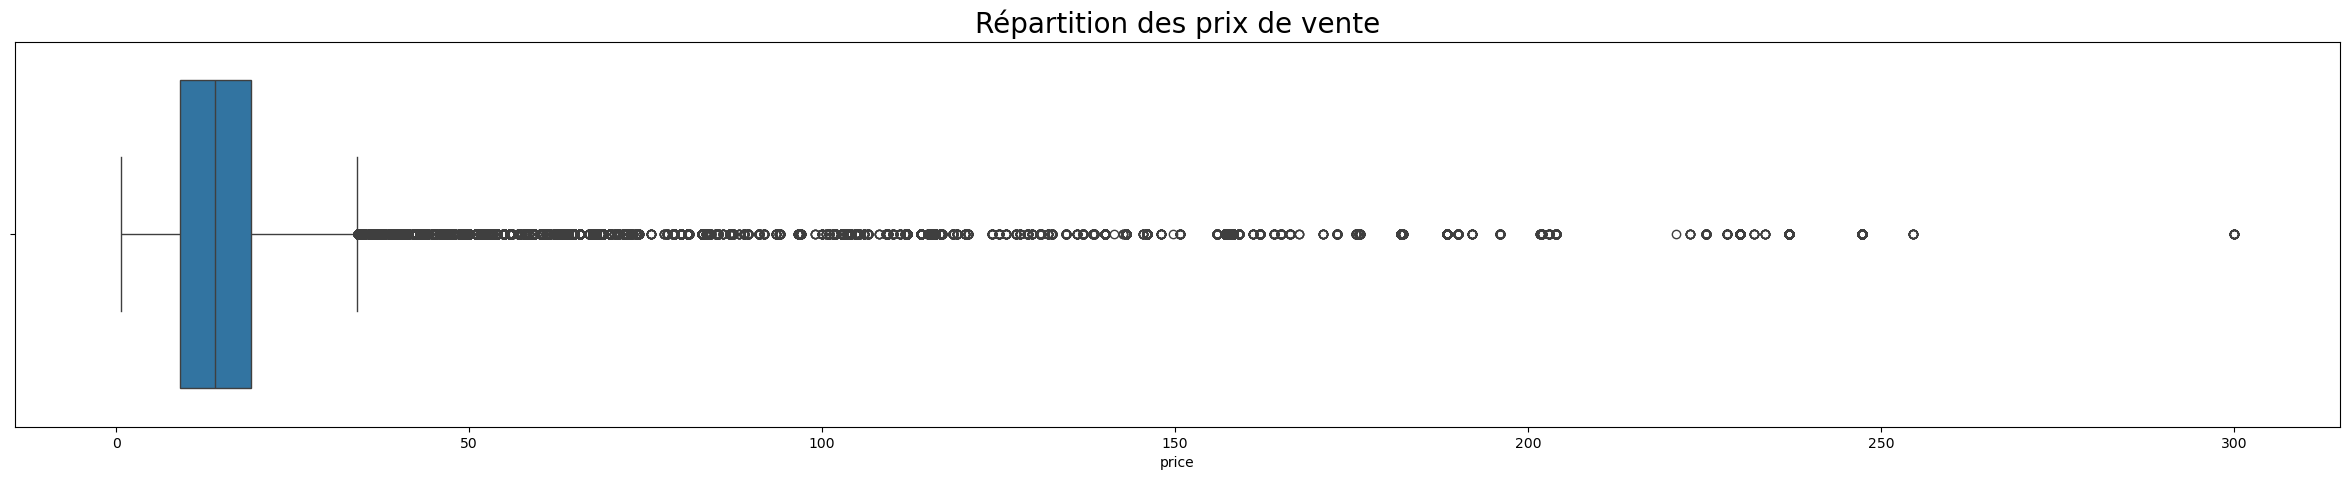

In [39]:
# Vérification des valeurs extrêmes (outliers)


## Création d'un boxplot pour visualiser la distribution des prix

plt.figure(figsize = (30, 5))                                                   # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
plt.title("Répartition des prix de vente", fontsize = 20)                       # ajoute un titre au graphique
boxplot_prix = sns.boxplot(data = df_merge, x = "price")                        # création de la boite à moustache 


## Calcul de l'Intervalle Interquartile pour détecter les valeurs extrêmes

Q1_prix = df_merge.describe().loc["25%", "price"]                               # récupère la valeur de Q1 (seuil maximum du 1er quartile (contenant 25% des valeurs de prix du DF)
Q3_prix = df_merge.describe().loc["75%", "price"]                               # récupère la valeur de Q3 (seuil maximum du 3ème quartile (contenant 75% des valeurs de prix du DF)
IQR_prix = round((Q3_prix - Q1_prix), 2)                                        # calcul de l'écart interquartile (différence entre les seuils du 1er quartile (Q1, 25%) et du 3ème quartile (Q3, 75%), au moins 50 % des valeurs doivent être comprises dans cet intervalle
print(f"L'intervalle interquartile des prix est de {IQR_prix}.")

outlier_Q1_prix = round((Q1_prix - (1.5 * IQR_prix)), 2)                        # calcul de la valeur limite pour les outliers inférieurs
outlier_Q3_prix = round((Q3_prix + (1.5 * IQR_prix)), 2)                        # calcul de la valeur limite pour les outliers supérieurs
print(f"\nLes 'outliers' sont les prix qui se situent en dehors des valeurs suivantes (exclues) : {outlier_Q1_prix} € et {outlier_Q3_prix} €.")   # outlier = valeur qui ne se situe pas dans l'intervalle interquartile (entre Q1 et Q3)

outliers_prix = copy.deepcopy(df_merge.loc[:, ["id_prod", "price", "categ"]])   # crée un nouveau dataframe contenant un copie des valeurs du df_merge pour faire l'analyse sans risquer de compromettre les données initiales
outliers_prix = outliers_prix[(outliers_prix["price"] < outlier_Q1_prix) | (outliers_prix["price"] > outlier_Q3_prix)]  # sélectionne les lignes dont les valeurs de prix sont uniquement inférieures ou supérieures aux limites fixées par l'IQR
nb_outliers_prix = outliers_prix["id_prod"].nunique()                           # compte le nombre de prix considérés 'outliers'
nb_total_prod = df_merge["id_prod"].nunique()                                   # compte le nombre total de produits vendus
prop_outliers_prix = round(((nb_outliers_prix * 100) / nb_total_prod), 2)       # calcule la proportion des prix extrêmes dans la totalité des produits vendus
print(f"\nIl y a {nb_outliers_prix} produits dont les prix de ventes sont considérés extrêmes (outliers), ce qui représente {prop_outliers_prix} % du nombre total de produits vendus sur le site.")

category = df_merge["categ"].dropna().unique().tolist()                         # récupère les différentes valeurs uniques de catégories et les stocke dans une liste
for cat in category :                                                           # création d'une boucle qui calcule le nombre de produits et récupère la liste des prix extrêmes en fonction de la catégorie des produits
    prix_cat = outliers_prix[outliers_prix["categ"] == cat]["price"]            # récupère les prix extrêmes uniquement de la catégorie demandée (cat)
    nb_prix_categ = prix_cat.nunique()                                          # compte le nombre de prix extrêmes présents dans cette catégorie
    liste_prix_categ = prix_cat.drop_duplicates().sort_values().tolist()        # récupère la liste des prix extrêmes présents dans cette catégorie
    print(f"\nIl y a {nb_prix_categ} prix extrêmes qui correspondent à la catégorie {cat} :")
    print(f"{liste_prix_categ}")

## Les prix extrêmes (outliers) sont tous situés en dehors de la limite supérieure (34,21 €). Nous savons, d'après la partie Nettoyage des données, qu'il n'y a pas de prix négatifs, donc pas de prix en dessous de la limite inférieure (-6,14€).
## Ils sont repartis entre les 3 catégories mais ne semblent pas dépendre de ces catégories.
## Il est possible que ce soit donc des produits correspondant à des livres rares, anciens, d'art, de luxe, ou encore de collection, ou peut être des accessoires onéreux (tablette liseuse par exemple). 
## Ils réprésenteraient donc une catégorie particulière et à part entière des produits vendus sur le site.
## Il est donc préférable de les conserver pour les futures analyses, afin de ne perdre aucun produit vendu.


<div style="border: 1px solid RGB(198,131,70);" >
<h3 style="margin: auto; padding: 20px; color: RGB(214,181,136); ">4.2 - Age du client</h3>
</div>

In [40]:
# Création de l'Age du client au moment de la session d'achat

## J'ai choisi d'utiliser l'Age du client à la date de session plutôt que son Age à la date d'analyse (2023) car cela est plus pertinent pour les analyses à effectuer en fonction de l'Age du client.
## En effet, selon la date à laquelle la session d'achat a été effectuée, le client ne se trouvera peut être plus dans la même catégorie d'âge d'une année, voir d'un mois, et donc d'une session sur l'autre.
## Comme nous n'avons pas le détail du Jour et du Mois pour la Date de naissance du client. Nous allons calculer la différence uniquement entre les 2 années (Naissance et Date de session), 
## en gardant donc en considération qu'il existera alors un léger biais dans l'Age du client au moment de la transaction.

df_merge["age"] =  df_merge["date"].dt.year.astype("Int64") - df_merge["birth"]     # récupère l'année de la date de session (convertie en nombre entier "Int64") et retranche l'année de naissance du client

df_merge.drop(columns = "birth", inplace = True)                                    # supprime la colonne Birth car nous n'en aurons plus besoin en l'état (permet également de supprimer une donnée à caractère personnel pour le RGPD)

df_merge.head(2)                                                                    # affichage des 2 premières lignes du dataframe pour vérifier que le calcul et la suppression sont corrects


,client_id,sex,id_prod,date,session_id,price,categ,age
0,c_1004,m,0_0,2021-03-02,s_908,3.75,0,48
1,c_1011,f,0_0,2022-02-18,s_167174,3.75,0,23


L'intervalle interquartile des prix est de 16.0.

Les 'outliers' sont les âges qui se situent en dehors des valeurs suivantes (exclues) : 11.0 et 75.0.

Il y a 360 clients dont l'âge est considéré extrême (outliers), ce qui représente 4.18 % du nombre total de clients de la librairie.

Les âges considérés extrêmes (outliers) sont : [76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94]

L'âge minimum trouvé est 17. L'âge maximum trouvé est 94.

Il y a 0 âges négatifs.


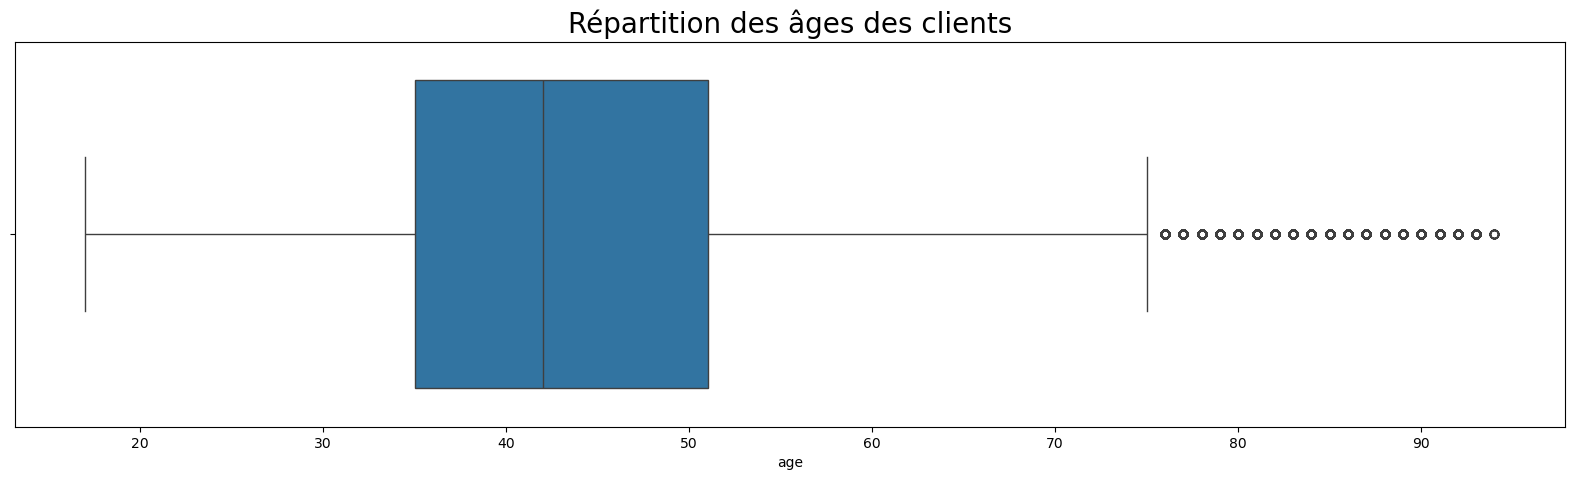

In [41]:
# Vérification des valeurs extrêmes (outliers)


## Création d'un boxplot pour visualiser la distribution des âges

plt.figure(figsize = (20, 5))                                                   # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
plt.title("Répartition des âges des clients", fontsize = 20)                    # ajoute un titre au graphique
boxplot_prix = sns.boxplot(data = df_merge, x = "age")                          # création de la boite à moustache


## Calcul de l'Intervalle Interquartile pour détecter les valeurs extrêmes

Q1_age = df_merge.describe().loc["25%", "age"]                                  # récupère la valeur de Q1 (seuil maximum du 1er quartile (contenant 25% des valeurs de prix du DF)
Q3_age = df_merge.describe().loc["75%", "age"]                                  # récupère la valeur de Q3 (seuil maximum du 3ème quartile (contenant 75% des valeurs de prix du DF)
IQR_age = round((Q3_age - Q1_age), 2)                                           # calcul de l'écart interquartile (différence entre les seuils du 1er quartile (Q1, 25%) et du 3ème quartile (Q3, 75%), au moins 50 % des valeurs doivent être comprises dans cet intervalle
print(f"L'intervalle interquartile des prix est de {IQR_age}.")

outlier_Q1_age = round((Q1_age - (1.5 * IQR_age)), 2)                           # calcul de la valeur limite pour les outliers inférieurs
outlier_Q3_age = round((Q3_age + (1.5 * IQR_age)), 2)                           # calcul de la valeur limite pour les outliers supérieurs
print(f"\nLes 'outliers' sont les âges qui se situent en dehors des valeurs suivantes (exclues) : {outlier_Q1_age} et {outlier_Q3_age}.")   # outlier = valeur qui ne se situe pas dans l'intervalle interquartile (entre Q1 et Q3)

outliers_age = copy.deepcopy(df_merge.loc[:, ["client_id", "age"]])             # crée un nouveau dataframe contenant un copie des valeurs du df_merge pour faire l'analyse sans risquer de compromettre les données initiales
outliers_age = outliers_age[(outliers_age["age"] < outlier_Q1_age) | (outliers_age["age"] > outlier_Q3_age)]  # sélectionne les lignes dont les valeurs de âges sont uniquement inférieures ou supérieures aux limites fixées par l'IQR
nb_outliers_age = outliers_age["client_id"].nunique()                           # compte le nombre d'âges considérés 'outliers'
nb_total_clients = df_merge["client_id"].nunique()                              # compte le nombre total de clients 
prop_outliers_age = round(((nb_outliers_age * 100) / nb_total_clients), 2)      # calcule la proportion des âges extrêmes dans la totalité des clients
print(f"\nIl y a {nb_outliers_age} clients dont l'âge est considéré extrême (outliers), ce qui représente {prop_outliers_age} % du nombre total de clients de la librairie.")
print(f"\nLes âges considérés extrêmes (outliers) sont : {outliers_age["age"].sort_values().unique().tolist()}")

min_age = df_merge["age"].min()                                                 # récupère la valeur minimum trouvée dans la colonne Age
max_age = df_merge["age"].max()                                                 # récupère la valeur maximum trouvée dans la colonne Age
nb_neg_age = df_merge["age"][df_merge["age"] <= 0].nunique()                    # commpte le nombre d'ages négatifs ou nulls trouvés dans la colonne Age
print(f"\nL'âge minimum trouvé est {min_age}. L'âge maximum trouvé est {max_age}.")
print(f"\nIl y a {nb_neg_age} âges négatifs.")

## Les âges extrêmes (outliers) sont tous situés en dehors de la limite supérieure (75 ans). Ils sont donc tous situés dans la future tranche d'âge "65+".
## Les clients correspondant à ces âges font donc partie intégrante des clients du site de vente en ligne de la librairie et constitue bien une catégorie à part entière qui sera utile pour les futures analyses.
## Ils ne font pas partie de catégories d'âge qui pourraient sembler vraiment étrange ( > 100 ans ou < 16 ans par exemple).
## Il est donc préférable de les conserver pour les futures analyses, afin de ne perdre aucun client.

## Nous pouvons également nous poser la question de conserver les clients mineurs (17 ans). 
## Après vérification, il est autorisé de commander en ligne sans autorisation parentale obligatoire à partir de 16 ans (sous réserve du type d'article : exemple alcool interdit aux moins de 18 ans).
## Donc nous pouvons également conserver les clients dont l'âge est de 17 ans car nous vendons des livres.


In [42]:
# Conversion de l'Age du client en Tranche d'Age

## Je décide de convertir l'Age du client en Tranches d'Age car nous en auront besoin pour les analyses demandées par la suite.

df_merge["tranche_age"] = pd.cut(df_merge["age"], bins = [0, 18, 25, 35, 50, 65, 100], labels = ["<18", "18-24", "25-34", "35-49", "50-64", "65+"], right = True) # bins définit les bornes des tranches d'âge, labels définit les valeurs à afficher pour chaque tranche
                                                                                                                                                                  # right = True indique que L'intervalle est ouvert à gauche et fermé à droite
df_merge.head(2)                                                                                                                                                  # affichage des 2 premières lignes du dataframe pour vérifier que lla conversion est correcte


,client_id,sex,id_prod,date,session_id,price,categ,age,tranche_age
0,c_1004,m,0_0,2021-03-02,s_908,3.75,0,48,35-49
1,c_1011,f,0_0,2022-02-18,s_167174,3.75,0,23,18-24


<div style="border: 1px solid RGB(198,131,70);" >
<h3 style="margin: auto; padding: 20px; color: RGB(214,181,136); ">4.3 - Exportation du nouveau tableau sous format Excel</h3>
</div>

In [43]:
# Exportation du nouveau tableau nettoyé / préparé pour utilisation externe (visualisation tableau de bord, analyses autres, etc.)

df_merge.to_excel("Etude_site_Lapage_2023.xlsx", index = False)           # index = False permet de ne pas charger les index du dataframe dans le fichier Excel


<div style="background-color: RGB(214,181,136);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse des indicateurs de vente</h2>
</div>

<div style="border: 1px solid RGB(198,131,70);" >
<h3 style="margin: auto; padding: 20px; color: RGB(214,181,136); ">5.1 - Chiffre d'affaires</h3>
</div>

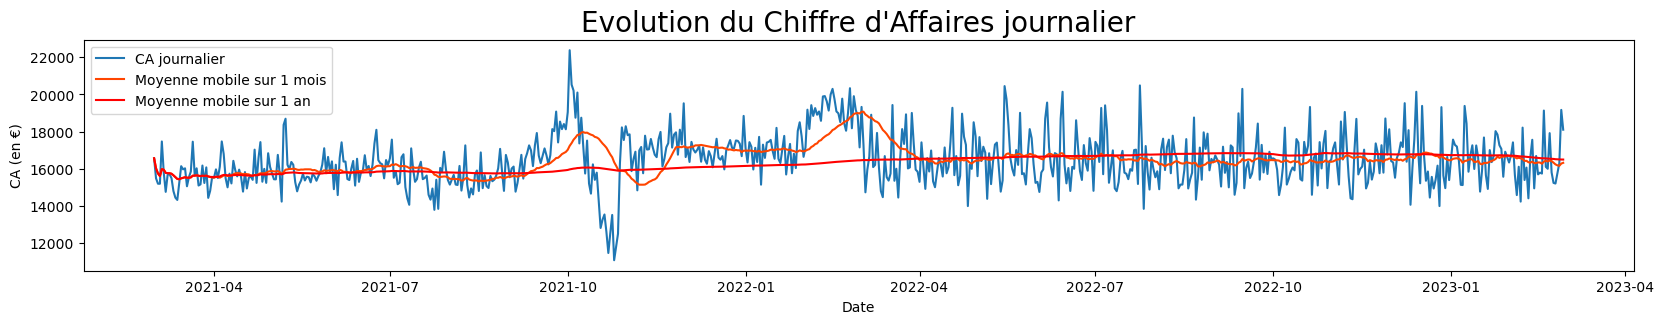

In [44]:
# Evolution du chiffre d'affaires journalier + moyenne mobile par mois et par années

df_CA = copy.deepcopy(df_merge.loc[:, ["date", "price"]])                                                     # crée un nouveau dataframe avec une copie des données du df_merge pour effectuer l'analyse sans risquer de compromettre les données initiales
df_CA = df_CA.groupby("date").sum().reset_index()                                                             # additionne les valeurs de prix par jour pour créer le chiffre d'affaire journalier
df_CA.rename(columns = {"price" : "CA"}, inplace = True)                                                      # renomme la colonne agrégée des prix en Chiffre d'Affaire (CA) pour plus de clarté de l'information observée

df_CA["Moy_mob_mois"] = df_CA["CA"].rolling(window = 30, min_periods = 1).mean()                              # calcule la moyenne mobile par mois
df_CA["Moy_mob_an"] = df_CA["CA"].rolling(window = 365, min_periods = 1).mean()                               # calcule la moyenne mobile par année

plt.figure(figsize = (20, 3))                                                                                 # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
plt.plot(df_CA["date"], df_CA["CA"], label = "CA journalier")                                                 # crée une courbe montrant l'évolution du chiffre d'affaire en fonction des jours
plt.plot(df_CA["date"], df_CA["Moy_mob_mois"], label = "Moyenne mobile sur 1 mois", color = "#FF4500")        # ajoute la courbe de la moyenne mobile sur 1 mois
plt.plot(df_CA["date"], df_CA["Moy_mob_an"], label = "Moyenne mobile sur 1 an", color = "red")                # ajoute la courbe de la moyenne mobile sur 1 année
plt.title("Evolution du Chiffre d'Affaires journalier", fontsize = 20)                                        # ajoute un titre au graphique
plt.xlabel("Date")                                                                                            # ajoute un titre à l'axe des abscisses (horizontal)
plt.ylabel("CA (en €)")                                                                                       # ajoute un titre à l'axe des ordonnées (vertical)
plt.legend()                                                                                                  # affiche la légende du graphique
plt.show()                                                                                                    # affiche le graphique créé
  

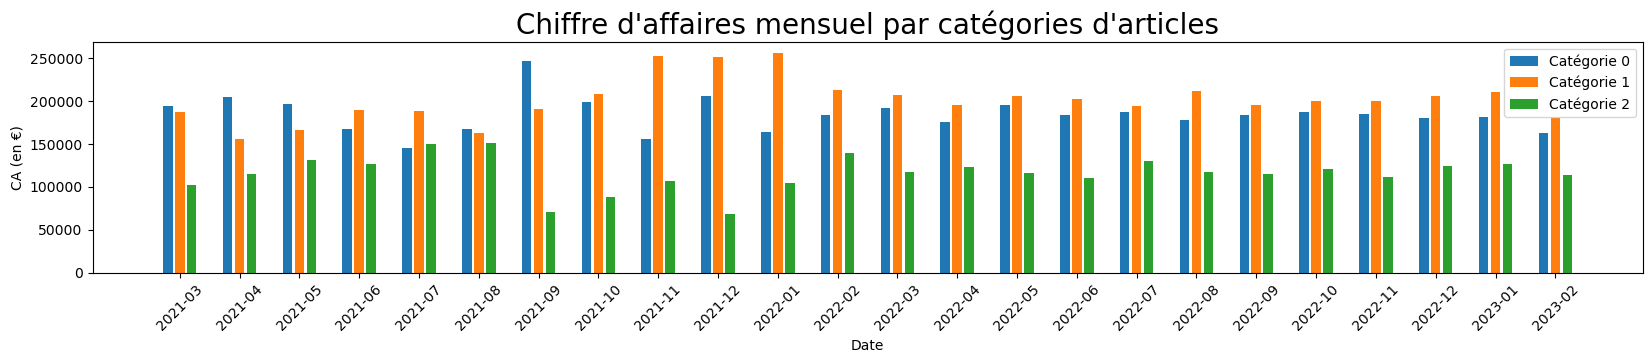

In [45]:
# CA par catégorie (évolution mensuelle)

df_CA_cat_m = copy.deepcopy(df_merge.loc[:, ["categ", "date", "price"]])              # crée un nouveau dataframe avec une copie des données du df_merge pour effectuer l'analyse sans risquer de compromettre les données initiales
df_CA_cat_m.rename(columns = {"price" : "CA"}, inplace = True)                        # renomme la colonne agrégée des prix en Chiffre d'Affaire (CA) pour plus de clarté de l'information observée
df_CA_cat_m["date"] = df_CA_cat_m["date"].dt.to_period("M").dropna().astype(str)      # transformation de la date pour ne conserver que les mois et années
df_CA_cat_m = df_CA_cat_m.groupby(["categ", "date"]).sum().reset_index()              # additionne les valeurs de prix par catégorie et par mois our créer le chiffre d'affaire mensuel de chaque catégorie

CA_cat_0_m = df_CA_cat_m[df_CA_cat_m["categ"] == 0]                                   # récupère les valeurs de CA pour les produits de chaque catégorie
CA_cat_1_m = df_CA_cat_m[df_CA_cat_m["categ"] == 1]
CA_cat_2_m = df_CA_cat_m[df_CA_cat_m["categ"] == 2]

nb_dates_m = len(CA_cat_0_m["date"])                                                  # récupère le nombre de dates pour ajuster l'espacement entre les barres
pos_m = np.arange(0, nb_dates_m * 5, 5)                                               # génère la liste des positions des groupes de barres sur l'axe des abscisses (horizontal)

plt.figure(figsize = (20, 3))                                                         # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
plt.bar([p - 1 for p in pos_m], CA_cat_0_m["CA"], label = "Catégorie 0")              # crée les histogrammes représentant les chiffres d'affaires mensuels de chaque catégories (p in pos permet d'ajuster l'écartement entre les barres)
plt.bar([p for p in pos_m], CA_cat_1_m["CA"], label = "Catégorie 1")
plt.bar([p + 1 for p in pos_m], CA_cat_2_m["CA"], label = "Catégorie 2")
plt.title("Chiffre d'affaires mensuel par catégories d'articles", fontsize = 20)      # ajoute un titre au graphique
plt.xlabel("Date")                                                                    # ajoute un titre à l'axe des abscisses (horizontal)
plt.ylabel("CA (en €)")                                                               # ajoute un titre à l'axe des ordonnées (vertical)
plt.xticks([i for i in pos_m], CA_cat_0_m["date"], rotation = 45)                     # ajoute les dates à l'axe des abscisses (horizontal) et ajuste l'écartement entre les groupes de barres
plt.ylim(bottom = 0)                                                                  # force l'affiche de l'axe des ordonnées à partir de la valeur 0
plt.legend()                                                                          # affiche la légende du graphique
plt.show()                                                                            # affiche le graphique créé


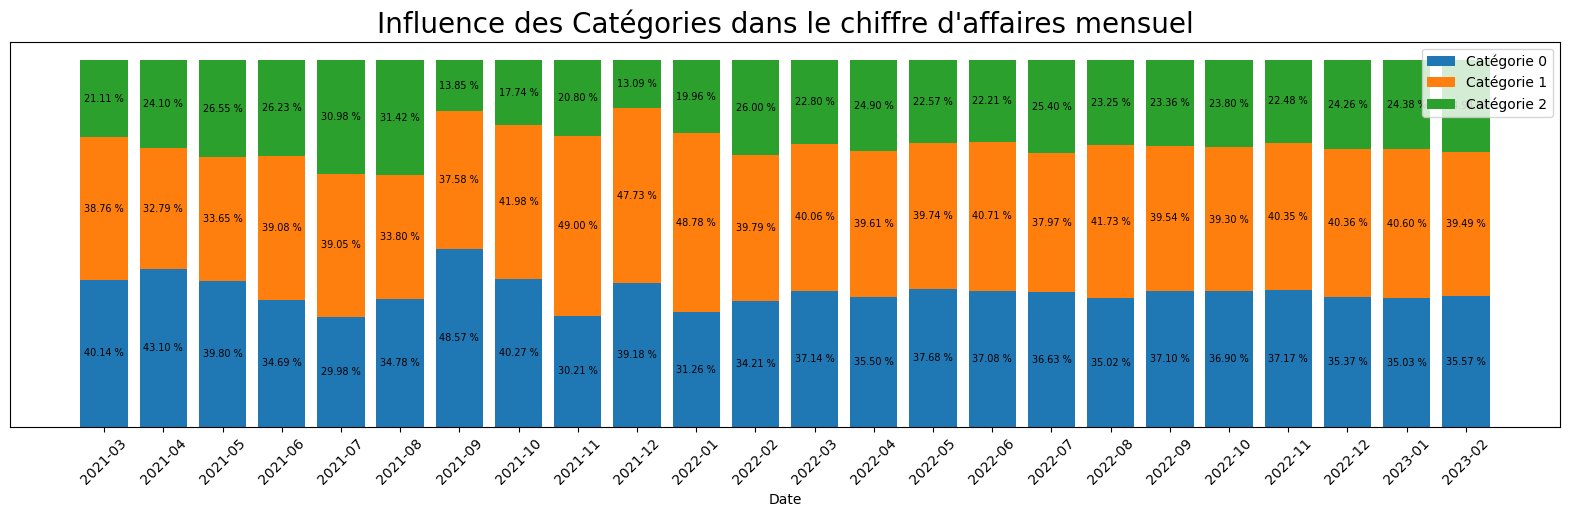

In [46]:
# CA par catégorie (proportion du CA mensuel)

df_CA_total_mois = df_CA_cat_m.loc[:, ["date", "CA"]].groupby("date").sum().reset_index()         # crée un nouveau dataframe dans lequel est calculé le chiffre d'affaire total par mois (toutes catégories confondues)
df_CA_total_mois.rename(columns = {"CA" : "CA_total_mois"}, inplace = True)                       # renomme la colonne agrégée des Chiffre d'Affaire (CA) dans ce dataframe pour plus de clarté de l'information observée
df_CA_cat_m = pd.merge(df_CA_cat_m, df_CA_total_mois, on = "date", how = "left")                  # fusion des 2 dataframes par la date et de façon à conserver toutes les lignes du tableau initial (df_CA_cat_m) additionnées de l'info sur le CA_total du mois
df_CA_cat_m["%_CA_mois"] = round(df_CA_cat_m["CA"] * 100 / df_CA_cat_m["CA_total_mois"], 2)       # calcul la proportion du chiffre d'affaire de chaque catégorie par rapport au CA total du mois

prop_CA_cat_0_m = df_CA_cat_m[df_CA_cat_m["categ"] == 0].set_index("date")["%_CA_mois"]           # récupère les valeurs de %_CA_mois pour chaque catégorie
prop_CA_cat_1_m = df_CA_cat_m[df_CA_cat_m["categ"] == 1].set_index("date")["%_CA_mois"]
prop_CA_cat_2_m = df_CA_cat_m[df_CA_cat_m["categ"] == 2].set_index("date")["%_CA_mois"]

df_plot_m = pd.DataFrame({"Cat_0_m": prop_CA_cat_0_m, "Cat_1_m": prop_CA_cat_1_m, "Cat_2_m": prop_CA_cat_2_m})    # crée un nouveau dataFrame unique avec toutes les catégories
df_plot_m = df_plot_m.dropna()                                                                                    # garde uniquement les dates où toutes les catégories ont des données de chiffre d'affaires
dates_m = df_plot_m.index                                                                                         # récupère les dates à afficher sur le graphique

plt.figure(figsize = (20, 5))                                                                     # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars1 = plt.bar(dates_m, df_plot_m["Cat_0_m"], label = "Catégorie 0")                             # crée les barres empilées représentant les proportions des chiffres d'affaires mensuels de chaque catégories par rapport au total du mois
bars2 = plt.bar(dates_m, df_plot_m["Cat_1_m"], bottom = df_plot_m["Cat_0_m"], label = "Catégorie 1") 
bars3 = plt.bar(dates_m, df_plot_m["Cat_2_m"], bottom = df_plot_m["Cat_0_m"] + df_plot_m["Cat_1_m"], label = "Catégorie 2")

bars_series = [(bars1, np.zeros(len(bars1))), (bars2, df_plot_m["Cat_0_m"]), (bars3, df_plot_m["Cat_0_m"] + df_plot_m["Cat_1_m"])]
for bars, bottom in bars_series :
    for bar, b in zip(bars, bottom) :
        height = bar.get_height()                                                                 # Mesure la taille de la barre  
        x_pos = bar.get_x() + bar.get_width() / 2                                                 # récupère la position horizontale (centre de la barre)
        y_pos = b + height / 2                                                                    # récupère la position verticale (base de la barre + moitié de sa hauteur)
        plt.text(x_pos, y_pos, f"{height:.2f} %", ha = "center", va = "center", fontsize = 7)     # ajuste les positions horizontale et verticale, et indique le format du texte à afficher (valeur avec 2 décimales)

plt.title("Influence des Catégories dans le chiffre d'affaires mensuel", fontsize = 20)           # ajoute un titre au graphique
plt.xlabel("Date")                                                                                # ajoute un titre à l'axe des abscisses (horizontal)
plt.xticks(rotation = 45)
plt.gca().get_yaxis().set_visible(False)                                                          # supprime l'affichage de l'axe des ordonnées (inutile ici)  
plt.legend()                                                                                      # affiche la légende du graphique
plt.show()                                                                                        # affiche le graphique créé


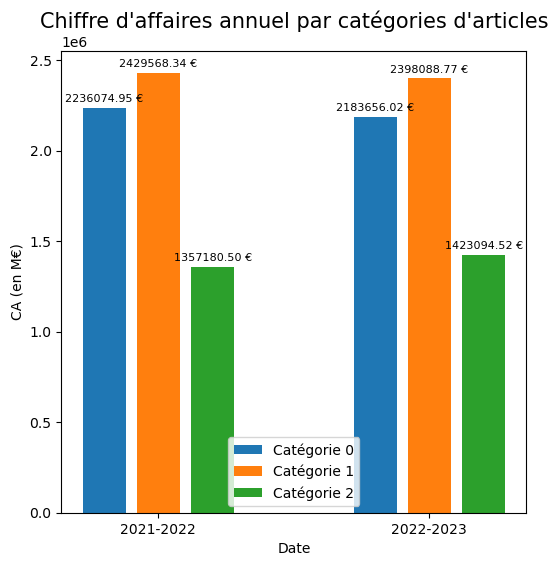

In [47]:
# CA par catégorie (évolution annuelle)

df_CA_cat_y = copy.deepcopy(df_merge.loc[:, ["categ", "date", "price"]])              # crée un nouveau dataframe avec une copie des données du df_merge pour effectuer l'analyse sans risquer de compromettre les données initiales
df_CA_cat_y.rename(columns = {"price" : "CA"}, inplace = True)                        # renomme la colonne agrégée des prix en Chiffre d'Affaire (CA) pour plus de clarté de l'information observée
df_CA_cat_y = df_CA_cat_y.dropna()                                                    # supprime les lignes vides

start_date = df_CA_cat_y["date"].min()                                                                       # récupère la date de départ pour le calcul des périodes de 1 an 
                                                                                                             # => les données ne commencent pas au 01/01/2021 et ne finissent pas au 31/12/2022, nous ne pouvons donc pas utiliser les années calendaires classiques           
df_CA_cat_y["periode"] = (df_CA_cat_y["date"] - start_date).dt.days                                          # compte le nombre de jours entre la date selectionnée et la date de départ
df_CA_cat_y["periode"] = df_CA_cat_y["periode"].apply(lambda x : "2021-2022" if x <= 365 else "2022-2023")   # affiche le nom de la période de 1 an correspondante en fonction du nombre de jours écoulés depuis la date de départ (base 365 jours = 1 an)
df_CA_cat_y.drop(columns = "date", inplace = True)                                                           # supprime la colonne car nous n'en auront plus besoin par la suite pour cette analyse

df_CA_cat_y = df_CA_cat_y.groupby(["categ", "periode"]).sum().reset_index()           # additionne les valeurs de prix par catégorie et par période de 1 an pour créer le chiffre d'affaires annuel de chaque catégorie

CA_cat_0_y = df_CA_cat_y[df_CA_cat_y["categ"] == 0]                                   # récupère les valeurs de CA pour les produits de chaque catégorie
CA_cat_1_y = df_CA_cat_y[df_CA_cat_y["categ"] == 1]
CA_cat_2_y = df_CA_cat_y[df_CA_cat_y["categ"] == 2]

nb_dates_y = len(CA_cat_0_y["periode"])                                               # récupère le nombre de dates pour ajuster l'espacement entre les barres
pos_y = np.arange(0, nb_dates_y * 5, 5)                                               # génère la liste des positions des groupes de barres sur l'axe des abscisses (horizontal)

plt.figure(figsize = (6, 6))                                                          # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars1 = plt.bar([p - 1 for p in pos_y], CA_cat_0_y["CA"], label = "Catégorie 0")      # crée les histogrammes représentant les chiffres d'affaires annuels de chaque catégories (p in pos permet d'ajuster l'écartement entre les barres)
bars2 = plt.bar([p for p in pos_y], CA_cat_1_y["CA"], label = "Catégorie 1")
bars3 = plt.bar([p + 1 for p in pos_y], CA_cat_2_y["CA"], label = "Catégorie 2")

bars_series = [bars1, bars2, bars3]
for bars in bars_series :
    for bar in bars : 
        height = bar.get_height()                                                     # Mesure la taille de la barre  
        x_pos = bar.get_x() + bar.get_width() / 2                                     # récupère la position horizontale (centre de la barre)
        y_pos = height + 50000                                                        # récupère la position verticale (sommet de la barre + décalage)
        plt.text(x_pos, y_pos, f"{height:.2f} €", ha = "center", va = "center", fontsize = 8)         # ajuste les positions horizontale et verticale, et indique le format du texte à afficher (valeur avec 2 décimales)

plt.title("Chiffre d'affaires annuel par catégories d'articles", fontsize = 15)       # ajoute un titre au graphique
plt.xlabel("Date")                                                                    # ajoute un titre à l'axe des abscisses (horizontal)
plt.ylabel("CA (en M€)")                                                              # ajoute un titre à l'axe des ordonnées (vertical)
plt.xticks([i for i in pos_y], CA_cat_0_y["periode"])                                 # ajoute les dates à l'axe des abscisses (horizontal) et ajuste l'écartement entre les groupes de barres
plt.ylim(bottom = 0)                                                                  # force l'affiche de l'axe des ordonnées à partir de la valeur 0
plt.legend()                                                                          # affiche la légende du graphique
plt.show()                                                                            # affiche le graphique créé


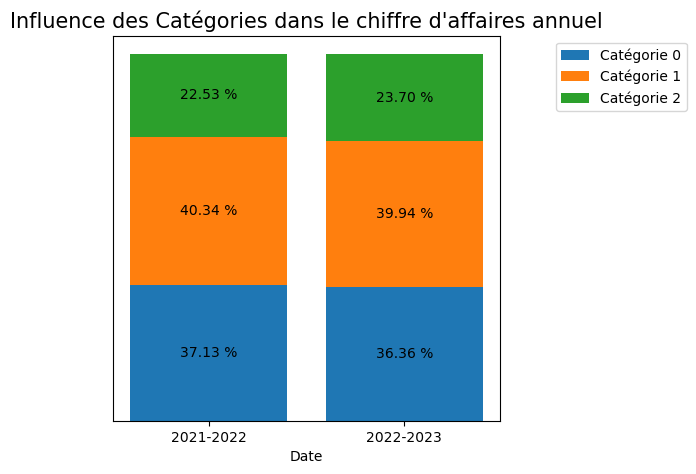

In [48]:
# CA par catégorie (proportion du CA annuel)

df_CA_total_an = df_CA_cat_y.loc[:, ["periode", "CA"]].groupby("periode").sum().reset_index()     # crée un nouveau dataframe dans lequel est calculé le chiffre d'affaire total par année (toutes catégories confondues)
df_CA_total_an.rename(columns = {"CA" : "CA_total_annee"}, inplace = True)                        # renomme la colonne agrégée des Chiffre d'Affaire (CA) dans ce dataframe pour plus de clarté de l'information observée
df_CA_cat_y = pd.merge(df_CA_cat_y, df_CA_total_an, on = "periode", how = "left")                 # fusion des 2 dataframes par la date et de façon à conserver toutes les lignes du tableau initial (df_CA_cat_y) additionnées de l'info sur le CA_total de l'année
df_CA_cat_y["%_CA_annee"] = round(df_CA_cat_y["CA"] * 100 / df_CA_cat_y["CA_total_annee"], 2)     # calcul la proportion du chiffre d'affaire de chaque catégorie par rapport au CA total de l'année

prop_CA_cat_0_y = df_CA_cat_y[df_CA_cat_y["categ"] == 0].set_index("periode")["%_CA_annee"]       # récupère les valeurs de %_CA_annee pour chaque catégorie
prop_CA_cat_1_y = df_CA_cat_y[df_CA_cat_y["categ"] == 1].set_index("periode")["%_CA_annee"]
prop_CA_cat_2_y = df_CA_cat_y[df_CA_cat_y["categ"] == 2].set_index("periode")["%_CA_annee"]

df_plot_y = pd.DataFrame({"Cat_0_y": prop_CA_cat_0_y, "Cat_1_y": prop_CA_cat_1_y, "Cat_2_y": prop_CA_cat_2_y})    # crée un nouveau dataFrame unique avec toutes les catégories
df_plot_y = df_plot_y.dropna()                                                                                    # garde uniquement les dates où toutes les catégories ont des données de chiffre d'affaires
dates_y = df_plot_y.index                                                                                         # récupère les dates à afficher sur le graphique

plt.figure(figsize = (5, 5))                                                                      # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars1 = plt.bar(dates_y, df_plot_y["Cat_0_y"], label = "Catégorie 0")                             # crée les barres empilées représentant les proportions des chiffres d'affaires annuels de chaque catégories par rapport au total de l'année
bars2 = plt.bar(dates_y, df_plot_y["Cat_1_y"], bottom = df_plot_y["Cat_0_y"], label = "Catégorie 1") 
bars3 = plt.bar(dates_y, df_plot_y["Cat_2_y"], bottom = df_plot_y["Cat_0_y"] + df_plot_y["Cat_1_y"], label = "Catégorie 2")

bars_series = [(bars1, np.zeros(len(bars1))), (bars2, df_plot_y["Cat_0_y"]), (bars3, df_plot_y["Cat_0_y"] + df_plot_y["Cat_1_y"])]
for bars, bottom in bars_series :
    for bar, b in zip(bars, bottom) :
        height = bar.get_height()                                                                 # Mesure la taille de la barre  
        x_pos = bar.get_x() + bar.get_width() / 2                                                 # récupère la position horizontale (centre de la barre)
        y_pos = b + height / 2                                                                    # récupère la position verticale (base de la barre + moitié de sa hauteur)
        plt.text(x_pos, y_pos, f"{height:.2f} %", ha = "center", va = "center")                   # ajuste les positions horizontale et verticale, et indique le format du texte à afficher (valeur avec 2 décimales)

plt.title("Influence des Catégories dans le chiffre d'affaires annuel", fontsize = 15)            # ajoute un titre au graphique
plt.xlabel("Date")                                                                                # ajoute un titre à l'axe des abscisses (horizontal)
plt.gca().get_yaxis().set_visible(False)                                                          # supprime l'affichage de l'axe des ordonnées (inutile ici)  
plt.legend(bbox_to_anchor = (1.5, 1), loc = "upper right")                                        # affiche la légende du graphique (décalée en dehors de la zone de graphique en haut à droite)
plt.show()                                                                                        # affiche le graphique créé


<div style="border: 1px solid RGB(198,131,70);" >
<h3 style="margin: auto; padding: 20px; color: RGB(214,181,136); ">5.2 - Clients</h3>
</div>

<div style="border: 1px solid RGB(198,131,70);" >
<h4 style="margin: auto; padding: 20px; color: RGB(214,181,136); ">5.2.1 - Nombre et Paniers clients</h4>
</div>

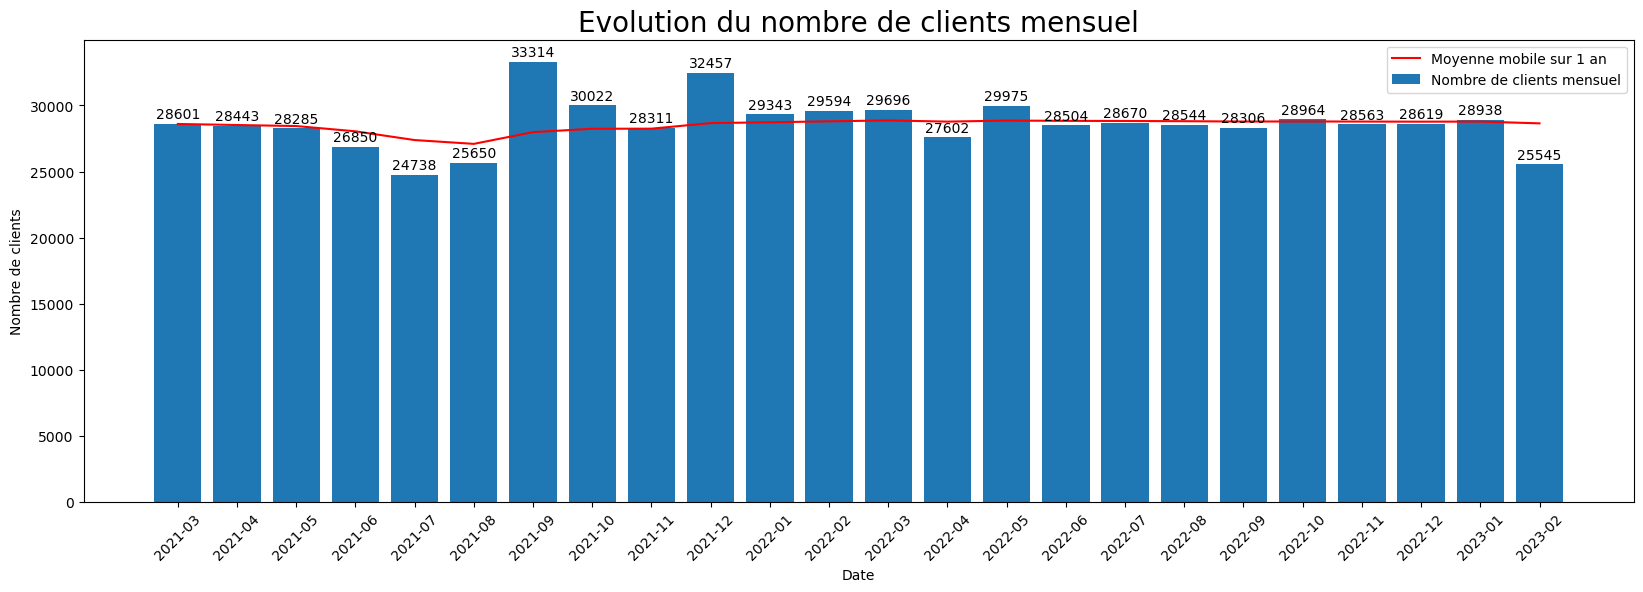

In [49]:
# Nombre de clients mensuel + moyenne mobile par par années

nb_clients = copy.deepcopy(df_merge.loc[:, ["client_id", "date"]])                                                   # crée un nouveau dataframe avec une copie des données du df_merge pour effectuer l'analyse sans risquer de compromettre les données initiales
nb_clients["date"] = nb_clients["date"].dt.to_period("M").dropna().astype(str)                                       # transformation de la date pour ne conserver que les mois
nb_clients = nb_clients.groupby("date").count().reset_index()                                                        # compte les lignes de clients par mois pour créer le nombre de clients mensuel
nb_clients.rename(columns = {"client_id" : "nb_clients"}, inplace = True)                                            # renomme la colonne agrégée des client_id en Nombre de Clients pour plus de clarté de l'information observée

nb_clients["Moy_mob_an"] = nb_clients["nb_clients"].rolling(window = 365, min_periods = 1).mean()                    # calcule la moyenne mobile par années

plt.figure(figsize = (20, 6))                                                                                        # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars = plt.bar(nb_clients["date"], nb_clients["nb_clients"], label = "Nombre de clients mensuel")                    # crée un histogramme montrant l'évolution du nombre de clients en fonction des mois
for bar in bars :
    height = bar.get_height()                                                                                        # Mesure la taille de la barre  
    x_pos = bar.get_x() + bar.get_width() / 2                                                                        # récupère la position horizontale (centre de la barre)
    y_pos = height + 700                                                                                             # récupère la position verticale (sommet de la barre + décalage vers le haut)
    plt.text(x_pos, y_pos, f"{height}", ha = "center", va = "center")                                                # ajuste les positions horizontale et verticale, et indique le format et la couleur du texte à afficher (valeur avec 2 décimales)
plt.plot(nb_clients["date"], nb_clients["Moy_mob_an"], label = "Moyenne mobile sur 1 an", color = "red")             # ajoute la courbe de la moyenne mobile sur 1 année
plt.title("Evolution du nombre de clients mensuel", fontsize = 20)                                                   # ajoute un titre au graphique
plt.xlabel("Date")                                                                                                   # ajoute un titre à l'axe des abscisses (horizontal)
plt.xticks(rotation = 45)
plt.ylabel("Nombre de clients")                                                                                      # ajoute un titre à l'axe des ordonnées (vertical)
plt.legend()                                                                                                         # affiche la légende du graphique
plt.show()                                                                                                           # affiche le graphique créé


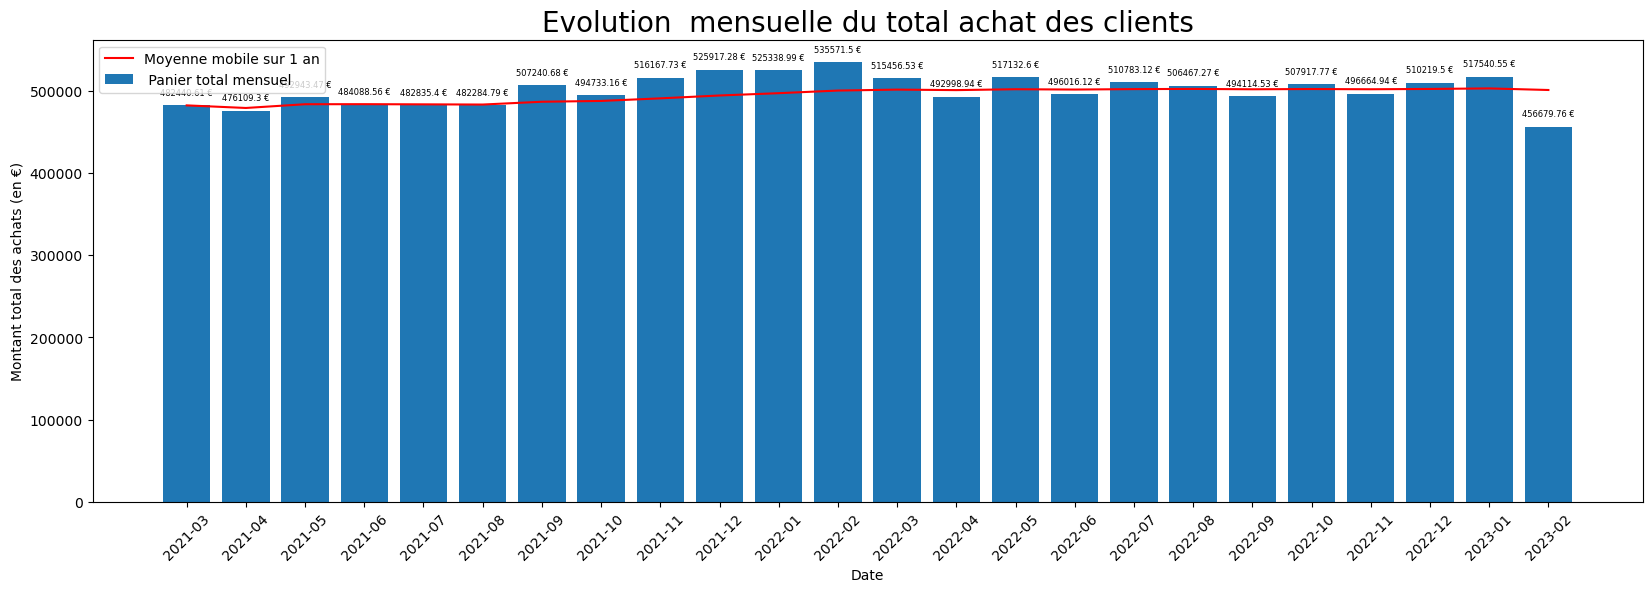

In [50]:
# Evolution mensuelle du total achat des clients

panier_clients = copy.deepcopy(df_merge.loc[:, ["client_id", "date", "price"]])                              # crée un nouveau dataframe avec une copie des données du df_merge pour effectuer l'analyse sans risquer de compromettre les données initiales
panier_clients["date"] = panier_clients["date"].dt.to_period("M").dropna().astype(str)                       # transformation de la date pour ne conserver que les mois et années
panier_clients = panier_clients.groupby(["client_id", "date"]).sum().reset_index()                           # agrégation des données en fonction du client et de la date pour obtenir le montant total de son panier mensuel
panier_clients.rename(columns = {"price" : "panier_total"}, inplace = True)                                  # renomme la colonne des prix en Panier_total pour plus de clarté des informations observées 

panier_mois = panier_clients.loc[:, ["date", "panier_total"]]                                                # récupère les colonnes concernant le client et son panier total mensuel dans un nouveau dataframe
panier_mois = panier_mois.groupby(["date"]).sum().round(2).reset_index()                                     # agrégation des données en fonction de la date pour obtenir le montant total des paniers clients (tout clients confondus)

panier_mois["Moy_mob_an"] = panier_mois["panier_total"].rolling(window = 365, min_periods = 1).mean()        # calcule la moyenne mobile par années

plt.figure(figsize = (20, 6))                                                                                # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars = plt.bar(panier_mois["date"], panier_mois["panier_total"], label = " Panier total mensuel")            # crée un histogramme montrant l'évolution du panier total en fonction des mois
for bar in bars :
    height = bar.get_height()                                                                                # Mesure la taille de la barre  
    x_pos = bar.get_x() + bar.get_width() / 2                                                                # récupère la position horizontale (centre de la barre)
    y_pos = height + 15000                                                                                   # récupère la position verticale (sommet de la barre + décalage vers le bas)
    plt.text(x_pos, y_pos, f"{height} €", ha = "center", va = "center", fontsize = 6)                        # ajuste les positions horizontale et verticale, et indique le texte à afficher 
plt.plot(panier_mois["date"], panier_mois["Moy_mob_an"], label = "Moyenne mobile sur 1 an", color = "red")   # ajoute la courbe de la moyenne mobile sur 1 année
plt.title("Evolution  mensuelle du total achat des clients", fontsize = 20)                                  # ajoute un titre au graphique
plt.xlabel("Date")                                                                                           # ajoute un titre à l'axe des abscisses (horizontal)
plt.xticks(rotation = 45)
plt.ylabel("Montant total des achats (en €)")                                                                # ajoute un titre à l'axe des ordonnées (vertical)
plt.legend()                                                                                                 # affiche la légende du graphique
plt.show()                                                                                                   # affiche le graphique créé


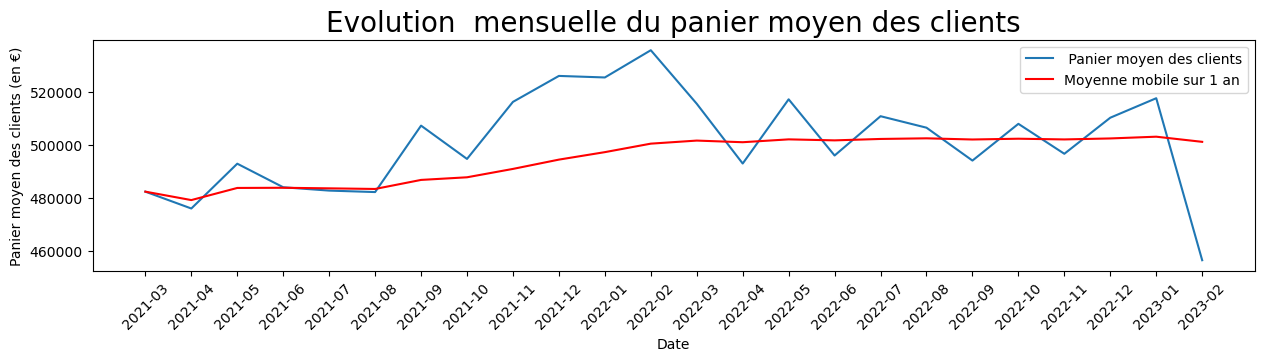

In [51]:
# Evolution du panier moyen des clients 

panier_moy = panier_clients.loc[:, ["date", "panier_total"]]                                                 # récupère les colonnes concernant le client et son panier total mensuel dans un nouveau dataframe
panier_moy = panier_mois.groupby(["date"]).mean().round(2).reset_index()                                     # agrégation des données en fonction de la date pour obtenir le montant moyen des paniers clients (tout clients confondus)
panier_moy.rename(columns = {"panier_total" : "panier_moyen"}, inplace = True)                               # renomme la colonne des prix en Panier_moyen pour plus de clarté des informations observées 

panier_moy["Moy_mob_an"] = panier_moy["panier_moyen"].rolling(window = 365, min_periods = 1).mean()          # calcule la moyenne mobile par années

plt.figure(figsize = (15, 3))                                                                                # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
plt.plot(panier_moy["date"], panier_moy["panier_moyen"], label = " Panier moyen des clients")                # crée une courbe montrant l'évolution du panier moyen des clients en fonction des mois
plt.plot(panier_moy["date"], panier_moy["Moy_mob_an"], label = "Moyenne mobile sur 1 an", color = "red")     # ajoute la courbe de la moyenne mobile sur 1 année
plt.title("Evolution  mensuelle du panier moyen des clients", fontsize = 20)                                 # ajoute un titre au graphique
plt.xlabel("Date")                                                                                           # ajoute un titre à l'axe des abscisses (horizontal)
plt.xticks(rotation = 45)
plt.ylabel("Panier moyen des clients (en €)")                                                                # ajoute un titre à l'axe des ordonnées (vertical)
plt.legend()                                                                                                 # affiche la légende du graphique
plt.show()                                                                                                   # affiche le graphique créé


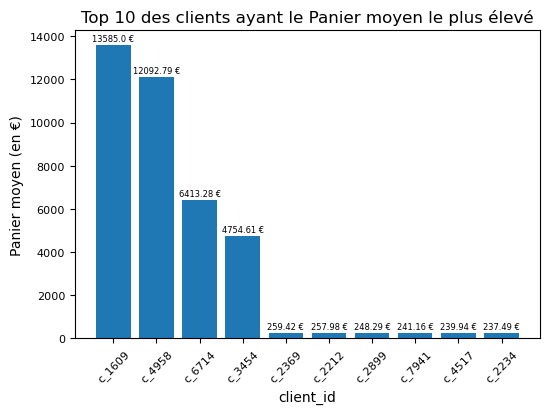

In [52]:
# Top Clients Panier moyen

panier_clients_moy = panier_clients.loc[:, ["client_id", "panier_total"]]                     # récupère les colonnes concernant le client et son panier total mensuel dans un nouveau dataframe
panier_clients_moy = panier_clients_moy.groupby("client_id").mean().round(2).reset_index()    # agrégation des données en fonction du client pour obtenir son panier moyen total (toutes dates confondues)
panier_clients_moy.rename(columns = {"panier_total" : "panier_moyen"}, inplace = True)        # renomme la colonne Panier_total en Panier_moyen pour plus de clarté des informations observées 
panier_clients_moy = panier_clients_moy.sort_values(by = "panier_moyen", ascending = False)   # trie les données des paniers moyens pour qu'ils s'affichent dans l'ordre décroissant (du plus élevé au plus faible)

top_panier_clients = panier_clients_moy.head(10)                                              # récupère les 10 clients ayant le panier moyen le plus élevé
plt.figure(figsize = (6, 4))                                                                  # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars = plt.bar(top_panier_clients["client_id"], top_panier_clients["panier_moyen"])           # crée un histogramme montrant les 10 clients ayant le panier moyen le plus élevé dans l'ordre décroissant (du + au -)
for bar in bars :
    height = bar.get_height()                                                                 # Mesure la taille de la barre  
    x_pos = bar.get_x() + bar.get_width() / 2                                                 # récupère la position horizontale (centre de la barre)
    y_pos = height + 300                                                                      # récupère la position verticale (sommet de la barre + décalage vers le bas)
    plt.text(x_pos, y_pos, f"{height} €", ha = "center", va = "center", fontsize = 6)         # ajuste les positions horizontale et verticale, et indique le texte à afficher 
plt.title("Top 10 des clients ayant le Panier moyen le plus élevé", fontsize = 12)            # ajoute un titre au graphique
plt.xlabel("client_id")                                                                       # ajoute un titre à l'axe des abscisses (horizontal)
plt.xticks(rotation  = 45, fontsize = 8)
plt.ylabel("Panier moyen (en €)")                                                             # ajoute un titre à l'axe des ordonnées (vertical)
plt.yticks(fontsize = 8)
plt.show()                                                                                    # affiche le graphique créé


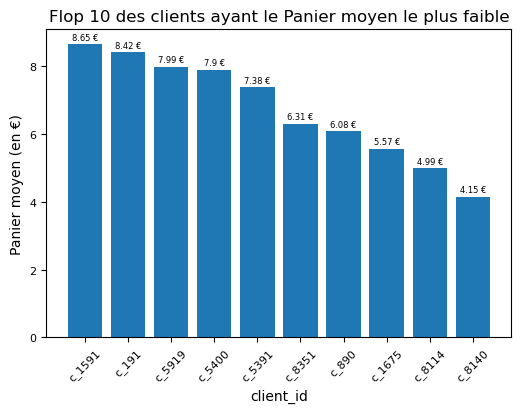

In [53]:
# Flop Clients Panier moyen

flop_panier_clients = panier_clients_moy.tail(10)                                             # récupère les 10 clients ayant le panier moyen le plus bas
plt.figure(figsize = (6, 4))                                                                  # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars = plt.bar(flop_panier_clients["client_id"], flop_panier_clients["panier_moyen"])         # crée un histogramme montrant les 10 clients ayant le panier moyen le plus élevé dans l'ordre décroissant (du + au -)
for bar in bars :
    height = bar.get_height()                                                                 # Mesure la taille de la barre  
    x_pos = bar.get_x() + bar.get_width() / 2                                                 # récupère la position horizontale (centre de la barre)
    y_pos = height + 0.2                                                                      # récupère la position verticale (sommet de la barre + décalage vers le bas)
    plt.text(x_pos, y_pos, f"{height} €", ha = "center", va = "center", fontsize = 6)         # ajuste les positions horizontale et verticale, et indique le texte à afficher 
plt.title("Flop 10 des clients ayant le Panier moyen le plus faible", fontsize = 12)          # ajoute un titre au graphique
plt.xlabel("client_id")                                                                       # ajoute un titre à l'axe des abscisses (horizontal)
plt.xticks(rotation  = 45, fontsize = 8)
plt.ylabel("Panier moyen (en €)")                                                             # ajoute un titre à l'axe des ordonnées (vertical)
plt.yticks(fontsize = 8)
plt.show()                                                                                    # affiche le graphique créé


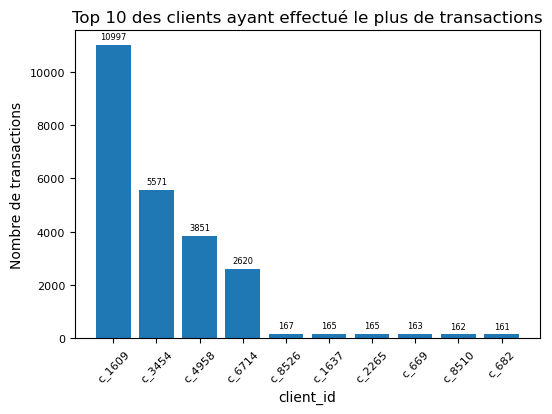

In [54]:
# Top Clients Transactions

trans_clients = copy.deepcopy(df_merge.loc[:, ["client_id", "session_id"]])                          # crée un nouveau dataframe avec une copie des données du df_merge pour effectuer l'analyse sans risquer de compromettre les données initiales
trans_clients = trans_clients.drop_duplicates()                                                      # supprime les lignes dont le binôme client + session_id est présents plusieurs fois            
trans_clients = trans_clients.groupby("client_id").count().reset_index()                             # agrégation des données en fonction du client pour obtenir le nombre de transactions effectuées pour chaque client
trans_clients.rename(columns = {"session_id" : "nb_transactions"}, inplace = True)                   # renomme la colonne des session_id en Nombre de Transactions pour plus de clarté de l'information observée
trans_clients = trans_clients.sort_values(by = "nb_transactions", ascending = False)                 # trie les donnéesdu nombre de transactions pour qu'elles s'affichent dans l'ordre décroissant (du nombre le plus élevé au plus faible)

top_trans_clients = trans_clients.head(10)                                                           # récupère les 10 clients ayant effectué le plus de transactions
plt.figure(figsize = (6, 4))                                                                        # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars = plt.bar(top_trans_clients["client_id"], top_trans_clients["nb_transactions"])                 # crée un histogramme montrant les 10 clients ayant  effectué le plus de transactions dans l'ordre décroissant (du + au -)
for bar in bars :
    height = bar.get_height()                                                                        # Mesure la taille de la barre  
    x_pos = bar.get_x() + bar.get_width() / 2                                                        # récupère la position horizontale (centre de la barre)
    y_pos = height + 300                                                                             # récupère la position verticale (sommet de la barre + décalage vers le bas)
    plt.text(x_pos, y_pos, f"{height}", ha = "center", va = "center", fontsize = 6)                  # ajuste les positions horizontale et verticale, et indique le texte à afficher 
plt.title("Top 10 des clients ayant effectué le plus de transactions", fontsize = 12)                # ajoute un titre au graphique
plt.xlabel("client_id")                                                                              # ajoute un titre à l'axe des abscisses (horizontal)
plt.xticks(rotation  = 45, fontsize = 8)
plt.ylabel("Nombre de transactions")                                                                 # ajoute un titre à l'axe des ordonnées (vertical)
plt.yticks(fontsize = 8)
plt.show()                                                                                           # affiche le graphique créé


21 clients n'ont  effectué aucune transaction : ['c_3443', 'c_4086', 'c_6735', 'c_862', 'c_6930', 'c_3017', 'c_5245', 'c_5223', 'c_7584', 'c_8381', 'c_3526', 'c_587', 'c_3789', 'c_6862', 'c_8253', 'c_1223', 'c_90', 'c_4406', 'c_4358', 'c_4447', 'c_2706'] 



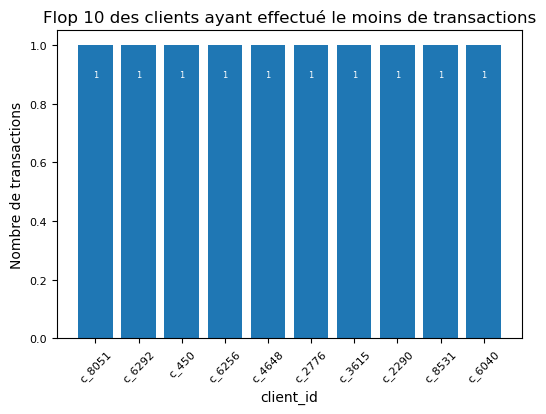

In [55]:
# Flop Clients Transactions
 
flop_trans_clients = trans_clients[trans_clients["nb_transactions"] > 0].tail(10)                                   # récupère les 10 clients ayant effectué le moins de transactions (mais en ayant effectué quand même)
nb_clients_no_trans = trans_clients["client_id"][trans_clients["nb_transactions"] == 0].count()                     # compte le nombre de clients n'ayant effectué aucune transaction
liste_clients_no_trans = trans_clients["client_id"][trans_clients["nb_transactions"] == 0].unique(). tolist()       # récupère la liste des clients n'ayant effectué aucune transaction
print(f"{nb_clients_no_trans} clients n'ont  effectué aucune transaction : {liste_clients_no_trans} \n")

plt.figure(figsize = (6, 4))                                                                                        # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars = plt.bar(flop_trans_clients["client_id"], flop_trans_clients["nb_transactions"])                              # crée un histogramme montrant les 10 clients ayant  effectué le moins de transactions dans l'ordre décroissant (du + au -)
for bar in bars :
    height = bar.get_height()                                                                                       # Mesure la taille de la barre  
    x_pos = bar.get_x() + bar.get_width() / 2                                                                       # récupère la position horizontale (centre de la barre)
    y_pos = height - 0.1                                                                                            # récupère la position verticale (sommet de la barre + décalage vers le bas)
    plt.text(x_pos, y_pos, f"{height}", ha = "center", va = "center", color = "white", fontsize = 6)                # ajuste les positions horizontale et verticale, et indique le texte à afficher 
plt.title("Flop 10 des clients ayant effectué le moins de transactions", fontsize = 12)                             # ajoute un titre au graphique
plt.xlabel("client_id")                                                                                             # ajoute un titre à l'axe des abscisses (horizontal)
plt.xticks(rotation  = 45, fontsize = 8)
plt.ylabel("Nombre de transactions")                                                                                # ajoute un titre à l'axe des ordonnées (vertical)
plt.yticks(fontsize = 8)
plt.show()                                                                                                          # affiche le graphique créé


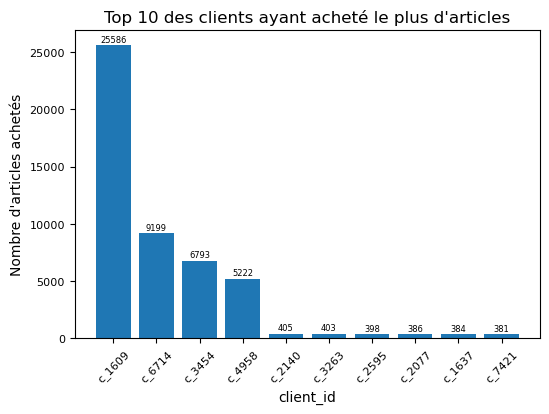

In [56]:
# Top Clients Nombre produits achetés

prod_clients = copy.deepcopy(df_merge.loc[:, ["client_id", "id_prod"]])                  # crée un nouveau dataframe avec une copie des données du df_merge pour effectuer l'analyse sans risquer de compromettre les données initiales
prod_clients = prod_clients.groupby("client_id").count().reset_index()                   # agrégation des données en fonction du client pour obtenir le nombre total d'articles achetés
prod_clients.rename(columns = {"id_prod" : "nb_articles"}, inplace = True)               # renomme la colonne des id_prod en Nombre d'articles pour plus de clarté de l'information observée
prod_clients = prod_clients.sort_values(by = "nb_articles", ascending = False)           # trie les données du nombre d'articles achetés pour qu'elles s'affichent dans l'ordre décroissant (du nombre le plus élevé au plus faible)

top_prod_clients = prod_clients.head(10)                                                 # récupère les 10 clients ayant acheté le plus d'articles
plt.figure(figsize = (6, 4))                                                             # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars = plt.bar(top_prod_clients["client_id"], top_prod_clients["nb_articles"])           # crée un histogramme montrant les 10 clients ayant acheté le plus d'articles dans l'ordre décroissant (du + au -)
for bar in bars :
    height = bar.get_height()                                                            # Mesure la taille de la barre  
    x_pos = bar.get_x() + bar.get_width() / 2                                            # récupère la position horizontale (centre de la barre)
    y_pos = height + 500                                                                 # récupère la position verticale (sommet de la barre + décalage vers le bas)
    plt.text(x_pos, y_pos, f"{height}", ha = "center", va = "center", fontsize = 6)      # ajuste les positions horizontale et verticale, et indique le texte à afficher 
plt.title("Top 10 des clients ayant acheté le plus d'articles", fontsize = 12)           # ajoute un titre au graphique
plt.xlabel("client_id")                                                                  # ajoute un titre à l'axe des abscisses (horizontal)
plt.xticks(rotation  = 45, fontsize = 8)
plt.ylabel("Nombre d'articles achetés")                                                  # ajoute un titre à l'axe des ordonnées (vertical)
plt.yticks(fontsize = 8)
plt.show()                                                                               # affiche le graphique créé


21 clients n'ont acheté aucun article : ['c_8253', 'c_2706', 'c_4447', 'c_3443', 'c_862', 'c_3789', 'c_90', 'c_587', 'c_4086', 'c_3526', 'c_6930', 'c_5245', 'c_4406', 'c_6735', 'c_5223', 'c_3017', 'c_6862', 'c_1223', 'c_7584', 'c_8381', 'c_4358'] 



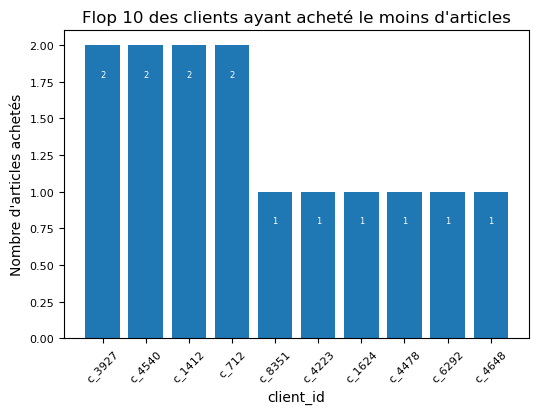

In [57]:
# Flop Clients Nombre produits achetés

flop_prod_clients = prod_clients[prod_clients["nb_articles"] > 0].tail(10)                                   # récupère les 10 clients ayant acheté le moins d'articles (mis en ayant acheté quand même)
nb_clients_no_prod = prod_clients["client_id"][prod_clients["nb_articles"] == 0].count()                     # compte le nombre de clients n'ayant acheté aucun article
liste_clients_no_prod = prod_clients["client_id"][prod_clients["nb_articles"] == 0].unique(). tolist()       # récupère la liste des clients n'ayant acheté aucun article
print(f"{nb_clients_no_prod} clients n'ont acheté aucun article : {liste_clients_no_prod} \n")

plt.figure(figsize = (6, 4))                                                                                 # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars = plt.bar(flop_prod_clients["client_id"], flop_prod_clients["nb_articles"])                             # crée un histogramme montrant les 10 clients ayant acheté le moins d'article dans l'ordre décroissant (du + au -)
for bar in bars :
    height = bar.get_height()                                                                                # Mesure la taille de la barre  
    x_pos = bar.get_x() + bar.get_width() / 2                                                                # récupère la position horizontale (centre de la barre)
    y_pos = height - 0.2                                                                                     # récupère la position verticale (sommet de la barre + décalage vers le bas)
    plt.text(x_pos, y_pos, f"{height}", ha = "center", va = "center", color = "white", fontsize = 6)         # ajuste les positions horizontale et verticale, et indique le texte à afficher 
plt.title("Flop 10 des clients ayant acheté le moins d'articles", fontsize = 12)                             # ajoute un titre au graphique
plt.xlabel("client_id")                                                                                      # ajoute un titre à l'axe des abscisses (horizontal)
plt.xticks(rotation  = 45, fontsize = 8)
plt.ylabel("Nombre d'articles achetés")                                                                      # ajoute un titre à l'axe des ordonnées (vertical)
plt.yticks(fontsize = 8)
plt.show()                                                                                                   # affiche le graphique créé


<div style="border: 1px solid RGB(198,131,70);" >
<h4 style="margin: auto; padding: 20px; color: RGB(214,181,136); ">5.2.2 - Profil clients</h4>
</div>

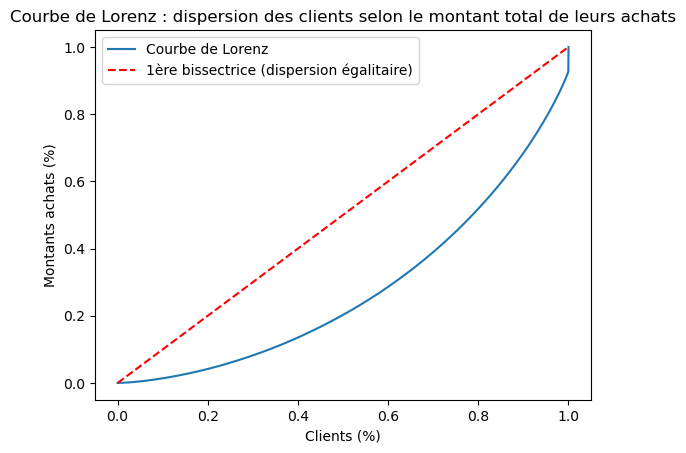

Indice de Gini : 0.44


In [58]:
# Courbe de Lorenz : dispersion des clients selon montant total des achats

lorenz_clients_CA = panier_clients.loc[:, ["client_id", "panier_total"]]                                    # récupère les colonnes nécessaires à cette analyse dans un nouveau dataframe
lorenz_clients_CA = lorenz_clients_CA.groupby("client_id").sum().round(2).reset_index()                     # agrégation des données pour obtenir la montant total des achats pour chaque client
lorenz_clients_CA = lorenz_clients_CA.sort_values(by = "panier_total", ascending = True)                    # trie les données pour afficher les montants total des achats dans l'ordre croissant (du plus petit au plus grand)
lorenz_clients_CA["panier_cum"] = lorenz_clients_CA["panier_total"].cumsum()                                # calcule la somme cumulée des montants total d'achat des clients
total_CA_clients = lorenz_clients_CA["panier_total"].sum()                                                  # calcule le chiffre d'affaires total effectué par le site de vente en ligne de la librairie sur les 2 années écoulées
lorenz_clients_CA["lorenz"] = lorenz_clients_CA["panier_cum"] / total_CA_clients                            # normalisation de la valeur de la somme cumulée (cumsum) par le chiffre d'affaire total pour que le haut de la courbe soit à 1 

n_CA = len(lorenz_clients_CA["panier_total"])                                                               # récupère le nombre de valeurs des montants totaux d'achat des clients
xaxis = np.linspace(0-1/n_CA, 1+1/n_CA, n_CA+1)                                                             # calcule les valeurs d'abscisses pour tous les clients (de 0 à 1 à intervalles réguliers (nombre de montants totaux))
yaxis = np.append([0], lorenz_clients_CA["lorenz"])                                                         # récupère les valeurs des ordonnées et ajoute le 0 de départ
plt.plot(xaxis, yaxis, label = "Courbe de Lorenz")                                                          # dessine la courbe de Lorenz pour la dispersion des clients en fonction des montants totaux de leurs achats
plt.plot([0,1], [0,1], color = "red", linestyle = "--", label = "1ère bissectrice (dispersion égalitaire)") # ajoute la 1ère bissectrice (dispersion égalitaire parfaite)
plt.title("Courbe de Lorenz : dispersion des clients selon le montant total de leurs achats")               # ajoute un titre au graphique
plt.xlabel("Clients (%)")                                                                                   # ajoute un titre à l'axe des abscisses (horizontal)
plt.ylabel("Montants achats (%)")                                                                           # ajoute un titre à l'axe des ordonnées (vertical)
plt.legend()                                                                                                # affiche la légende du graphique
plt.show()                                                                                                  # affiche le graphique créé

AUC_lorenz_clients_CA = (lorenz_clients_CA["lorenz"].sum() - yaxis[-1]/2 - yaxis[0]/2) / n_CA               # calcule la surface sous la courbe de lorenz (AUC)
s_lorenz_clients_CA = 0.5 - AUC_lorenz_clients_CA                                                           # calcule la surface entre la 1ère bissectrice (dispersion égalitaire parfaite) et la courbe de lorenz (s)
gini_lorenz_clients_CA = round(s_lorenz_clients_CA * 2, 2)                                                  # calcule l'indice de Gini pour la dispersion des clients en fonction des montants totaux de leurs achats
print(f"Indice de Gini : {gini_lorenz_clients_CA}")


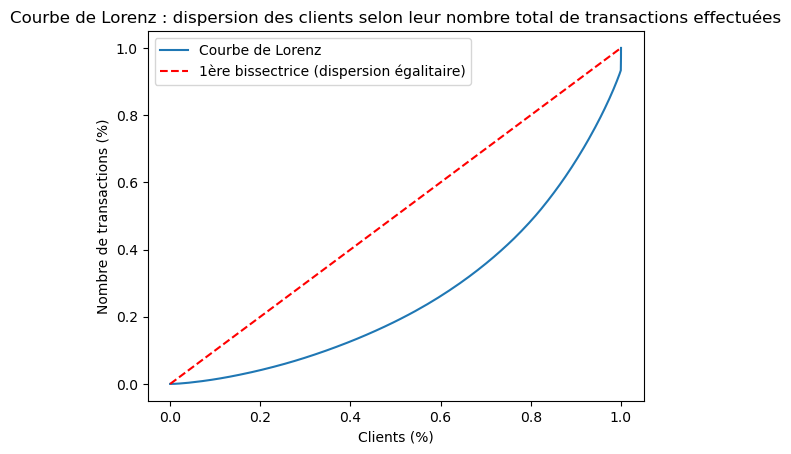

Indice de Gini : 0.47


In [59]:
# Courbe de Lorenz : dispersion des clients selon nombre total de transactions

lorenz_trans_clients = trans_clients.sort_values(by = "nb_transactions", ascending = True)                    # trie les données pour afficher le nombre total de transactions dans l'ordre croissant (du plus petit au plus grand)
lorenz_trans_clients["trans_cum"] = lorenz_trans_clients["nb_transactions"].cumsum()                          # calcule la somme cumulée du nombre total de transactions des clients
total_trans_clients = lorenz_trans_clients["nb_transactions"].sum()                                           # calcule le nombre de transactions total effectuées sur le site de vente en ligne de la librairie sur les 2 années écoulées
lorenz_trans_clients["lorenz"] = lorenz_trans_clients["trans_cum"] / total_trans_clients                      # normalisation de la valeur de la somme cumulée (cumsum) par le nombre de transactions total pour que le haut de la courbe soit à 1 

n_trans = len(lorenz_trans_clients["nb_transactions"])                                                        # récupère le nombre de valeurs des transactions des clients
xaxis = np.linspace(0-1/n_trans, 1+1/n_trans, n_trans+1)                                                      # calcule les valeurs d'abscisses pour tous les clients (de 0 à 1 à intervalles réguliers (nombre de transactions))
yaxis = np.append([0], lorenz_trans_clients["lorenz"])                                                        # récupère les valeurs des ordonnées et ajoute le 0 de départ
plt.plot(xaxis, yaxis, label = "Courbe de Lorenz")                                                            # dessine la courbe de Lorenz pour la dispersion des clients en fonction de leur nombre total de transactions effectuées
plt.plot([0,1], [0,1], color = "red", linestyle = "--", label = "1ère bissectrice (dispersion égalitaire)")   # ajoute la 1ère bissectrice (dispersion égalitaire parfaite)
plt.title("Courbe de Lorenz : dispersion des clients selon leur nombre total de transactions effectuées")     # ajoute un titre au graphique
plt.xlabel("Clients (%)")                                                                                     # ajoute un titre à l'axe des abscisses (horizontal)
plt.ylabel("Nombre de transactions (%)")                                                                      # ajoute un titre à l'axe des ordonnées (vertical)
plt.legend()                                                                                                  # affiche la légende du graphique
plt.show()                                                                                                    # affiche le graphique créé

AUC_lorenz_trans_clients = (lorenz_trans_clients["lorenz"].sum() - yaxis[-1]/2 - yaxis[0]/2) / n_trans        # calcule la surface sous la courbe de lorenz (AUC)
s_lorenz_trans_clients = 0.5 - AUC_lorenz_trans_clients                                                       # calcule la surface entre la 1ère bissectrice (dispersion égalitaire parfaite) et la courbe de lorenz (s)
gini_lorenz_trans_clients = round(s_lorenz_trans_clients * 2, 2)                                              # calcule l'indice de Gini pour la dispersion des clients en fonction de leur nombre total de transactions effectuées
print(f"Indice de Gini : {gini_lorenz_trans_clients}")


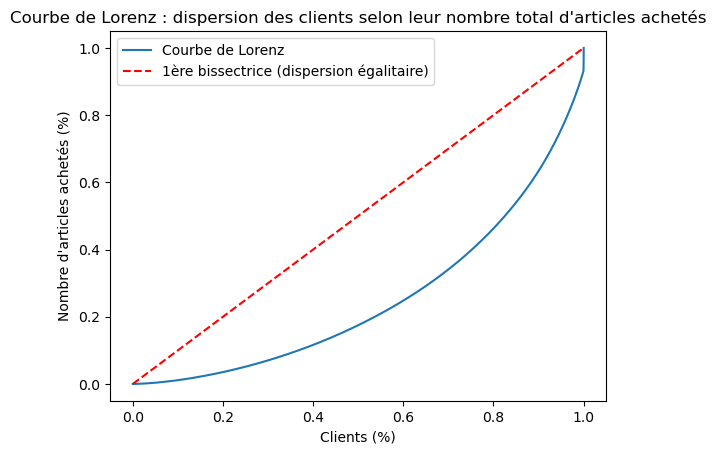

Indice de Gini : 0.5


In [60]:
# Courbe de Lorenz : dispersion des clients selon nombre total d'articles achetés

lorenz_prod_clients = prod_clients.sort_values(by = "nb_articles", ascending = True)                          # trie les données pour afficher le nombre total d'articles achetés dans l'ordre croissant (du plus petit au plus grand)
lorenz_prod_clients["prod_cum"] = lorenz_prod_clients["nb_articles"].cumsum()                                 # calcule la somme cumulée du nombre total d'articles achetés par les clients
total_prod_clients = lorenz_prod_clients["nb_articles"].sum()                                                 # calcule le  nombre total d'articles achetés sur le site de vente en ligne de la librairie sur les 2 années écoulées
lorenz_prod_clients["lorenz"] = lorenz_prod_clients["prod_cum"] / total_prod_clients                          # normalisation de la valeur de la somme cumulée (cumsum) par le nombre total d'articles achetés pour que le haut de la courbe soit à 1 
   
n_prod = len(lorenz_prod_clients["nb_articles"])                                                              # récupère le nombre de valeurs d'articles achetés par les clients
xaxis = np.linspace(0-1/n_prod, 1+1/n_prod, n_prod+1)                                                         # calcule les valeurs d'abscisses pour tous les clients (de 0 à 1 à intervalles réguliers (nombre d'articles achetés))
yaxis = np.append([0], lorenz_prod_clients["lorenz"])                                                         # récupère les valeurs des ordonnées et ajoute le 0 de départ
plt.plot(xaxis, yaxis, label = "Courbe de Lorenz")                                                            # dessine la courbe de Lorenz pour la dispersion des clients en fonction de leur nombre total d'articles achetés
plt.plot([0,1], [0,1], color = "red", linestyle = "--", label = "1ère bissectrice (dispersion égalitaire)")   # ajoute la 1ère bissectrice (dispersion égalitaire parfaite)
plt.title("Courbe de Lorenz : dispersion des clients selon leur nombre total d'articles achetés")             # ajoute un titre au graphique
plt.xlabel("Clients (%)")                                                                                     # ajoute un titre à l'axe des abscisses (horizontal)
plt.ylabel("Nombre d'articles achetés (%)")                                                                   # ajoute un titre à l'axe des ordonnées (vertical)
plt.legend()                                                                                                  # affiche la légende du graphique
plt.show()                                                                                                    # affiche le graphique créé

AUC_lorenz_prod_clients = (lorenz_prod_clients["lorenz"].sum() - yaxis[-1]/2 - yaxis[0]/2) / n_prod           # calcule la surface sous la courbe de lorenz (AUC)
s_lorenz_prod_clients = 0.5 - AUC_lorenz_prod_clients                                                         # calcule la surface entre la 1ère bissectrice (dispersion égalitaire parfaite) et la courbe de lorenz (s)
gini_lorenz_prod_clients = round(s_lorenz_prod_clients * 2, 2)                                                # calcule l'indice de Gini pour la dispersion des clients en fonction de leur nombre total d'articles achetés
print(f"Indice de Gini : {gini_lorenz_prod_clients}")


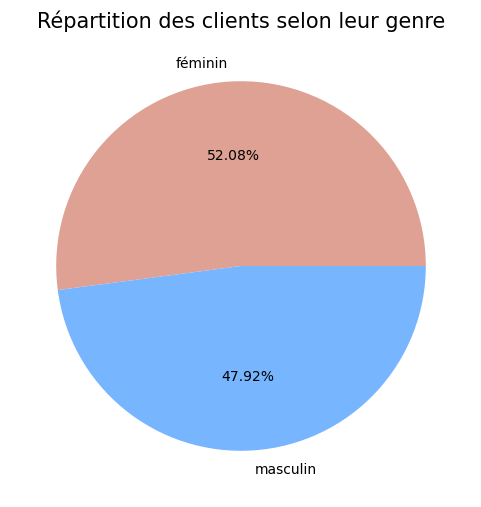

In [61]:
# Répartition des clients selon le Genre

df_genre = copy.deepcopy(df_merge.loc[:, ["client_id", "sex"]]).drop_duplicates().dropna()       # crée un nouveau dataframe contenant une copie des données de df_merge pour effectuer l'analyse sans compromettre les données initiales
nb_total_clients = df_genre["client_id"].count()                                                 # compte le nombre total de clients du site de vente en ligne de la librairie
df_genre = df_genre.groupby("sex").count().reset_index()                                         # agrégation des données pour obtenir le nombre de clients en fonction du genre
df_genre.rename(columns = {"client_id" : "nb_clients"}, inplace = True)                          # renomme la colonne "client_id" en nombre de clients pour plus de clarté de l'information observée
df_genre["%_clients"] = round(df_genre["nb_clients"] * 100 / nb_total_clients, 2)                # calcule le pourcentage que représente chaque genre parmi la totalité des clients de la librairie
df_genre["sex"] = df_genre["sex"].apply(lambda x : "féminin" if x == "f" else "masculin")        # modifie la valeur de la colonne "sex" pour plus de clarté de l'information observée 

plt.figure(figsize = (6, 6))                                                                     # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
couleurs = {"masculin": "#77B5FE", "féminin": "#DEA193"}                                         # applique des couleurs à chaque genre pour un graphique plus clair
list_col = [couleurs[genre] for genre in df_genre["sex"]]
plt.pie(df_genre["%_clients"], labels = df_genre["sex"], autopct = "%1.2f%%", colors = list_col) # crée un diagramme circulaire montrant la répartition des clients selon leur genre (autocpct : permet d'afficher la valeur des parts pour plus de clarté)
plt.title("Répartition des clients selon leur genre", fontsize = 15)                             # ajoute un titre au graphique
plt.show()                                                                                       # affiche le graphique créé


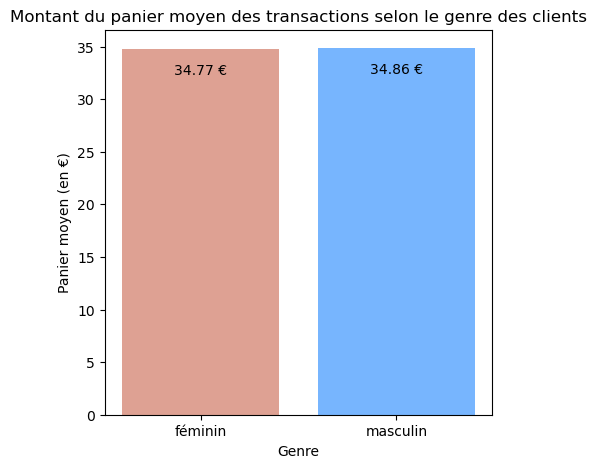

In [62]:
# Panier moyen par genre

panier_genre = copy.deepcopy(df_merge.loc[:, ["sex", "session_id", "price"]])                        # crée un nouveau dataframe contenant une copie des données de df_merge pour effectuer l'analyse sans compromettre les données initiales
panier_genre = panier_genre.groupby(["sex", "session_id"]).sum().reset_index()                       # agrégation des données pour obtenir le montant total de chaque transaction
panier_genre.drop(columns = "session_id", inplace = True)                                            # suppression de la colonne "session_id" car nous n'en aurons plus besoin pour cette analyse
panier_genre = panier_genre.groupby("sex").mean().round(2).reset_index()                             # agrégation des données pour obtenir le montant moyen des transactions pour chaque genre
panier_genre.rename(columns = {"price" : "panier_moyen"}, inplace = True)                            # renomme la colonne "price" en panier moyen pour plus de clarté de l'information observée
panier_genre["sex"] = panier_genre["sex"].apply(lambda x : "féminin" if x == "f" else "masculin")    # modifie la valeur de la colonne "sex" pour plus de clarté de l'information observée 

plt.figure(figsize = (5, 5))                                                                         # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
couleurs = {"masculin": "#77B5FE", "féminin": "#DEA193"}                                             # applique des couleurs à chaque genre pour un graphique plus clair
list_col = [couleurs[genre] for genre in panier_genre["sex"]]
bars = plt.bar(panier_genre["sex"], panier_genre["panier_moyen"], color = list_col)                   # crée un histogramme montrant le montant moyen des transactions en fonction du genre des clients
for bar in bars :
        height = bar.get_height()                                                                    # Mesure la taille de la barre  
        x_pos = bar.get_x() + bar.get_width() / 2                                                    # récupère la position horizontale (centre de la barre)
        y_pos = height - 2                                                                           # récupère la position verticale (sommet de la barre + décalage vers le bas)
        plt.text(x_pos, y_pos, f"{height} €", ha = "center", va = "center")                          # ajuste les positions horizontale et verticale, et indique le format du texte à afficher (valeur avec 2 décimales)
plt.title("Montant du panier moyen des transactions selon le genre des clients", fontsize = 12)      # ajoute un titre au graphique
plt.xlabel("Genre")                                                                                  # ajoute un titre à l'axe des abscisses (horizontal)
plt.ylabel("Panier moyen (en €)")                                                                    # ajoute un titre à l'axe des ordonnées (vertical)
plt.show()                                                                                           # affiche le graphique créé


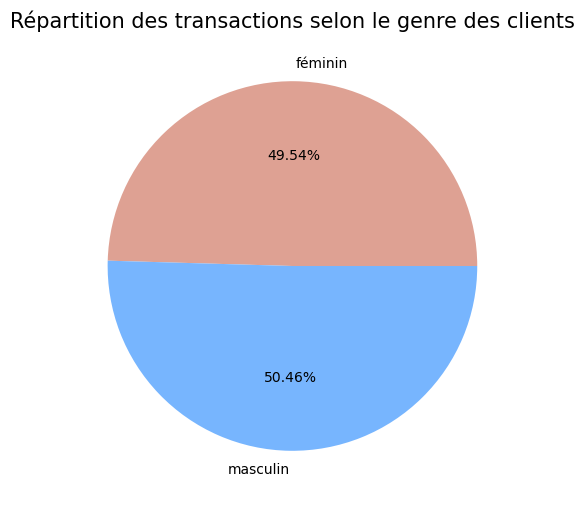

In [63]:
# Genre qui achète le plus : nombre de transactions

genre_trans = copy.deepcopy(df_merge.loc[:, ["sex", "session_id"]]).drop_duplicates()              # crée un nouveau dataframe contenant une copie des données de df_merge pour effectuer l'analyse sans compromettre les données initiales (+ supprime les doublons)
genre_trans = genre_trans.groupby(["sex"]).count().reset_index()                                   # agrégation des données pour obtenir le nombre de transactions par genre
genre_trans.rename(columns = {"session_id" : "nb_trans"}, inplace = True)                          # renomme la colonne "session_id" en nombre de transactions pour plus de clarté de l'information observée
nb_total_trans = genre_trans["nb_trans"].sum()                                                     # calcule le nombre total de transactions effectuées sur le site de vente en ligne de la librairie
genre_trans["%_trans"] = round(genre_trans["nb_trans"] * 100 / nb_total_trans, 2)                  # calcule le pourcentage que représente chaque genre parmi le nombre total de transactions effectuées sur le site de vente en ligne de la librairie
genre_trans["sex"] = genre_trans["sex"].apply(lambda x : "féminin" if x == "f" else "masculin")    # modifie la valeur de la colonne "sex" pour plus de clarté de l'information observée 

plt.figure(figsize = (6, 6))                                                                       # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
couleurs = {"masculin": "#77B5FE", "féminin": "#DEA193"}                                           # applique des couleurs à chaque genre pour un graphique plus clair
list_col = [couleurs[genre] for genre in df_genre["sex"]]
plt.pie(genre_trans["%_trans"], labels = df_genre["sex"], autopct = "%1.2f%%", colors = list_col)  # crée un diagramme circulaire montrant la répartition des transactions selon le genre des clients (autocpct : permet d'afficher la valeur des parts pour plus de clarté)
plt.title("Répartition des transactions selon le genre des clients", fontsize = 15)                # ajoute un titre au graphique
plt.show()                                                                                         # affiche le graphique créé


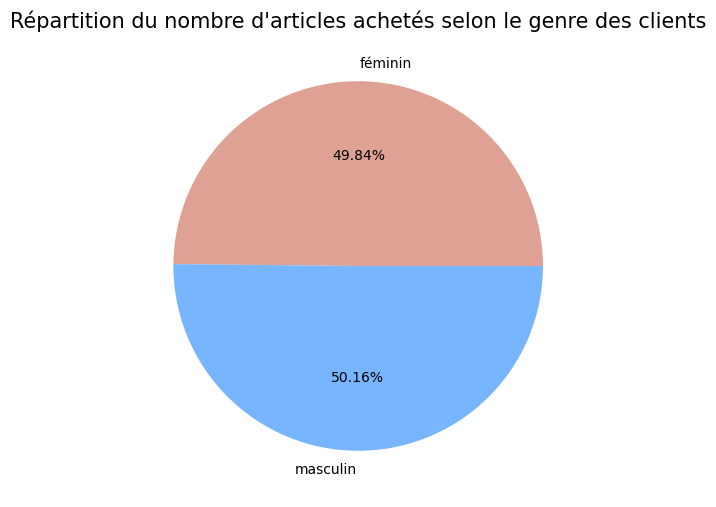

In [64]:
# Genre qui achète le plus : nombre d'articles achetés

genre_prod = copy.deepcopy(df_merge.loc[:, ["sex", "id_prod"]])                                    # crée un nouveau dataframe contenant une copie des données de df_merge pour effectuer l'analyse sans compromettre les données initiales
genre_prod = genre_prod.groupby(["sex"]).count().reset_index()                                     # agrégation des données pour obtenir le nombre d'articles achetés par genre
genre_prod.rename(columns = {"id_prod" : "nb_prod"}, inplace = True)                               # renomme la colonne "id_prod" en nombre d'articles achetés pour plus de clarté de l'information observée
nb_total_prod = genre_prod["nb_prod"].sum()                                                        # calcule le nombre total d'articles achetés sur le site de vente en ligne de la librairie
genre_prod["%_prod"] = round(genre_prod["nb_prod"] * 100 / nb_total_prod, 2)                       # calcule le pourcentage que représente chaque genre parmi le nombre total d'articles achetés sur le site de vente en ligne de la librairie
genre_prod["sex"] = genre_prod["sex"].apply(lambda x : "féminin" if x == "f" else "masculin")      # modifie la valeur de la colonne "sex" pour plus de clarté de l'information observée 

plt.figure(figsize = (6, 6))                                                                      # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
couleurs = {"masculin": "#77B5FE", "féminin": "#DEA193"}                                           # applique des couleurs à chaque genre pour un graphique plus clair
list_col = [couleurs[genre] for genre in df_genre["sex"]]
plt.pie(genre_prod["%_prod"], labels = genre_prod["sex"], autopct = "%1.2f%%", colors = list_col)  # crée un diagramme circulaire montrant la répartition du nombre d'articles achetés selon le genre des clients (autocpct : permet d'afficher valeur des parts)
plt.title("Répartition du nombre d'articles achetés selon le genre des clients", fontsize = 15)    # ajoute un titre au graphique
plt.show()                                                                                         # affiche le graphique créé


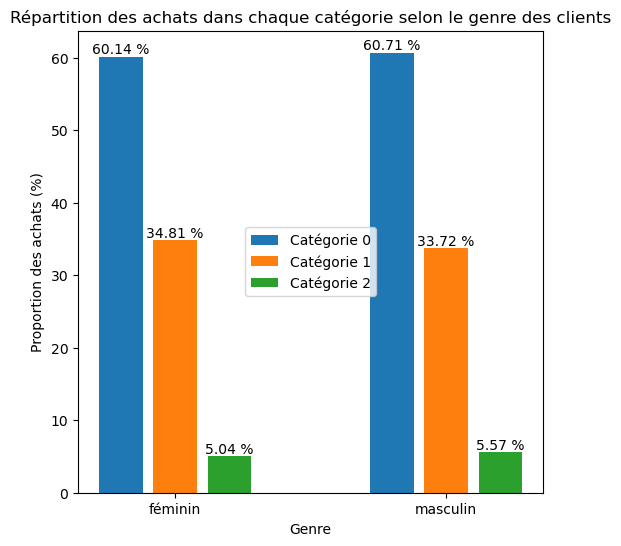

In [65]:
# Catégorie privilégiée selon le Genre 

genre_cat = copy.deepcopy(df_merge.loc[:, ["sex", "categ", "id_prod"]]).dropna()                                     # crée un nouveau dataframe contenant une copie des données de df_merge pour effectuer l'analyse sans compromettre les données initiales
genre_cat = genre_cat.groupby(["sex", "categ"]).count().reset_index()                                                # agrégation des données pour obtenir le nombre d'articles achetés par catégorie et par genre
genre_cat.rename(columns = {"id_prod" : "nb_articles"}, inplace = True)                                              # renome la colonne "id_prod" en nombre d'articles achetés pour plus de clarté de l'information observée  
nb_total_art_f = genre_cat["nb_articles"][genre_cat["sex"] == "f"].sum()                                             # compte le nombre total d'articles acheté par les femmes
nb_total_art_m = genre_cat["nb_articles"][genre_cat["sex"] == "m"].sum()                                             # compte le nombre total d'articles achetés par les hommes
genre_cat.loc[genre_cat["sex"] == "f", "%_articles"] = round(genre_cat["nb_articles"] * 100 / nb_total_art_f, 2)     # calcule le pourcentage que représente le nombre d'articles achetés pour chaque catégorie parmi le nombre total d'articles achetés par les femmes
genre_cat.loc[genre_cat["sex"] == "m", "%_articles"] = round(genre_cat["nb_articles"] * 100 / nb_total_art_m, 2)     # calcule le pourcentage que représente le nombre d'articles achetés pour chaque catégorie parmi le nombre total d'articles achetés par les hommes
genre_cat["sex"] = genre_cat["sex"].apply(lambda x : "féminin" if x == "f" else "masculin")                          # modifie la valeur de la colonne "sex" pour plus de clarté de l'information observée 

genre_cat_0 = genre_cat.loc[genre_cat["categ"] == 0, ["sex", "%_articles"]]                                          # récupère les valeurs du %_articles vendus par chaque genre pour chaque catégorie
genre_cat_1 = genre_cat.loc[genre_cat["categ"] == 1, ["sex", "%_articles"]]     
genre_cat_2 = genre_cat.loc[genre_cat["categ"] == 2, ["sex", "%_articles"]]  

nb_genres = len(genre_cat_0["sex"])                                                                                  # récupère le nombre de genres à afficher pour ajuster l'espacement entre les barres
pos_x = np.arange(0, nb_genres * 5, 5)                                                                               # génère la liste des positions des groupes de barres sur l'axe des abscisses (horizontal)

plt.figure(figsize = (6, 6))                                                                                         # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars1 = plt.bar([p - 1 for p in pos_x], genre_cat_0["%_articles"], label = "Catégorie 0")                            # crée les histogrammes représentant la répartition des achats par catégorie selon le genre des clients
bars2 = plt.bar([p for p in pos_x], genre_cat_1["%_articles"], label = "Catégorie 1")
bars3 = plt.bar([p + 1 for p in pos_x], genre_cat_2["%_articles"], label = "Catégorie 2")

bars_series = [bars1, bars2, bars3]
for bars in bars_series :
    for bar in bars : 
        height = bar.get_height()                                                                                    # Mesure la taille de la barre  
        x_pos = bar.get_x() + bar.get_width() / 2                                                                    # récupère la position horizontale (centre de la barre)
        y_pos = height + 1                                                                                           # récupère la position verticale (sommet de la barre + décalage vers le haut)
        plt.text(x_pos, y_pos, f"{height:.2f} %", ha = "center", va = "center")                                      # ajuste les positions horizontale et verticale, et indique le format du texte à afficher (valeur avec 2 décimales)

plt.title("Répartition des achats dans chaque catégorie selon le genre des clients", fontsize = 12)                  # ajoute un titre au graphique
plt.xticks([i for i in pos_x], genre_cat_0["sex"])                                                                   # ajoute les genres à l'axe des abscisses (horizontal) et ajuste l'écartement entre les groupes de barres
plt.xlabel("Genre")                                                                                                  # ajoute un titre à l'axe des abscisses (horizontal)
plt.ylabel("Proportion des achats (%)")                                                                              # ajoute un titre à l'axe des ordonnées (vertical)
plt.legend()                                                                                                         # affiche la légende du graphique
plt.show()                                                                                                           # affiche le graphique créé


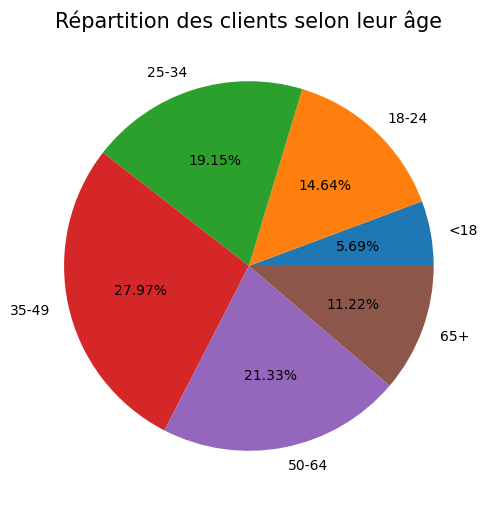

In [66]:
# Répartition selon Age

df_age = copy.deepcopy(df_merge.loc[:, ["client_id", "tranche_age"]]).drop_duplicates()       # crée un nouveau dataframe contenant une copie des données de df_merge pour effectuer l'analyse sans compromettre les données initiales (+ supprime doublons)
nb_total_clients = df_age["client_id"].count()                                                # compte le nombre total de clients du site de vente en ligne de la librairie
df_age = df_age.groupby("tranche_age", observed = True).count().reset_index()                 # agrégation des données pour obtenir le nombre de clients en fonction de l'âge
                                                                                              # (observed = True prend en compte tous les binomes catégorie/age, même ceux qui n'apparaissent pas dans les valeurs)
df_age.rename(columns = {"client_id" : "nb_clients"}, inplace = True)                         # renomme la colonne "client_id" en nombre de clients pour plus de clarté de l'information observée
df_age["%_clients"] = round(df_age["nb_clients"] * 100 / nb_total_clients, 2)                 # calcule le pourcentage que représente chaque tranche d'âge parmi la totalité des clients de la librairie

plt.figure(figsize = (6, 6))                                                                  # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
plt.pie(df_age["%_clients"], labels = df_age["tranche_age"], autopct = "%1.2f%%")             # crée un diagramme circulaire montrant la répartition des clients selon leur âge (autocpct : permet d'afficher la valeur des parts pour plus de clarté)
plt.title("Répartition des clients selon leur âge", fontsize = 15)                            # ajoute un titre au graphique
plt.show()                                                                                    # affiche le graphique créé


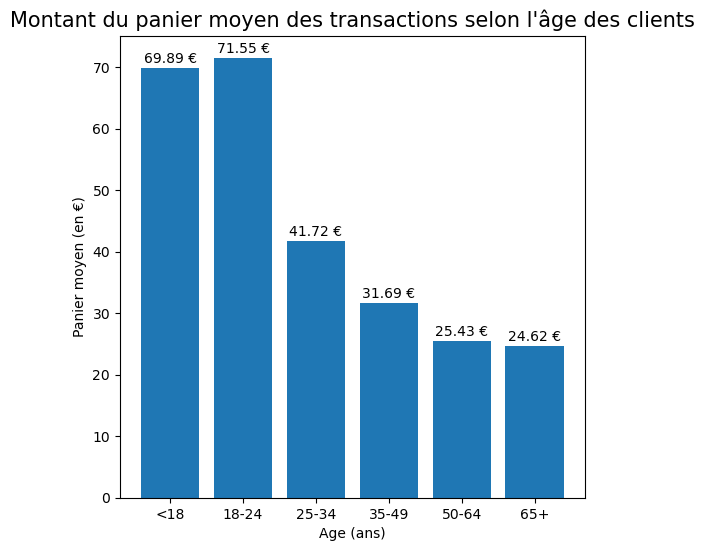

In [67]:
# Panier moyen par âge

panier_age = copy.deepcopy(df_merge.loc[:, ["tranche_age", "session_id", "price"]])                          # crée un nouveau dataframe contenant une copie des données de df_merge pour effectuer l'analyse sans compromettre les données initiales
panier_age = panier_age.groupby(["tranche_age", "session_id"], observed = True).sum().reset_index()          # agrégation des données pour obtenir le montant total de chaque transaction
                                                                                                             # (observed = True prend en compte tous les binomes catégorie/age, même ceux qui n'apparaissent pas dans les valeurs)
panier_age.drop(columns = "session_id", inplace = True)                                                      # suppression de la colonne "session_id" car nous n'en aurons plus besoin pour cette analyse
panier_age = panier_age.groupby("tranche_age", observed = True).mean().round(2).reset_index()                # agrégation des données pour obtenir le montant moyen des transactions pour chaque tranche d'âge
panier_age.rename(columns = {"price" : "panier_moyen"}, inplace = True)                                      # renomme la colonne "price" en panier moyen pour plus de clarté de l'information observée

plt.figure(figsize = (6, 6))                                                                                 # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars = plt.bar(panier_age["tranche_age"], panier_age["panier_moyen"])                                        # crée un histogramme montrant le montant moyen des transactions en fonction de l'âge des clients
for bar in bars :
        height = bar.get_height()                                                                            # Mesure la taille de la barre  
        x_pos = bar.get_x() + bar.get_width() / 2                                                            # récupère la position horizontale (centre de la barre)
        y_pos = height + 1.5                                                                                 # récupère la position verticale (sommet de la barre + décalage vers le bas)
        plt.text(x_pos, y_pos, f"{height} €", ha = "center", va = "center")                                  # ajuste les positions horizontale et verticale, et indique le format du texte à afficher
plt.title("Montant du panier moyen des transactions selon l'âge des clients", fontsize = 15)                 # ajoute un titre au graphique
plt.xlabel("Age (ans)")                                                                                      # ajoute un titre à l'axe des abscisses (horizontal)
plt.ylabel("Panier moyen (en €)")                                                                            # ajoute un titre à l'axe des ordonnées (vertical)
plt.show()                                                                                                   # affiche le graphique créé


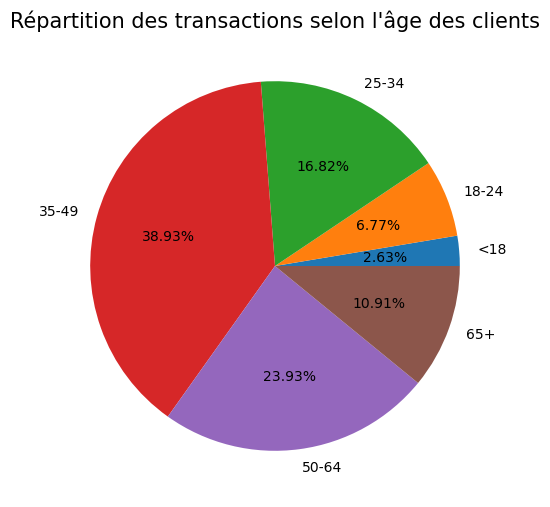

In [68]:
# Tranche d'âge qui achète le plus : nombre de transactions

age_trans = copy.deepcopy(df_merge.loc[:, ["tranche_age", "session_id"]]).drop_duplicates()        # crée un nouveau dataframe contenant une copie des données de df_merge pour effectuer l'analyse sans compromettre les données initiales (+ supprime les doublons)
age_trans = age_trans.groupby(["tranche_age"], observed = True).count().reset_index()              # agrégation des données pour obtenir le nombre de transactions par âge
                                                                                                   # (observed = True prend en compte tous les binomes catégorie/age, même ceux qui n'apparaissent pas dans les valeurs)
age_trans.rename(columns = {"session_id" : "nb_trans"}, inplace = True)                            # renomme la colonne "session_id" en nombre de transactions pour plus de clarté de l'information observée
nb_total_trans = age_trans["nb_trans"].sum()                                                       # calcule le nombre total de transactions effectuées sur le site de vente en ligne de la librairie
age_trans["%_trans"] = round(age_trans["nb_trans"] * 100 / nb_total_trans, 2)                      # calcule le pourcentage que représente chaque tranche d'âge parmi le nombre total de transactions effectuées sur le site de vente en ligne de la librairie

plt.figure(figsize = (6, 6))                                                                       # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
plt.pie(age_trans["%_trans"], labels = age_trans["tranche_age"], autopct = "%1.2f%%")              # crée un diagramme circulaire montrant la répartition des transactions selon l'âge des clients (autocpct : permet d'afficher la valeur des parts pour plus de clarté)
plt.title("Répartition des transactions selon l'âge des clients", fontsize = 15)                   # ajoute un titre au graphique
plt.show()                                                                                         # affiche le graphique créé


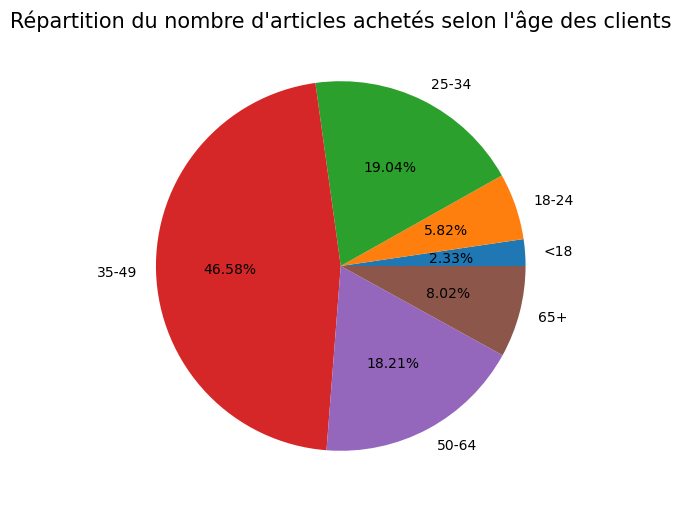

In [69]:
# Tranche d'âge qui achète le plus : nombre d'articles achetés

age_prod = copy.deepcopy(df_merge.loc[:, ["tranche_age", "id_prod"]])                            # crée un nouveau dataframe contenant une copie des données de df_merge pour effectuer l'analyse sans compromettre les données initiales
age_prod = age_prod.groupby(["tranche_age"], observed = True).count().reset_index()              # agrégation des données pour obtenir le nombre d'articles achetés par tranche d'âge
                                                                                                 # (observed = True prend en compte tous les binomes catégorie/age, même ceux qui n'apparaissent pas dans les valeurs)
age_prod.rename(columns = {"id_prod" : "nb_prod"}, inplace = True)                               # renomme la colonne "id_prod" en nombre d'articles achetés pour plus de clarté de l'information observée
nb_total_prod = age_prod["nb_prod"].sum()                                                        # calcule le nombre total d'articles achetés sur le site de vente en ligne de la librairie
age_prod["%_prod"] = round(age_prod["nb_prod"] * 100 / nb_total_prod, 2)                         # calcule le pourcentage que représente chaque tranche d'âge parmi le nombre total d'articles achetés sur le site de vente en ligne de la librairie

plt.figure(figsize = (6, 6))                                                                     # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
plt.pie(age_prod["%_prod"], labels = age_prod["tranche_age"], autopct = "%1.2f%%")               # crée un diagramme circulaire montrant la répartition du nombre d'articles achetés selon l'âge des clients (autocpct : permet d'afficher la valeur des parts)
plt.title("Répartition du nombre d'articles achetés selon l'âge des clients", fontsize = 15)     # ajoute un titre au graphique
plt.show()                                                                                       # affiche le graphique créé


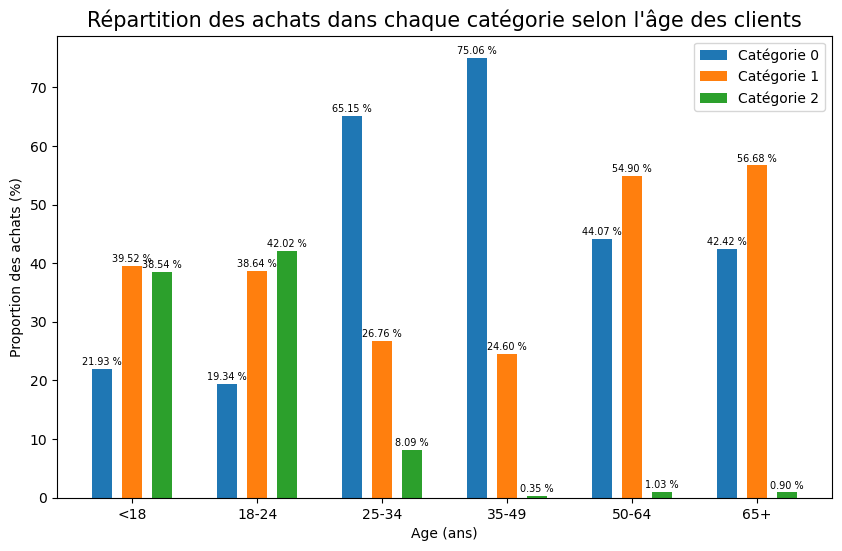

In [70]:
# Catégorie privilégiée selon Age

age_cat = copy.deepcopy(df_merge.loc[:, ["tranche_age", "categ", "id_prod"]]).dropna()                                # crée un nouveau dataframe contenant une copie des données de df_merge pour effectuer l'analyse sans compromettre les données initiales
age_cat = age_cat.groupby(["tranche_age", "categ"], observed = True).count().reset_index()                            # agrégation des données pour obtenir le nombre d'articles achetés par catégorie et par tranche d'âge 
                                                                                                                      # (observed = True prend en compte tous les binomes catégorie/age, même ceux qui n'apparaissent pas dans les valeurs)
age_cat.rename(columns = {"id_prod" : "nb_articles"}, inplace = True)                                                 # renome la colonne "id_prod" en nombre d'articles achetés pour plus de clarté de l'information observée  

ages = age_cat["tranche_age"].unique().tolist()
for age in ages :
    nb_total_art = age_cat["nb_articles"][age_cat["tranche_age"] == age].sum()                                        # compte le nombre total d'articles acheté dans chaque catégorie pour chaque tranche d'âge
    age_cat.loc[age_cat["tranche_age"] == age, "%_articles"] = round(age_cat["nb_articles"] * 100 / nb_total_art, 2)  # calcule le pourcentage que représente le nombre d'articles achetés pour chaque catégorie parmi le nombre total d'articles achetés par chaque tranche


age_cat_0 = age_cat.loc[age_cat["categ"] == 0, ["tranche_age", "%_articles"]]                                         # récupère les valeurs du %_articles vendus par tranche d'âge pour chaque catégorie
age_cat_1 = age_cat.loc[age_cat["categ"] == 1, ["tranche_age", "%_articles"]]     
age_cat_2 = age_cat.loc[age_cat["categ"] == 2, ["tranche_age", "%_articles"]]  

nb_ages = len(age_cat_0["tranche_age"])                                                                               # récupère le nombre d'âges à afficher pour ajuster l'espacement entre les barres
pos_x = np.arange(0, nb_ages * 5, 5)                                                                                  # génère la liste des positions des groupes de barres sur l'axe des abscisses (horizontal)

plt.figure(figsize = (10, 6))                                                                                         # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars1 = plt.bar([p - 1.2 for p in pos_x], age_cat_0["%_articles"], label = "Catégorie 0")                             # crée les histogrammes représentant la répartition des achats par catégorie selon l'âge des clients
bars2 = plt.bar([p for p in pos_x], age_cat_1["%_articles"], label = "Catégorie 1")
bars3 = plt.bar([p + 1.2 for p in pos_x], age_cat_2["%_articles"], label = "Catégorie 2")

bars_series = [bars1, bars2, bars3]
for bars in bars_series :
    for bar in bars : 
        height = bar.get_height()                                                                                      # Mesure la taille de la barre  
        x_pos = bar.get_x() + bar.get_width() / 2                                                                      # récupère la position horizontale (centre de la barre)
        y_pos = height + 1.2                                                                                           # récupère la position verticale (sommet de la barre + décalage vers le haut)
        plt.text(x_pos, y_pos, f"{height:.2f} %", ha = "center", va = "center", fontsize = 7)                          # ajuste les positions horizontale et verticale, et indique le format du texte à afficher (valeur avec 2 décimales)

plt.title("Répartition des achats dans chaque catégorie selon l'âge des clients", fontsize = 15)                       # ajoute un titre au graphique
plt.xticks([i for i in pos_x], age_cat_0["tranche_age"])                                                               # ajoute les tranches d'âge à l'axe des abscisses (horizontal) et ajuste l'écartement entre les groupes de barres
plt.xlabel("Age (ans)")                                                                                                # ajoute un titre à l'axe des abscisses (horizontal)
plt.ylabel("Proportion des achats (%)")                                                                                # ajoute un titre à l'axe des ordonnées (vertical)
plt.legend()                                                                                                           # affiche la légende du graphique
plt.show()                                                                                                             # affiche le graphique créé


<div style="border: 1px solid RGB(198,131,70);" >
<h4 style="margin: auto; padding: 20px; color: RGB(214,181,136); ">5.2.3 - Clients BtoB</h4>
</div>

In [71]:
# récupération des identifiants des clients BtoB :

clients_BtoB = panier_clients_moy["client_id"].head(4).sort_values().tolist()              # récupère les identifiants des clients BtoB à partir du Top clients ayant le panier moyen le plus élevé (4 premiers clients)
verif_trans = trans_clients["client_id"].head(4).sort_values().tolist()                    # récupère les identifiants des clients BtoB à partir du Top clients ayant le nombre de transactions le plus élevé (4 premiers clients)
verif_prod = prod_clients["client_id"].head(4).sort_values().tolist()                      # récupère les identifiants des clients BtoB à partir du Top clients ayant le nombre d'articles achetés le plus élevé (4 premiers clients)
print(f"Les clients BtoB sont les clients suivants : {clients_BtoB}")
print(f"\nVérification des identifiants dans les autres indicateurs : \n     Nombre de transactions {verif_trans}, \n     Nombre d'articles achetés {verif_prod}")

## ces 4 clients ont pu être identifiés car ils ont un chiffre d'affaires total, un panier moyen, un nombre de transactions et d'articles achetés largement plus élevé que les autres clients (dits "particuliers" : BtoC).


Les clients BtoB sont les clients suivants : ['c_1609', 'c_3454', 'c_4958', 'c_6714']

Vérification des identifiants dans les autres indicateurs : 
     Nombre de transactions ['c_1609', 'c_3454', 'c_4958', 'c_6714'], 
     Nombre d'articles achetés ['c_1609', 'c_3454', 'c_4958', 'c_6714']


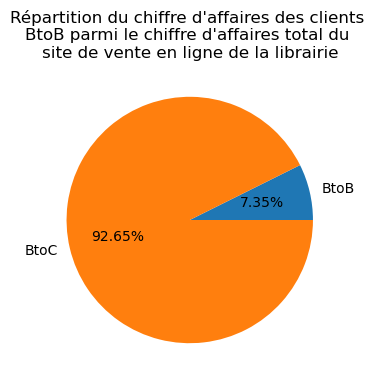

In [72]:
# Répartition du CA pour les clients BtoB (BtoB vs autres clients)

CA_clients = panier_clients.loc[:, ["client_id", "panier_total"]]                                        # récupère les données du montant total de chaque transaction et pour tous les clients du site de vente en ligne de la librairie
CA_clients = CA_clients.groupby("client_id").sum().reset_index()                                         # agrégation des données pour obtenir le montant total de toutes les transactions effectuées par chaque client   
CA_total = CA_clients["panier_total"].sum()
CA_clients["%_CA_total"] = round(CA_clients["panier_total"] * 100 / CA_total, 2)

BtoB = copy.deepcopy(CA_clients.loc[CA_clients["client_id"].isin(clients_BtoB), :])                      # récupère les données des clients BtoB uniquement                                         
BtoB_CA = BtoB["panier_total"].sum()                                                                     # calcule le chiffre d'affaire total pour les clients BtoB uniquement
prop_BtoB_CA = round(BtoB_CA * 100 / CA_total, 2)                                                        # calcule la proportion que représente les clients BtoB dans le chiffre d'affaires total du site de vente en ligne de la librairie

BtoC = copy.deepcopy(CA_clients.loc[~CA_clients["client_id"].isin(clients_BtoB), :])                     # récupère les données des clients particuliers (BtoC) uniquement                                         
BtoC_CA = BtoC["panier_total"].sum()                                                                     # calcule le chiffre d'affaire total pour les clients particuliers (BtoC) uniquement
prop_BtoC_CA = round(BtoC_CA * 100 / CA_total, 2)                                                        # calcule la proportion que représente les clients particuliers (BtoC) dans le chiffre d'affaires total du site de vente en ligne de la librairie

data_repart_CA = {"CA" : [BtoB_CA, BtoC_CA], "prop_CA" : [prop_BtoB_CA, prop_BtoC_CA]}                   # création du dataframe avec les valeurs de CA et la proportion dans le CA total en fonction des clients BtoB ou BtoC
df_repart_CA = pd.DataFrame(data_repart_CA, index = ["BtoB", "BtoC"])

plt.figure(figsize = (4, 4))                                                                            # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
plt.pie(df_repart_CA["prop_CA"], labels = df_repart_CA.index, autopct = "%1.2f%%")                       # crée un diagramme montrant la répartition du chiffres d'affaire des clients BtoB parmi le chiffre d'affaire total du site de vente en ligne de la librairie
plt.title(f"Répartition du chiffre d'affaires des clients \nBtoB parmi le chiffre d'affaires total du \nsite de vente en ligne de la librairie", fontsize = 12)   # ajoute un titre au graphique
plt.show()                                                                                               # affiche le graphique créé


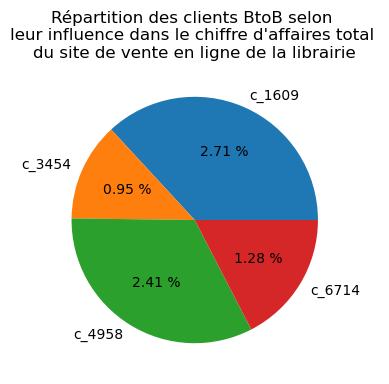

In [73]:
# Répartition du CA pour les clients BtoB (BtoB seuls sur CA total)

plt.figure(figsize = (4, 4))                                                                                  # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)

def autopct_real(values):                                                                                      # définit une fonction qui permet d'afficher les valeurs de la colonne "%_CA_total" dans les parts du diagramme
    def inner_autopct(pct):
        total = sum(values)
        val = pct * total / 100
        return f"{val:.2f} %"
    return inner_autopct

plt.pie(BtoB["%_CA_total"], labels = BtoB["client_id"], autopct = autopct_real(BtoB["%_CA_total"]))            # crée un diagramme montrant la répartition des clients BtoB parmi le chiffre d'affaire total du site de vente en ligne de la librairie
plt.title(f"Répartition des clients BtoB selon \nleur influence dans le chiffre d'affaires total \ndu site de vente en ligne de la librairie", fontsize = 12)   # ajoute un titre au graphique
plt.show()                                                                                                     # affiche le graphique créé


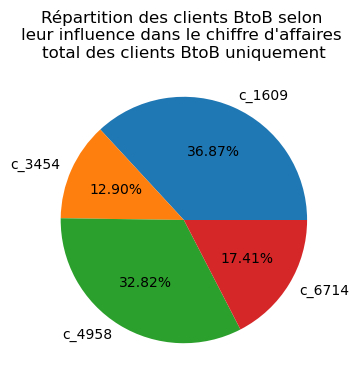

In [74]:
# Répartition du CA pour les clients BtoB (BtoB seuls sur CA BtoB uniquement)

BtoB["%_CA_BtoB"] = round(BtoB["panier_total"] * 100 / BtoB_CA, 2)                       # calcule la proportion que représente chaque client BtoB dans le chiffre d'affaire total des clients BtoB uniquement

plt.figure(figsize = (4, 4))                                                            # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
plt.pie(BtoB["%_CA_BtoB"], labels = BtoB["client_id"], autopct = "%1.2f%%")        # crée un diagramme circulaire montrant la répartition des clients BtoB parmi leur chiffre d'affaire (autocpct : permet d'afficher la valeur des parts pour plus de clarté)
plt.title(f"Répartition des clients BtoB selon \nleur influence dans le chiffre d'affaires \ntotal des clients BtoB uniquement", fontsize = 12)   # ajoute un titre au graphique
plt.show()                                                                               # affiche le graphique créé


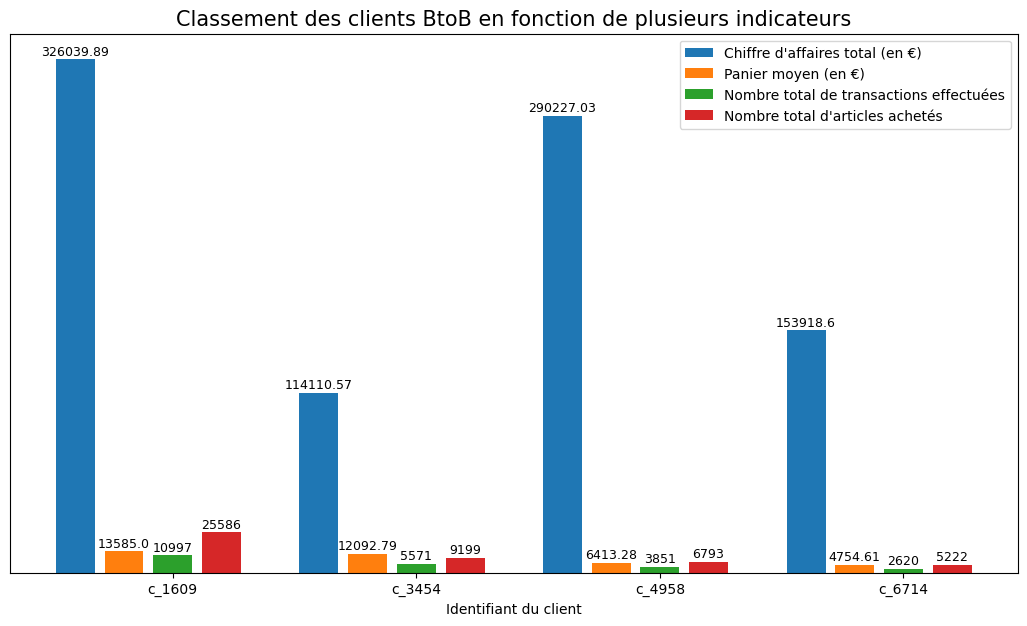

In [75]:
# Classement des clients BtoB (CA total, panier moyen, nombre de transactions, nombre d'articles achetés)

BtoB_panier_moy = copy.deepcopy(panier_clients_moy.loc[panier_clients_moy["client_id"].isin(clients_BtoB), :])            # récupère le panier moyen pour les 4 clients BtoB
BtoB_trans = copy.deepcopy(trans_clients.loc[trans_clients["client_id"].isin(clients_BtoB), :])                           # récupère le nombre total de transactions effectuées pour les 4 clients BtoB
BtoB_prod = copy.deepcopy(prod_clients.loc[prod_clients["client_id"].isin(clients_BtoB), :])                              # récupère le nombre total d'articles achetés pour les 4 clients BtoB

nb_clients = len(BtoB["client_id"])                                                                                       # récupère le nombre de clients à afficher pour ajuster l'espacement entre les barres
pos_x = np.arange(0, nb_clients * 5, 5)                                                                                   # génère la liste des positions des groupes de barres sur l'axe des abscisses (horizontal)

plt.figure(figsize = (13, 7))                                                                                             # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars1 = plt.bar([p - 2 for p in pos_x], BtoB["panier_total"].round(2), label = "Chiffre d'affaires total (en €)")      # crée les histogrammes représentant les classement de clients en fonction des indicateurs analysés
bars2 = plt.bar([p - 1 for p in pos_x], BtoB_panier_moy["panier_moyen"],  label = "Panier moyen (en €)") 
bars3 = plt.bar([p for p in pos_x], BtoB_trans["nb_transactions"],  label = "Nombre total de transactions effectuées")
bars4 = plt.bar([p + 1 for p in pos_x], BtoB_prod["nb_articles"],  label = "Nombre total d'articles achetés")

bars_series = [bars1, bars2, bars3, bars4]
for bars in bars_series :
    for bar in bars : 
        height = bar.get_height()                                                                                         # Mesure la taille de la barre  
        x_pos = bar.get_x() + bar.get_width() / 2                                                                         # récupère la position horizontale (centre de la barre)
        y_pos = height + 5000                                                                                             # récupère la position verticale (sommet de la barre + décalage vers le haut)
        plt.text(x_pos, y_pos, f"{height}", ha = "center", va = "center", fontsize = 9)                                   # ajuste les positions horizontale et verticale, et indique le format du texte à afficher
        
plt.title("Classement des clients BtoB en fonction de plusieurs indicateurs", fontsize = 15)                              # ajoute un titre au graphique
plt.xticks([i for i in pos_x], BtoB["client_id"])                                                                         # ajoute les identifiants des clients à l'axe des abscisses (horizontal) et ajuste l'écartement entre les groupes de barres
plt.xlabel("Identifiant du client")                                                                                       # ajoute un titre à l'axe des abscisses (horizontal)
plt.gca().get_yaxis().set_visible(False)                                                                                  # supprime l'affichage de l'axe des ordonnées (inutile ici)  
plt.legend()                                                                                                              # affiche la légende du graphique
plt.show()                                                                                                                # affiche le graphique créé


In [76]:
# vérification de l'âge des clients BtoB

age_BtoB = df_merge.loc[df_merge["client_id"].isin(clients_BtoB), ["client_id", "tranche_age"]].drop_duplicates()
age_BtoB


,client_id,tranche_age
104,c_1609,35-49
426,c_3454,50-64
910,c_6714,50-64
42283,c_4958,18-24


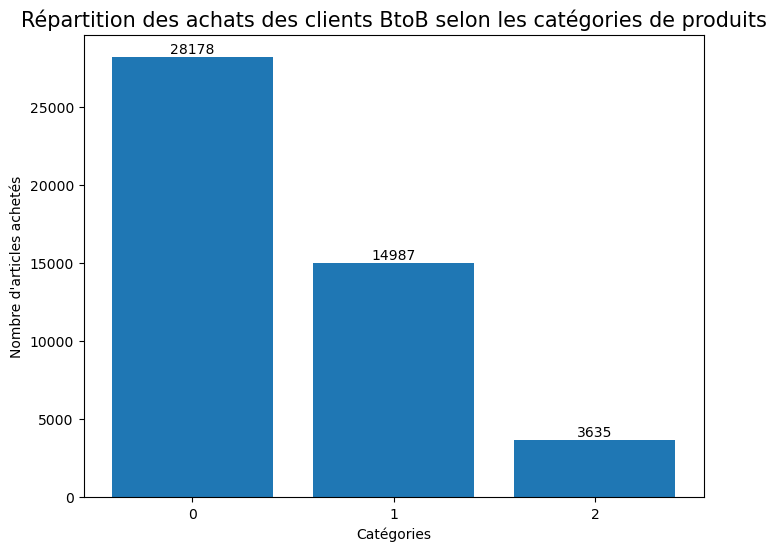

In [77]:
# Catégorie privilégiée par les clients BtoB

BtoB_cat = copy.deepcopy(df_merge.loc[df_merge["client_id"].isin(clients_BtoB), ["client_id", "categ", "id_prod"]])     # crée un nouveau dataframe contenant une copie des données de df_merge pour effectuer l'analyse sans compromettre les données initiales
BtoB_cat = BtoB_cat.groupby(["client_id", "categ"]).count().reset_index()                                               # agrégation des données pour obtenir le nombre d'articles achetés par catégorie et par tranche d'âge 
BtoB_cat.rename(columns = {"id_prod" : "nb_articles"}, inplace = True)                                                  # renome la colonne "id_prod" en nombre d'articles achetés pour plus de clarté de l'information observée

BtoB_cat_2 = BtoB_cat.loc[:, ["categ", "nb_articles"]]                                                 # récupère les colonnes nécessaires à cette analyse
BtoB_cat_2 = BtoB_cat_2.groupby("categ").sum().reset_index()                                           # agrégation des données pour obtenir le nombre total d'articles achetés par les clients BtoB en fonction de la catégorie à laquelle ils appartiennent

plt.figure(figsize = (8, 6))                                                                           # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars = plt.bar(BtoB_cat_2["categ"], BtoB_cat_2["nb_articles"])                                         # crée l'histogramme représentant le classement des catégories en fonction de nombre d'articles achetés par les clients BtoB
for bar in bars :
        height = bar.get_height()                                                                      # Mesure la taille de la barre  
        x_pos = bar.get_x() + bar.get_width() / 2                                                      # récupère la position horizontale (centre de la barre)
        y_pos = height + 500                                                                           # récupère la position verticale (sommet de la barre + décalage vers le bas)
        plt.text(x_pos, y_pos, f"{height}", ha = "center", va = "center")                              # ajuste les positions horizontale et verticale, et indique le format du texte à afficher)
plt.title("Répartition des achats des clients BtoB selon les catégories de produits", fontsize = 15)   # ajoute un titre au graphique
plt.xlabel("Catégories")                                                                               # ajoute un titre à l'axe des abscisses (horizontal)
plt.xticks(BtoB_cat_2["categ"])                                                                        # force l'affichage des catégorie sur l'axe des abscisses (horizontal)
plt.ylabel("Nombre d'articles achetés")                                                                # ajoute un titre à l'axe des ordonnées (vertical)
plt.show()                                                                                             # affiche le graphique créé

## Individuellement, 2 clients BtoB privilégient également la catégorie 0 (puis 1 puis 2) :"c_1609" et "c_6714". => tranches d'âges "35-49" et "50-64"
## Le client "c_4958", lui, privilégie plus la catégorie 2 (puis 1, puis 0).                                     => tranche d'âges "18-24"
## Enfin, le client "c_3454", quant à lui, privilégie plutôt la catégorie 1 (puis 0, puis 2)                     => tranche d'âges "50-64"
## => vérification faite avec l'affichage du dataframe "BtoB_cat".


<div style="border: 1px solid RGB(198,131,70);" >
<h3 style="margin: auto; padding: 20px; color: RGB(214,181,136); ">5.3 - Transactions</h3>
</div>

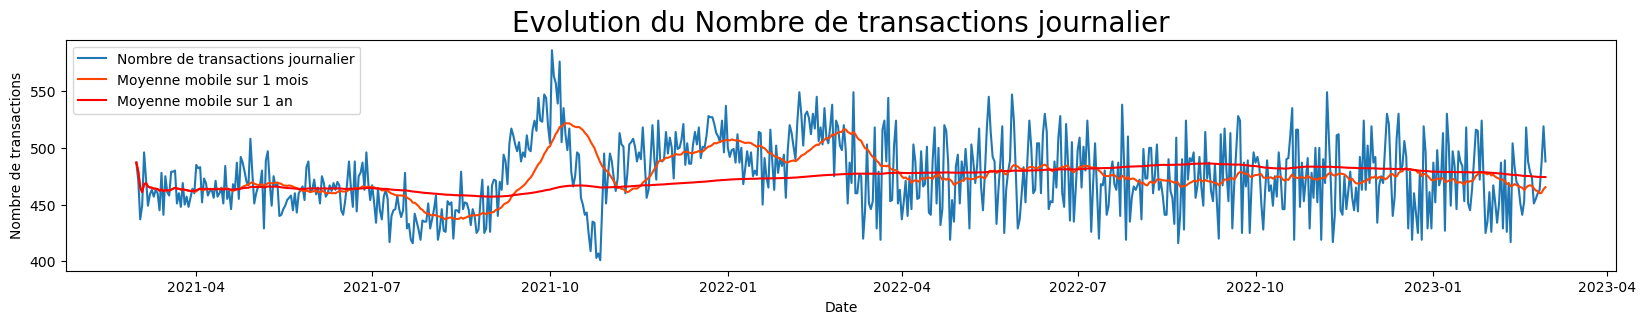

In [78]:
# Evolution du nombre de transactions journalier + moyenne mobile par mois et par années

df_trans = copy.deepcopy(df_merge.loc[:, ["date", "session_id"]])                                             # crée un nouveau dataframe avec une copie des données du df_merge pour effectuer l'analyse sans risquer de compromettre les données initiales
df_trans = df_trans.drop_duplicates()                                                                         # supprime les lignes dont le binome date + session_id est présent plusieurs fois
df_trans = df_trans.groupby("date").count().reset_index()                                                     # compte le nombre de lignes "session_id" par date (jour) pour créer le nombre de transaction journalier
df_trans.rename(columns = {"session_id" : "nb_transactions"}, inplace = True)                                 # renomme la colonne agrégée des session_id en Nombre de Transactions pour plus de clarté de l'information observée

df_trans["Moy_mob_mois"] = df_trans["nb_transactions"].rolling(window = 30, min_periods = 1).mean()           # calcule la moyenne mobile par mois
df_trans["Moy_mob_an"] = df_trans["nb_transactions"].rolling(window = 365, min_periods = 1).mean()            # calcule la moyenne mobile par année

plt.figure(figsize = (20, 3))                                                                                 # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
plt.plot(df_trans["date"], df_trans["nb_transactions"], label = "Nombre de transactions journalier")          # crée une courbe montrant l'évolution du nombre de transactions en fonction des jours
plt.plot(df_trans["date"], df_trans["Moy_mob_mois"], label = "Moyenne mobile sur 1 mois", color = "#FF4500")  # ajoute la courbe de la moyenne mobile sur 1 mois
plt.plot(df_trans["date"], df_trans["Moy_mob_an"], label = "Moyenne mobile sur 1 an", color = "red")          # ajoute la courbe de la moyenne mobile sur 1 année
plt.title("Evolution du Nombre de transactions journalier", fontsize = 20)                                    # ajoute un titre au graphique
plt.xlabel("Date")                                                                                            # ajoute un titre à l'axe des abscisses (horizontal)
plt.ylabel("Nombre de transactions")                                                                          # ajoute un titre à l'axe des ordonnées (vertical)
plt.legend()                                                                                                  # affiche la légende du graphique
plt.show()                                                                                                    # affiche le graphique créé
  

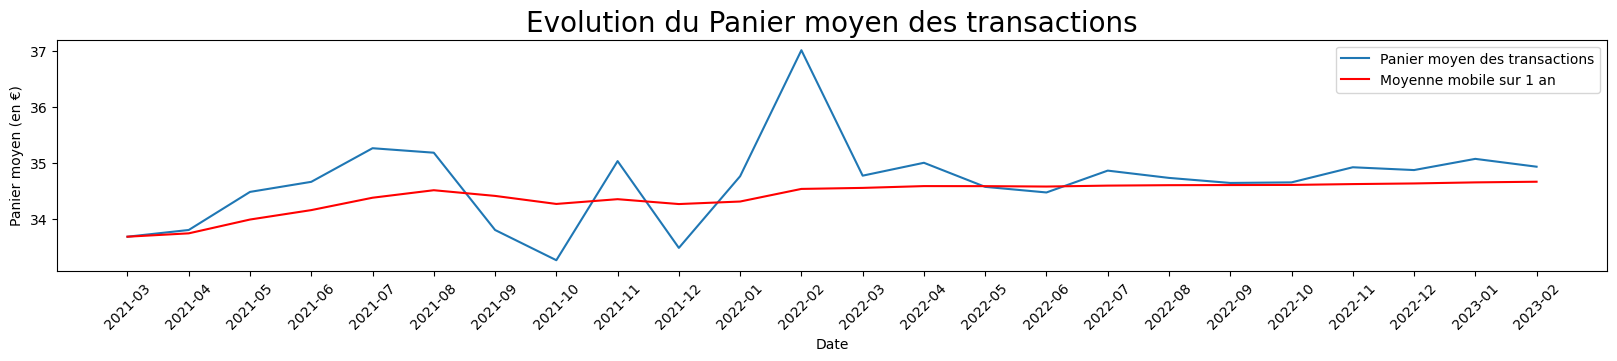

In [79]:
# Evolution du panier moyen des Transactions

panier_moy_trans = copy.deepcopy(df_merge.loc[:, ["date", "session_id", "price"]])              # crée un nouveau dataframe avec une copie des données du df_merge pour effectuer l'analyse sans risquer de compromettre les données initiales
panier_moy_trans = panier_moy_trans.groupby(["date", "session_id"]).sum().reset_index()         # agrégation des données en fonction de la date et de la session_id pour obtenir le montant total de chaque transaction
panier_moy_trans["date"] = panier_moy_trans["date"].dt.to_period("M").dropna().astype(str)      # transformation de la date pour ne conserver que les mois et années
panier_moy_trans.drop(columns = "session_id", inplace = True)                                   # suppression de la colonne session_id car nous n'en auront plus besoin pour cette analyse
panier_moy_trans.rename(columns = {"price" : "panier_moyen"}, inplace = True)                   # renomme la colonne des prix en panier moyen pour plus de clarté de l'information observée
panier_moy_trans = panier_moy_trans.groupby(["date"]).mean().round(2).reset_index()             # agrégation des données en fonction de la date pour obtenir le montant moyen de chaque transaction en fonction des mois

panier_moy_trans["Moy_mob_an"] = panier_moy_trans["panier_moyen"].rolling(window = 365, min_periods = 1).mean()               # calcule la moyenne mobile par année

plt.figure(figsize = (20, 3))                                                                                                 # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
plt.plot(panier_moy_trans["date"], panier_moy_trans["panier_moyen"], label = "Panier moyen des transactions")                 # crée une courbe montrant l'évolution du panier moyen des transactions en fonction des mois
plt.plot(panier_moy_trans["date"], panier_moy_trans["Moy_mob_an"], label = "Moyenne mobile sur 1 an", color = "red")          # ajoute la courbe de la moyenne mobile sur 1 année
plt.title("Evolution du Panier moyen des transactions", fontsize = 20)                                                        # ajoute un titre au graphique
plt.xlabel("Date")                                                                                                            # ajoute un titre à l'axe des abscisses (horizontal)
plt.xticks(rotation = 45)                                                                                                     # ajuste l'affichage des valeurs de l'axe des abscisses (horizontal) pour plus de lisibilité
plt.ylabel("Panier moyen (en €)")                                                                                             # ajoute un titre à l'axe des ordonnées (vertical)
plt.legend()                                                                                                                  # affiche la légende du graphique
plt.show()                                                                                                    


<div style="border: 1px solid RGB(198,131,70);" >
<h3 style="margin: auto; padding: 20px; color: RGB(214,181,136); ">5.4 - Références</h3>
</div>

<div style="border: 1px solid RGB(198,131,70);" >
<h4 style="margin: auto; padding: 20px; color: RGB(214,181,136); ">5.4.1 - Individuel</h4>
</div>

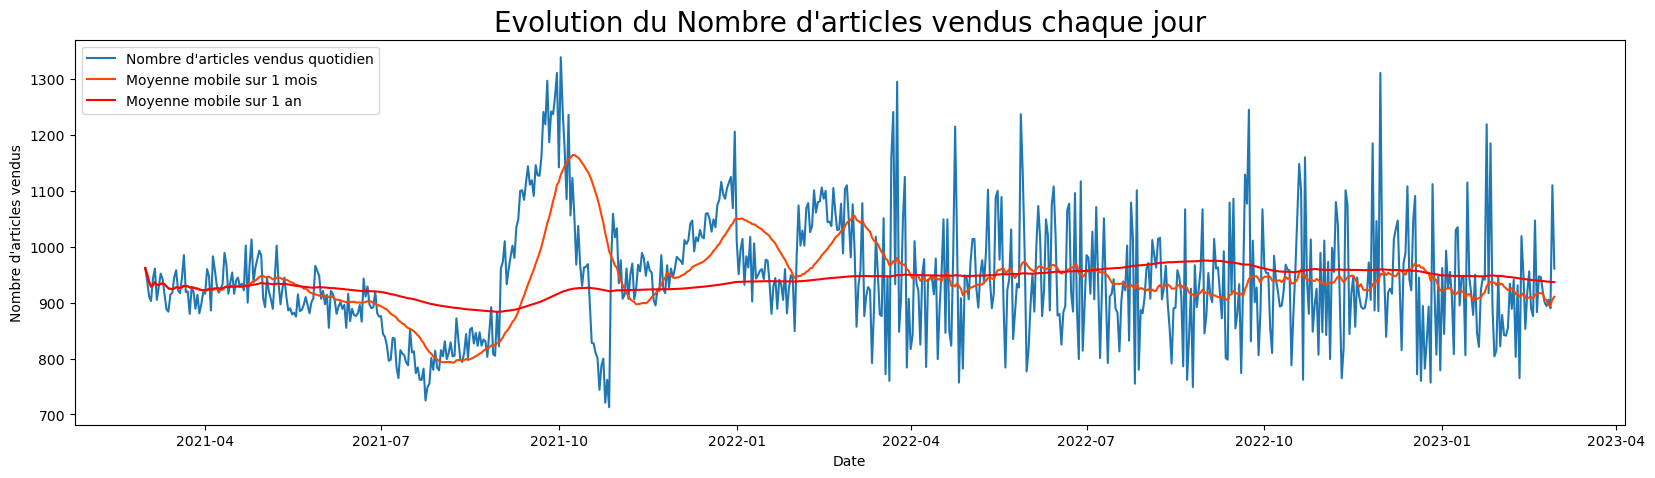

In [80]:
# Evolution du nombre de produits vendus journalier + moyenne mobile par mois et par années

df_prod = copy.deepcopy(df_merge.loc[:, ["date", "id_prod"]])                                              # crée un nouveau dataframe avec une copie des données du df_merge pour effectuer l'analyse sans risquer de compromettre les données initiales
df_prod = df_prod.groupby("date").count().reset_index()                                                    # compte le nombre de lignes "id_prod" par date (jour) pour créer le nombre d'articles vendus journalier
df_prod.rename(columns = {"id_prod" : "nb_articles"}, inplace = True)                                      # renomme la colonne agrégée des id_prod en Nombre d'Articles pour plus de clarté de l'information observée

df_prod["Moy_mob_mois"] = df_prod["nb_articles"].rolling(window = 30, min_periods = 1).mean()              # calcule la moyenne mobile par mois
df_prod["Moy_mob_an"] = df_prod["nb_articles"].rolling(window = 365, min_periods = 1).mean()               # calcule la moyenne mobile par année

plt.figure(figsize = (20, 5))                                                                              # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
plt.plot(df_prod["date"], df_prod["nb_articles"], label = "Nombre d'articles vendus quotidien")            # crée une courbe montrant l'évolution du nombre d'articles vendus en fonction des jours
plt.plot(df_prod["date"], df_prod["Moy_mob_mois"], label = "Moyenne mobile sur 1 mois", color = "#FF4500") # ajoute la courbe de la moyenne mobile sur 1 mois
plt.plot(df_prod["date"], df_prod["Moy_mob_an"], label = "Moyenne mobile sur 1 an", color = "red")         # ajoute la courbe de la moyenne mobile sur 1 année
plt.title("Evolution du Nombre d'articles vendus chaque jour", fontsize = 20)                              # ajoute un titre au graphique
plt.xlabel("Date")                                                                                         # ajoute un titre à l'axe des abscisses (horizontal)
plt.ylabel("Nombre d'articles vendus")                                                                     # ajoute un titre à l'axe des ordonnées (vertical)
plt.legend()                                                                                               # affiche la légende du graphique
plt.show()                                                                                                 # affiche le graphique créé
  

In [81]:
# CA par référence + 20/80

df_ref = copy.deepcopy(df_merge.loc[:, ["date", "id_prod", "price"]]).dropna()                            # crée un nouveau dataframe avec une copie des données du df_merge pour effectuer l'analyse sans risquer de compromettre les données initiales
start_date = df_ref["date"].min()                                                                         # récupère la date de départ pour le calcul des périodes de 1 an 
                                                                                                          # => les données ne commencent pas au 01/01/2021 et ne finissent pas au 31/12/2022, nous ne pouvons donc pas utiliser les années calendaires classiques              
df_ref["periode"] = (df_ref["date"] - start_date).dt.days                                                 # compte le nombre de jours entre la date selectionnée et la date de départ
df_ref["periode"] = df_ref["periode"].apply(lambda x : "2021-2022" if x <= 365 else "2022-2023")          # affiche le nom de la période de 1 an correspondante en fonction du nombre de jours écoulés depuis la date de départ (base 365 jours = 1 an)
df_ref.drop(columns = "date", inplace = True)                                                             # supprime la colonne des dates car nous n'en avons plus besoin pour cette analyse

CA_ref = df_ref.groupby(["periode", "id_prod"]).sum().reset_index()                                       # agrégation des données pour obtenir le chiffre d'affaire total de chaque référence en fonction de l'année
CA_ref.rename(columns = {"price" : "CA_ref"}, inplace = True)                                             # renomme la colonne des prix en Chiffre d'Affaire pour plus de clarté de l'information observée
CA_ref = CA_ref.sort_values(by = "CA_ref", ascending = False)                                             # trie les données pour afficher les valeurs de CA dans l'ordre décroissant (du plus grand au plus petit)

CA_ref_y1 = copy.deepcopy(CA_ref.loc[CA_ref["periode"] == "2021-2022", :])                                # récupère les lignes correspondant à la période 2021-2022 dans un nouveau dataframe
total_CA_y1 = CA_ref_y1["CA_ref"].sum()                                                                   # calcule le CA total effectué pour la 1ère année (2021-2022)
CA_ref_y1["%_CA"] = round(CA_ref_y1["CA_ref"] * 100 / total_CA_y1, 2)                                     # calcul du pourcentage de CA que l'article représente par rapport au CA total de l'année 2021-2022
CA_ref_y1["%_CA_cum"] = CA_ref_y1["%_CA"].cumsum()                                                        # calcule la somme cumulée du pourcentage de CA que représente l'article dans le CA total de l'année 2021-2022  
CA80_y1 = CA_ref_y1.loc[CA_ref_y1["%_CA_cum"] <= 80, :]                                                   # récupère les lignes jusqu'à atteindre la somme cumulative de 80% (inclue)
nb_prod_CA80_y1 = CA80_y1["id_prod"].count()                                                              # compte le nombre de produits (nombre de lignes) ayant représenté 80% du chiffre d'affaire de l'année 2021-2022
total_ref_vendues = df_merge["id_prod"].nunique()                                                         # compte le nombre total de références vendues par la librairie (en ligne)
prop_CA80_y1 = round(nb_prod_CA80_y1 * 100 / total_ref_vendues, 2)                                        # calcule la proportion d'articles qui ont représenté 80% du chiffre d'affaire en 2021-2022 parmi la totalité des références vendues par la librairie (en ligne)
print(f"En 2021-2022, 80% du chiffre d'affaires a été effectué par {nb_prod_CA80_y1} articles, ce qui représente {prop_CA80_y1} % des références proposées par la librairie sur le site de vente en ligne.")

CA_ref_y2 = copy.deepcopy(CA_ref.loc[CA_ref["periode"] == "2022-2023", :])                                # récupère les lignes correspondant à la période 2022-2023 dans un nouveau dataframe
total_CA_y2 = CA_ref_y2["CA_ref"].sum()                                                                   # calcule le CA total effectué pour la 2ème année (2022-2023)
CA_ref_y2["%_CA"] = round(CA_ref_y2["CA_ref"] * 100 / total_CA_y2, 2)                                     # calcul du pourcentage de CA que l'article représente par rapport au CA total de l'année 2022-2023
CA_ref_y2["%_CA_cum"] = CA_ref_y2["%_CA"].cumsum()                                                        # calcule la somme cumulée du pourcentage de CA que représente l'article dans le CA total de l'année 2022-2023  
CA80_y2 = CA_ref_y2.loc[CA_ref_y2["%_CA_cum"] <= 80, :]                                                   # récupère les lignes jusqu'à atteindre la somme cumulative de 80% (inclue)
nb_prod_CA80_y2 = CA80_y2["id_prod"].count()                                                              # compte le nombre de produits (nombre de lignes) ayant représenté 80% du chiffre d'affaire de l'année 2022-2023
prop_CA80_y2 = round(nb_prod_CA80_y2 * 100 / total_ref_vendues, 2)                                        # calcule la proportion d'articles qui ont représenté 80% du chiffre d'affaire en 2022-2023 parmi la totalité des références vendues par la librairie (en ligne)
print(f"\nEn 2022-2023, 80% du chiffre d'affaires a été effectué par {nb_prod_CA80_y2} articles, ce qui représente {prop_CA80_y2} % des références proposées par la librairie sur le site de vente en ligne.")

CA_ref_tot = copy.deepcopy(CA_ref.loc[:, ["id_prod", "CA_ref"]])                                           # récupère uniquement les 2 colonnes nécessaires à ce calcul dans un nouveau dataframe
CA_ref_tot = CA_ref_tot.groupby("id_prod").sum().reset_index()                                             # agrégation des données pour obtenir le CA total de chaque référence sur les 2 années écoulées
CA_ref_tot = CA_ref_tot.sort_values(by = "CA_ref", ascending = False)                                      # trie les données pour afficher les valeurs de CA dans l'ordre décroissant (du plus grand au plus petit)
total_CA = CA_ref_tot["CA_ref"].sum()                                                                      # calcule le CA total effectué sur les 2 années écoulées
CA_ref_tot["%_CA"] = round(CA_ref_tot["CA_ref"] * 100 / total_CA, 2)                                       # calcul du pourcentage de CA que l'article représente par rapport au CA total des 2 années
CA_ref_tot["%_CA_cum"] = CA_ref_tot["%_CA"].cumsum()                                                       # calcule la somme cumulée du pourcentage de CA que représente l'article dans le CA total des 2 années  
CA80_tot = CA_ref_tot.loc[CA_ref_tot["%_CA_cum"] <= 80, :]                                                 # récupère les lignes jusqu'à atteindre la somme cumulative de 80% (inclue)
nb_prod_CA80_tot = CA80_tot["id_prod"].count()                                                             # compte le nombre de produits (nombre de lignes) ayant représenté 80% du chiffre d'affaire sur les 2 années écoulées
prop_CA80_tot = round(nb_prod_CA80_tot * 100 / total_ref_vendues, 2)                                       # calcule la proportion d'articles qui ont représenté 80% du chiffre d'affaire sur les 2 années parmi la totalité des références vendues par la librairie (en ligne)
print(f"\nAu total, sur les 2 années écoulées, 80% du chiffre d'affaires a été effectué par {nb_prod_CA80_tot} articles, ce qui représente {prop_CA80_tot} % des références proposées par la librairie sur le site de vente en ligne.")


En 2021-2022, 80% du chiffre d'affaires a été effectué par 700 articles, ce qui représente 21.3 % des références proposées par la librairie sur le site de vente en ligne.

En 2022-2023, 80% du chiffre d'affaires a été effectué par 687 articles, ce qui représente 20.91 % des références proposées par la librairie sur le site de vente en ligne.

Au total, sur les 2 années écoulées, 80% du chiffre d'affaires a été effectué par 691 articles, ce qui représente 21.03 % des références proposées par la librairie sur le site de vente en ligne.


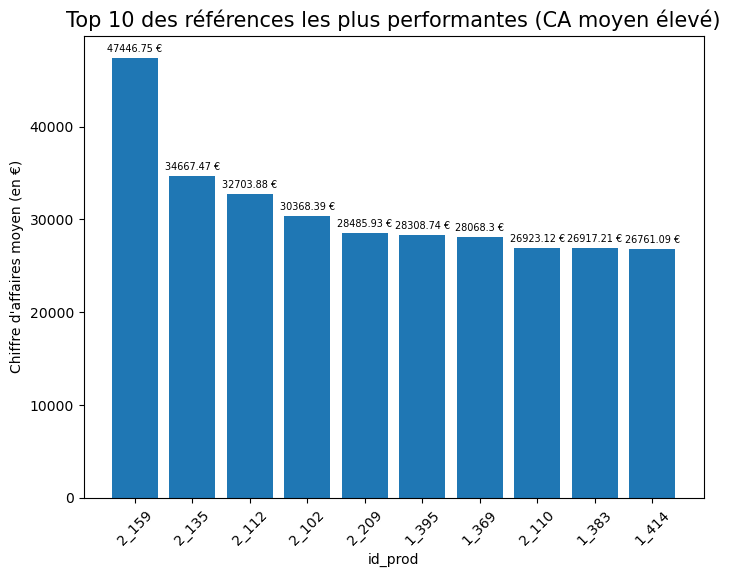

In [82]:
# Top Références CA

CA_ref.drop(columns = ["periode"], inplace = True)                        # supprime la colonne "periode" car nous n'en aurons plus besoin pour le reste de l'analyse
ref_CA = CA_ref.groupby("id_prod").mean().round(2).reset_index()          # agrégation des données pour obtenir le CA moyen de chaque référence sur les 2 années écoulées
ref_CA = ref_CA.sort_values(by = "CA_ref", ascending = False)             # trie les données pour afficher les valeurs de CA dans l'ordre décroissant (du plus grand au plus petit)
Top_ref_CA = ref_CA.head(10)                                              # conserve les 10 premières lignes du tableau trié pour afficher le Top 10 des références ayant effectué le plus gros chiffre d'affaire moyen sur les 2 années écoulées

plt.figure(figsize = (8, 6))                                             # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars = plt.bar(Top_ref_CA["id_prod"], Top_ref_CA["CA_ref"])               # crée un histogramme montrant les 10 références ayant généré le plus de chiffre d'affaires sur les 2 années dans l'ordre décroissant (du + au -)
for bar in bars :
    height = bar.get_height()                                                                          # Mesure la taille de la barre  
    x_pos = bar.get_x() + bar.get_width() / 2                                                          # récupère la position horizontale (centre de la barre)
    y_pos = height + 1000                                                                              # récupère la position verticale (sommet de la barre + décalage vers le bas)
    plt.text(x_pos, y_pos, f"{height} €", ha = "center", va = "center", fontsize = 7)                  # ajuste les positions horizontale et verticale, et indique le texte à afficher 
plt.title("Top 10 des références les plus performantes (CA moyen élevé)", fontsize = 15)               # ajoute un titre au graphique
plt.xlabel("id_prod")                                                                                  # ajoute un titre à l'axe des abscisses (horizontal)
plt.xticks(rotation = 45)
plt.ylabel("Chiffre d'affaires moyen (en €)")                                                          # ajoute un titre à l'axe des ordonnées (vertical)
plt.show()                                                                                             # affiche le graphique créé


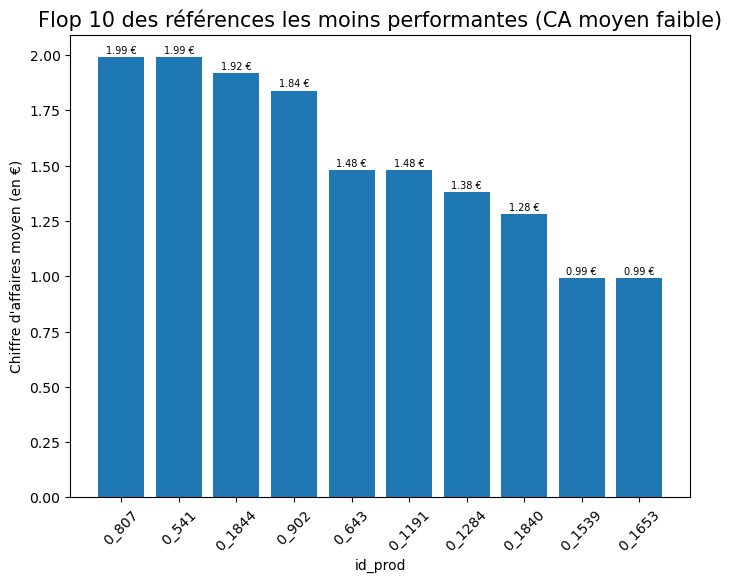

In [83]:
# Flop Références CA

Flop_ref_CA = ref_CA.tail(10)                                          # conserve les 10 dernières lignes du tableau trié pour afficher le Flop 10 des références ayant effectué le plus petit chiffre d'affaire moyen sur les 2 années écoulées
 
plt.figure(figsize = (8, 6))                                           # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars = plt.bar(Flop_ref_CA["id_prod"], Flop_ref_CA["CA_ref"])          # crée un histogramme montrant les 10 références ayant généré le moins de chiffre d'affaires sur les 2 années dans l'ordre décroissant (du + au -)
for bar in bars :
    height = bar.get_height()                                                                          # Mesure la taille de la barre  
    x_pos = bar.get_x() + bar.get_width() / 2                                                          # récupère la position horizontale (centre de la barre)
    y_pos = height + 0.03                                                                              # récupère la position verticale (sommet de la barre + décalage vers le bas)
    plt.text(x_pos, y_pos, f"{height} €", ha = "center", va = "center", fontsize = 7)                  # ajuste les positions horizontale et verticale, et indique le texte à afficher 
plt.title("Flop 10 des références les moins performantes (CA moyen faible)", fontsize = 15)            # ajoute un titre au graphique
plt.xlabel("id_prod")                                                                                  # ajoute un titre à l'axe des abscisses (horizontal)
plt.xticks(rotation = 45)
plt.ylabel("Chiffre d'affaires moyen (en €)")                                                          # ajoute un titre à l'axe des ordonnées (vertical)
plt.show()                                                                                             # affiche le graphique créé


In [84]:
# Nombre de produits vendus par référence + 20/80

ref_ventes = df_ref.groupby(["periode", "id_prod"]).count().reset_index()                                 # agrégation des données pour obtenir le nombre total de ventes de chaque référence en fonction de l'année
ref_ventes.rename(columns = {"price" : "nb_art_vendus"}, inplace = True)                                  # renomme la colonne des prix en Nombre d'articles vendus pour plus de clarté de l'information observée
ref_ventes = ref_ventes.sort_values(by = "nb_art_vendus", ascending = False)                              # trie les données pour afficher les valeurs dans l'ordre décroissant du nombre d'articles vendus (du plus grand au plus petit)

ref_ventes_y1 = copy.deepcopy(ref_ventes.loc[ref_ventes["periode"] == "2021-2022", :])                    # récupère les lignes correspondant à la période 2021-2022 dans un nouveau dataframe
total_ventes_y1 = ref_ventes_y1["nb_art_vendus"].sum()                                                    # calcule le nombre total d'articles vendus pour la 1ère année (2021-2022)
ref_ventes_y1["%_ventes"] = round(ref_ventes_y1["nb_art_vendus"] * 100 / total_ventes_y1, 2)              # calcul du pourcentage de ventes que l'article représente par rapport aux ventes totales de l'année 2021-2022
ref_ventes_y1["%_ventes_cum"] = ref_ventes_y1["%_ventes"].cumsum()                                        # calcule la somme cumulée du pourcentage de ventes que représente l'article dans les ventes totales de l'année 2021-2022  
ventes80_y1 = ref_ventes_y1.loc[ref_ventes_y1["%_ventes_cum"] <= 80, :]                                   # récupère les lignes jusqu'à atteindre la somme cumulative de 80% (inclue)
nb_prod_ventes80_y1 = ventes80_y1["id_prod"].count()                                                      # compte le nombre de produits (nombre de lignes) ayant représenté 80% des ventes de l'année 2021-2022
total_ref_vendues = df_merge["id_prod"].nunique()                                                         # compte le nombre total de références vendues par la librairie (en ligne)
prop_ventes80_y1 = round(nb_prod_ventes80_y1 * 100 / total_ref_vendues, 2)                                # calcule la proportion d'articles qui ont représenté 80% des ventes en 2021-2022 parmi la totalité des références vendues par la librairie (en ligne)
print(f"En 2021-2022, 80% des ventes ont été effectuées par {nb_prod_ventes80_y1} articles, ce qui représente {prop_ventes80_y1} % des références proposées par la librairie sur le site de vente en ligne.")

ref_ventes_y2 = copy.deepcopy(ref_ventes.loc[ref_ventes["periode"] == "2022-2023", :])                    # récupère les lignes correspondant à la période 2022-2023 dans un nouveau dataframe
total_ventes_y2 = ref_ventes_y2["nb_art_vendus"].sum()                                                    # calcule le nombre total d'articles vendus pour la 2ème année (2022-2023)
ref_ventes_y2["%_ventes"] = round(ref_ventes_y2["nb_art_vendus"] * 100 / total_ventes_y2, 2)              # calcul du pourcentage de ventes que l'article représente par rapport aux ventes totales de l'année 2022-2023
ref_ventes_y2["%_ventes_cum"] = ref_ventes_y2["%_ventes"].cumsum()                                        # calcule la somme cumulée du pourcentage de ventes que représente l'article dans les ventes totales de l'année 2022-2023  
ventes80_y2 = ref_ventes_y2.loc[ref_ventes_y2["%_ventes_cum"] <= 80, :]                                   # récupère les lignes jusqu'à atteindre la somme cumulative de 80% (inclue)
nb_prod_ventes80_y2 = ventes80_y2["id_prod"].count()                                                      # compte le nombre de produits (nombre de lignes) ayant représenté 80% des ventes de l'année 2022-2023
prop_ventes80_y2 = round(nb_prod_ventes80_y2 * 100 / total_ref_vendues, 2)                                # calcule la proportion d'articles qui ont représenté 80% des ventes en 2021-2022 parmi la totalité des références vendues par la librairie (en ligne)
print(f"\nEn 2022-2023, 80% des ventes ont été effectuées par {nb_prod_ventes80_y2} articles, ce qui représente {prop_ventes80_y2} % des références proposées par la librairie sur le site de vente en ligne.")

ref_ventes_tot = copy.deepcopy(ref_ventes.loc[:, ["id_prod", "nb_art_vendus"]])                           # récupère uniquement les 2 colonnes nécessaires à ce calcul dans un nouveau dataframe
ref_ventes_tot = ref_ventes_tot.groupby("id_prod").sum().reset_index()                                    # agrégation des données pour obtenir le nombre total de ventes de chaque référence sur les 2 années écoulées
ref_ventes_tot = ref_ventes_tot.sort_values(by = "nb_art_vendus", ascending = False)                      # trie les données pour afficher les valeurs dans l'ordre décroissant du nombre d'articles vendus (du plus grand au plus petit)
total_ventes = ref_ventes_tot["nb_art_vendus"].sum()                                                      # calcule le nombre de ventes total effectué sur les 2 années écoulées
ref_ventes_tot["%_ventes"] = round(ref_ventes_tot["nb_art_vendus"] * 100 / total_ventes, 2)               # calcul du pourcentage de ventes que l'article représente par rapport au nombre de ventes total des 2 années
ref_ventes_tot["%_ventes_cum"] = ref_ventes_tot["%_ventes"].cumsum()                                      # calcule la somme cumulée du pourcentage de ventes que représente l'article dans le nombre total de ventes des 2 années  
ventes80_tot = ref_ventes_tot.loc[ref_ventes_tot["%_ventes_cum"] <= 80, :]                                # récupère les lignes jusqu'à atteindre la somme cumulative de 80% (inclue)
nb_prod_ventes80_tot = ventes80_tot["id_prod"].count()                                                    # compte le nombre de produits (nombre de lignes) ayant représenté 80% des ventes sur les 2 années écoulées
prop_ventes80_tot = round(nb_prod_ventes80_tot * 100 / total_ref_vendues, 2)                              # calcule la proportion d'articles qui ont représenté 80% des ventes sur les 2 années parmi la totalité des références vendues par la librairie (en ligne)
print(f"\nAu total, sur les 2 années écoulées, 80% des ventes ont été effectuées par {nb_prod_ventes80_tot} articles, ce qui représente {prop_ventes80_tot} % des références proposées par la librairie sur le site de vente en ligne.")


En 2021-2022, 80% des ventes ont été effectuées par 808 articles, ce qui représente 24.59 % des références proposées par la librairie sur le site de vente en ligne.

En 2022-2023, 80% des ventes ont été effectuées par 804 articles, ce qui représente 24.47 % des références proposées par la librairie sur le site de vente en ligne.

Au total, sur les 2 années écoulées, 80% des ventes ont été effectuées par 806 articles, ce qui représente 24.53 % des références proposées par la librairie sur le site de vente en ligne.


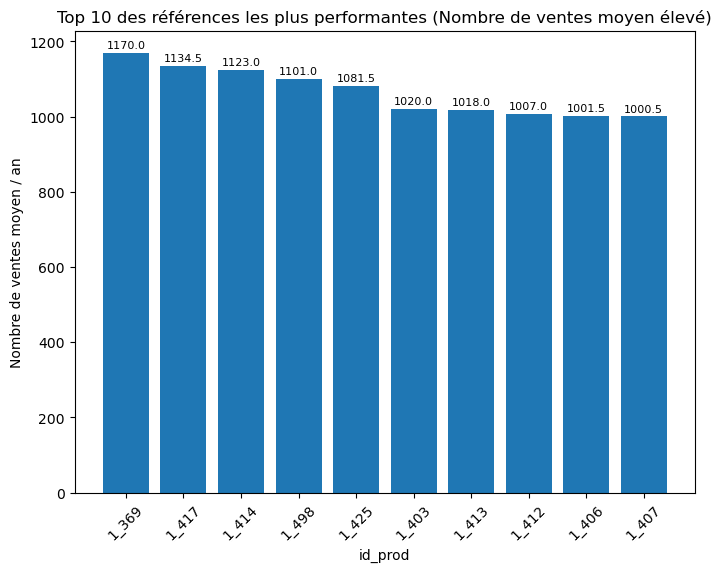

In [85]:
# Top Références Nombre de ventes

ref_ventes.drop(columns = ["periode"], inplace = True)                                   # supprime la colonne "periode" car nous n'en aurons plus besoin pour le reste de l'analyse
ventes_ref = ref_ventes.groupby("id_prod").mean().round(2).reset_index()                 # agrégation des données pour obtenir le nombre de ventes moyen de chaque référence sur les 2 années écoulées
ventes_ref = ventes_ref.sort_values(by = "nb_art_vendus", ascending = False)             # trie les données pour afficher les valeurs dans l'ordre décroissant (du plus grand au plus petit) du nombre de ventes
Top_ref_ventes = ventes_ref.head(10)                                                     # conserve les 10 premières lignes du tableau trié pour afficher le Top 10 des références ayant effectué le plus gros nombre de ventes moyen sur les 2 années écoulées

plt.figure(figsize = (8, 6))                                                             # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars = plt.bar(Top_ref_ventes["id_prod"], Top_ref_ventes["nb_art_vendus"])               # crée un histogramme montrant les 10 références ayant effectué le plus gros nombre de ventes moyen sur les 2 années dans l'ordre décroissant (du + au -)
for bar in bars :
    height = bar.get_height()                                                                            # Mesure la taille de la barre  
    x_pos = bar.get_x() + bar.get_width() / 2                                                            # récupère la position horizontale (centre de la barre)
    y_pos = height + 20                                                                                  # récupère la position verticale (sommet de la barre + décalage vers le bas)
    plt.text(x_pos, y_pos, f"{height}", ha = "center", va = "center", fontsize = 8)                      # ajuste les positions horizontale et verticale, et indique le texte à afficher 
plt.title("Top 10 des références les plus performantes (Nombre de ventes moyen élevé)", fontsize = 12)   # ajoute un titre au graphique
plt.xlabel("id_prod")                                                                                    # ajoute un titre à l'axe des abscisses (horizontal)
plt.xticks(rotation = 45)
plt.ylabel("Nombre de ventes moyen / an")                                                                # ajoute un titre à l'axe des ordonnées (vertical)
plt.show()                                                                                               # affiche le graphique créé


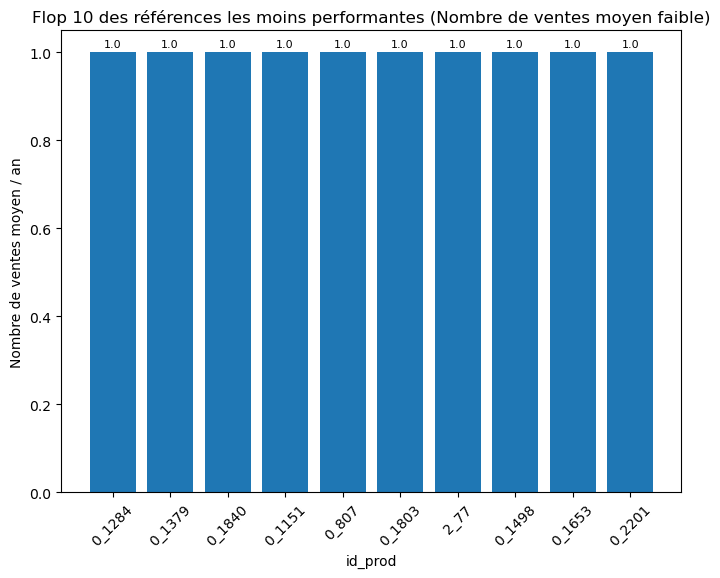

In [86]:
# Flop Références Nombre de ventes

Flop_ref_ventes = ventes_ref.tail(10)                                                     # conserve les 10 dernières lignes du tableau trié pour afficher le Flop 10 des références ayant effectué le plus petit nombre de ventes moyen sur les 2 années écoulées

plt.figure(figsize = (8, 6))                                                             # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars = plt.bar(Flop_ref_ventes["id_prod"], Flop_ref_ventes["nb_art_vendus"])             # crée un histogramme montrant les 10 références ayant effectué le plus petit nombre de ventes moyen sur les 2 années dans l'ordre décroissant (du + au -)
for bar in bars :
    height = bar.get_height()                                                                               # Mesure la taille de la barre  
    x_pos = bar.get_x() + bar.get_width() / 2                                                               # récupère la position horizontale (centre de la barre)
    y_pos = height + 0.02                                                                                   # récupère la position verticale (sommet de la barre + décalage vers le bas)
    plt.text(x_pos, y_pos, f"{height}", ha = "center", va = "center", fontsize = 8)                         # ajuste les positions horizontale et verticale, et indique le texte à afficher 
plt.title("Flop 10 des références les moins performantes (Nombre de ventes moyen faible)", fontsize = 12)   # ajoute un titre au graphique
plt.xlabel("id_prod")                                                                                       # ajoute un titre à l'axe des abscisses (horizontal)
plt.xticks(rotation = 45)
plt.ylabel("Nombre de ventes moyen / an")                                                                        # ajoute un titre à l'axe des ordonnées (vertical)
plt.show()                                                                                                  # affiche le graphique créé


<div style="border: 1px solid RGB(198,131,70);" >
<h4 style="margin: auto; padding: 20px; color: RGB(214,181,136); ">5.4.2 - Par Catégorie</h4>
</div>

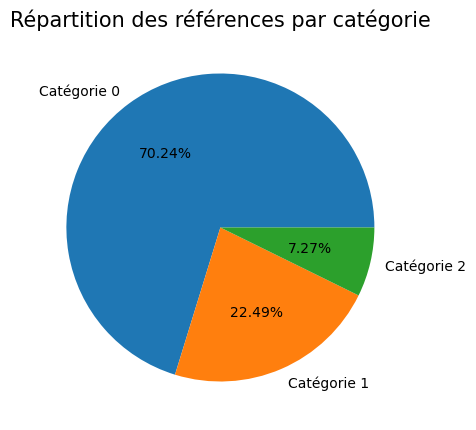

In [87]:
# Répartition des références par catégories

prod_categ = copy.deepcopy(df_merge.loc[:, ["id_prod", "categ"]])                        # crée un nouveau dataframe avec une copie des données du df_merge pour effectuer l'analyse sans risquer de compromettre les données initiales
prod_categ = prod_categ.dropna().drop_duplicates()                                       # supprime les lignes vides et les binomes "id_prod + categ" présents plusieurs fois (doublons)
prod_categ = prod_categ.groupby("categ").count().reset_index()                           # compte le nombre de lignes "id_prod" par catégorie pour créer le nombre de références vendues correspondant à chaque catégorie
prod_categ.rename(columns = {"id_prod" : "nb_ref"}, inplace = True)                      # renomme la colonne des "id_prod" en Nombre de références pour plus de clarté de l'information observée
total_ref = prod_categ["nb_ref"].sum()                                                   # calcule le nombre total de références vendues par la librairie (en ligne)
prod_categ["%_prod"] = round(prod_categ["nb_ref"] * 100 / total_ref, 2)                  # calcule la proportion de références présentes dans chaque catégorie par rapport au total des références vendues par la librairie (en ligne)

plt.figure(figsize = (10, 5))                                                            # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces
label = ["Catégorie " + str(cat) for cat in prod_categ["categ"]]                         # indique le texte à afficher en légende du diagramme
plt.pie(prod_categ["%_prod"], labels = label, autopct = "%1.2f%%")                       # crée un diagramme circulaire montrant la répartition des références vendues dans chaque catégorie (autocpct : permet d'afficher la valeur des parts pour plus de clarté)
plt.title("Répartition des références par catégorie", fontsize = 15)                     # ajoute un titre au graphique
plt.show()                                                                               # affiche le graphique créé


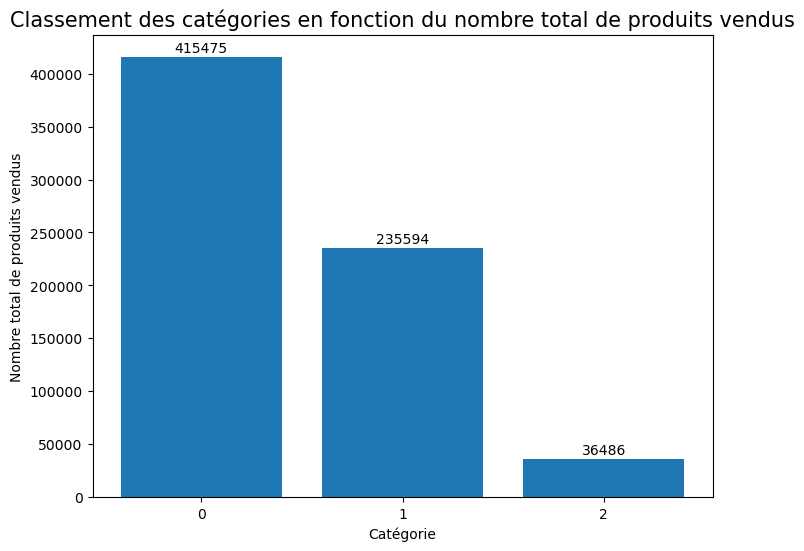

In [88]:
# Classement des Catégories en fonction du Nombre total de ventes

categ_ventes = copy.deepcopy(df_merge.loc[:, ["id_prod", "categ"]]).dropna()          # crée un nouveau dataframe avec une copie des données du df_merge pour effectuer l'analyse sans risquer de compromettre les données initiales + supprime les lignes vides
categ_ventes = categ_ventes.groupby("categ").count().reset_index()                    # compte le nombre de lignes "id_prod" par catégorie pour créer le nombre total de produits vendus dans chaque catégorie
categ_ventes.rename(columns = {"id_prod" : "nb_prod_vendus"}, inplace = True)         # renomme la colonne des "id_prod" en Nombre de produits vendus pour plus de clarté de l'information observée
categ_ventes = categ_ventes.sort_values(by = "nb_prod_vendus", ascending = False)     # trie les données pour afficher les valeurs de "nb_prod_vendus" dans l'ordre décroissant (du plus grand au plus petit)

plt.figure(figsize = (8, 6))                                                                                # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars = plt.bar(categ_ventes["categ"], categ_ventes["nb_prod_vendus"])                                        # crée un histogramme montrant le classement des catégories dans l'ordre décroissant (du + au -) de leur nombre total de produits vendus
for bar in bars :
    height = bar.get_height()                                                                                # Mesure la taille de la barre  
    x_pos = bar.get_x() + bar.get_width() / 2                                                                # récupère la position horizontale (centre de la barre)
    y_pos = height + 8000                                                                                    # récupère la position verticale (sommet de la barre + décalage vers le haut)
    plt.text(x_pos, y_pos, f"{height}", ha = "center", va = "center", fontsize = 10)                         # ajuste les positions horizontale et verticale, et indique le texte à afficher 
plt.title("Classement des catégories en fonction du nombre total de produits vendus", fontsize = 15)         # ajoute un titre au graphique
plt.xlabel("Catégorie")                                                                                      # ajoute un titre à l'axe des abscisses (horizontal)
plt.xticks(categ_ventes["categ"])                                                                            # ajuste l'affichage des valeurs sur l'axe des abscisses (horizontal) pour n'afficher que les 3 catégories analysées
plt.ylabel("Nombre total de produits vendus")                                                                # ajoute un titre à l'axe des ordonnées (vertical)
plt.show()                                                                                                   # affiche le graphique créé


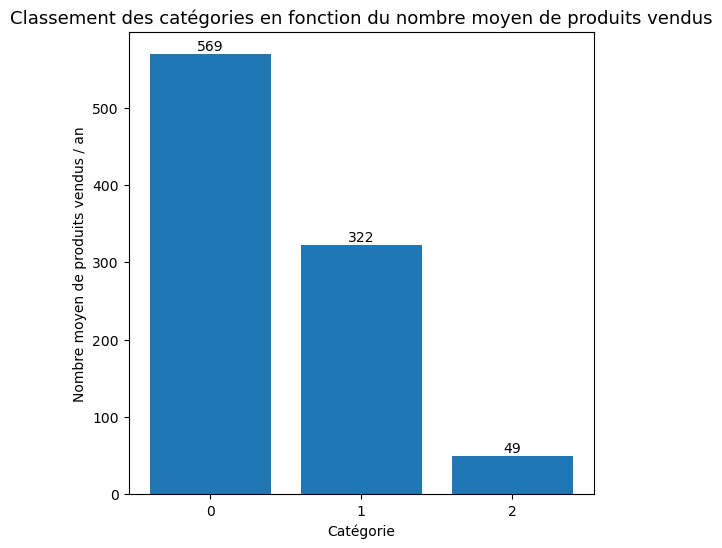

In [89]:
# Classement des Catégories en fonction du Nombre de ventes moyen

categ_ventes_moy = copy.deepcopy(df_merge.loc[:, ["id_prod", "categ", "date"]])                       # crée un nouveau dataframe avec une copie des données du df_merge pour effectuer l'analyse sans risquer de compromettre les données initiales
categ_ventes_moy = categ_ventes_moy.groupby(["date", "categ"]).count().reset_index()                  # compte le nombre de lignes "id_prod" par catégorie et date pour créer le nombre total de produits vendus à chaque date
categ_ventes_moy.drop(columns = "date", inplace = True)                                               # supprime la colonne "date" car nous n'en avons plus besoin pour cette analyse
categ_ventes_moy = categ_ventes_moy.groupby(["categ"]).mean().astype(int).reset_index()               # agrégation des données en fonction de la catégorie pour obtenir le nombre moyen de produits vendus dans chaque catégorie
categ_ventes_moy.rename(columns = {"id_prod" : "moy_prod_vendus"}, inplace = True)                    # renomme la colonne des "id_prod" en Nombre moyen de produits vendus pour plus de clarté de l'information observée
categ_ventes_moy = categ_ventes_moy.sort_values(by = "moy_prod_vendus", ascending = False)            # trie les données pour afficher les valeurs de "moy_prod_vendus" dans l'ordre décroissant (du plus grand au plus petit)

plt.figure(figsize = (6, 6))                                                                                # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
bars = plt.bar(categ_ventes_moy["categ"], categ_ventes_moy["moy_prod_vendus"])                               # crée un histogramme montrant le classement des catégories dans l'ordre décroissant (du + au -) de leur nombre moyen de produits vendus
for bar in bars :
    height = bar.get_height()                                                                                # Mesure la taille de la barre  
    x_pos = bar.get_x() + bar.get_width() / 2                                                                # récupère la position horizontale (centre de la barre)
    y_pos = height + 10                                                                                      # récupère la position verticale (sommet de la barre + décalage vers le haut)
    plt.text(x_pos, y_pos, f"{height}", ha = "center", va = "center")                                        # ajuste les positions horizontale et verticale, et indique le texte à afficher 
plt.title("Classement des catégories en fonction du nombre moyen de produits vendus", fontsize = 13)         # ajoute un titre au graphique
plt.xlabel("Catégorie")                                                                                      # ajoute un titre à l'axe des abscisses (horizontal)
plt.xticks(categ_ventes_moy["categ"])                                                                        # ajuste l'affichage des valeurs sur l'axe des abscisses (horizontal) pour n'afficher que les 3 catégories analysées
plt.ylabel("Nombre moyen de produits vendus / an")                                                           # ajoute un titre à l'axe des ordonnées (vertical)
plt.show()                                                                                                   # affiche le graphique créé


<div style="background-color: RGB(214,181,136);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse du comportement des clients</h2>
</div>

In [90]:

## Pour les analyses suivantes nous allons écarter les clients BtoB qui correspondent à des valeurs extrêmes / "outlier" (CA total, panier moyen, nombre de transactions et nombre d'articles achetés très élevés par rapport aux autres clients)
## Ils peuvent donc influencer et induire un biais pour les analyses statistiques demandées (notamment la distribution des données).


In [91]:
# création d'un nouveau dataframe qui ne contient que les clients particuliers (BtoC) = clients BtoB mis de côté

df_stats = copy.deepcopy(df_merge.loc[~df_merge["client_id"].isin(clients_BtoB), :])   # récupère les lignes dont les identifiants clients ne sont pas présents dans la liste des identifiants de clients BtoB

df_verif = df_stats.loc[df_stats["client_id"].isin(clients_BtoB), :]                   # recherche les lignes dans le nouveau dataframe dont les identifiants clients sont ceux correspondant aux clients BtoB (le tableau doit être vide)
nb_BtoB_stats = df_verif["client_id"].nunique()                                        # compte le nombre de clients BtoB présents dans le dataframe de vérification (nombre d'identifiants BtoB trouvés uniques)
print(f"Il y a {nb_BtoB_stats} clients BtoB dans le tableau utilisé pour les analyses statistiques :")
df_verif

## la recherche des lignes dont l'identifiant client correspondant aux identifiants des clients BtoB renvoie un tableau vide. Nous avons donc bien écarté les clients BtoB de notre nouveau dataframe pour les futures analyses.


Il y a 0 clients BtoB dans le tableau utilisé pour les analyses statistiques :


,client_id,sex,id_prod,date,session_id,price,categ,age,tranche_age


<div style="border: 1px solid RGB(198,131,70);" >
<h3 style="margin: auto; padding: 20px; color: RGB(214,181,136); ">6.1 - Selon le genre des clients</h3>
</div>

Tableau de contingence :
categ       0       1      2
sex                         
f      200793  115721  16980
m      186488  104884  15868


Test de Chi-2 :
Résultat du test :  22.67
Valeur p :  0.000
Degrés de liberté : 2
Fréquences attendues :
[[201574.9  114822.13  17096.97]
 [185706.1  105782.87  15751.03]]
Rejet de H0 : il existe une corrélation significative entre les 2 variables (même faible).




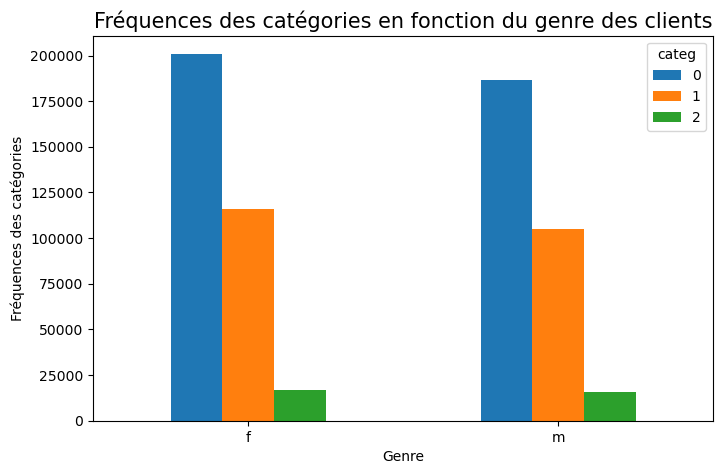

In [92]:
# Lien entre le genre d'un client et les catégories des livres achetés

## Choix du test : Chi-2
     ## - 2 variables qualitatives : genre et catégories de livres
     ## - fréquences théoriques des groupes >= 5


## Création du tableau de contingence contenant les données à analyser

df_categ = df_stats.loc[:, ["sex", "categ"]]                                                   # récupère les colonnes utiles pour cette analyse dans un nouveau dataframe
cont_table = pd.crosstab(df_categ["sex"], df_categ["categ"])                                   # crée le tableau de contingence contenant la fréquence d'apparition (fréquence observée) de chaque catégorie dans chaque genre (= nombre d'achats effectués pour chaque genre)
print(f"Tableau de contingence :")
print(cont_table)
print(f"\n")                                                                                   # permet de sauter 1 ligne entre les 2 affichages pour plus de lisibilité


## Test de Chi-2
    ## H0 = les 2 variables sont indépendantes (= 0)
    ## H1 = Les 2 variables ne sont pas indépendantes (proche de +/- 1)
    ## seuil d'erreur = 5% (0.05)
     
from scipy.stats import chi2_contingency
chi2_categ, p_value_chi2_categ, dof_categ, expected_categ = chi2_contingency(cont_table)       # applique le test de Chi-2 sur les fréquences attendues de chaque groupe "categorie-sexe"

print(f"Test de Chi-2 :")
print(f"Résultat du test : {chi2_categ : .2f}")                                                # indique la somme des écarts au carré (différence) entre les fréquences observées et les fréquences attendues de chaque groupe
print(f"Valeur p : {p_value_chi2_categ : .3f}")                                                # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
print(f"Degrés de liberté : {dof_categ}")
print(f"Fréquences attendues :")
print(np.round(expected_categ, 2))                                                             # affiche les fréquences théoriques de chaque groupe "catégorie-genre" pour valider l'utilisation et le résultat du Chi-2 (répartition attendue si variables indépendantes)
if p_value_chi2_categ < 0.05 :                                                                 # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
    print("Rejet de H0 : il existe une corrélation significative entre les 2 variables (même faible).")
else :
    print("H0 acceptée : les 2 variables sont indépendantes.") 
print(f"\n")                                                                                   # permet de sauter 1 ligne entre les 2 affichages pour plus de lisibilité


## Graphique bivarié : histogramme groupé

cont_table.plot(kind = "bar", figsize = (8, 5))                                                # crée les histogrammes représentant les fréquences de choix de chaque catégories selon le genre des clients
plt.title("Fréquences des catégories en fonction du genre des clients", fontsize = 15)         # ajoute un titre au graphique
plt.xlabel("Genre")                                                                            # ajoute un titre à l'axe des abscisses (horizontal)
plt.xticks(rotation = 0)                                                                       # remet les étiquettes de l'axe des abscisses à l'horizontale
plt.ylabel("Fréquences des catégories")                                                        # ajoute un titre à l'axe des ordonnées (vertical)
plt.show()                                                                                     # affiche le graphique créé


Test de Normalité de la distribution des données :
Il y a 4128 observations (valeurs) dans le groupe 'm'.
Résultat du test :  1119.80
Valeur p :  0.000
Rejet de H0 : les données du montant total des achats clients ne suivent pas une distribution normale.


Test de Normalité de la distribution des données :
Il y a 4489 observations (valeurs) dans le groupe 'f'.
Résultat du test :  1230.53
Valeur p :  0.000
Rejet de H0 : les données du montant total des achats clients ne suivent pas une distribution normale.


Test de l'égalité des variances :
Ratio F :  0.07
Valeur p :  0.798
H0 acceptée : les variances des 2 groupes sont égales.


Test de Student :
Résultat du test : -0.18
Valeur p :  0.854
H0 acceptée : il n'y a pas de différence entre les 2 groupes, ou la différence observée n'est pas significative.




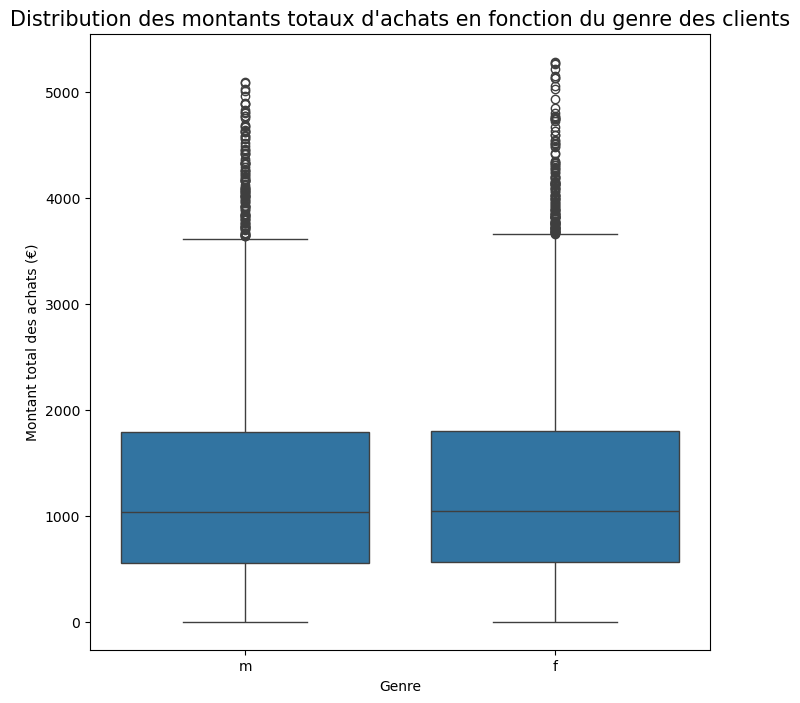

In [93]:
# Lien entre le genre d'un client et le montant total des achats

## Choix du test : test de Student
    ## - 2 variables mixtes : genre (qualitative) et montant des achats (quantitative)
    ## - 2 groupes indépendants : femmes et hommes
    ## - distribution des données non normale mais plus de 20 individus dans chaque échantillon (groupes)
    ## - variances des 2 groupes égales 


## Création du dataframe contenant les données à analyser 

df_montants = df_stats.loc[:, ["client_id", "sex", "price"]]                       # récupère les colonnes utiles pour cette analyse dans un nouveau dataframe
df_montants = df_montants.groupby(["client_id","sex"]).sum().reset_index()         # agrégation des données pour obtenir le montant total des achats de chaque client
df_montants.rename(columns = {"price" : "panier_total"}, inplace = True)           # renomme la colonne "price" en panier_total pour plus de clarté de l'information observée

genres = df_montants["sex"].unique().tolist()                                      # récupère les valeurs de genre des clients ("f" et "m")


## Test de Normalité de la distibution des données dans les 2 groupes : test de Jarque-Bera (n > 2000 dans les 2 groupes)
    ## H0 = les données suivent une distribution normale (hypothèse nulle)
    ## H1 = les données ne suivent pas une distribution normale 
    ## seuil d'erreur = 5% (0.05)

for genre in  genres :
    montants = df_montants.loc[df_montants["sex"] == genre, "panier_total"]        # récupère tous les montants totaux d'achats pour les clients en fonction du genre
    n_montants = montants.count()                                                  # compte le nombre de valeurs de montants totaux d'achats parmi les valeurs du groupe
    from scipy.stats import jarque_bera
    jb_stat_montants, p_value_montants = jarque_bera(montants)                     # applique le test de Jarque-Bera sur les montants totaux de chaque groupe pour tester la normalité de la distribution des données
    print(f"Test de Normalité de la distribution des données :")
    print(f"Il y a {n_montants} observations (valeurs) dans le groupe '{genre}'.")
    print(f"Résultat du test : {jb_stat_montants : .2f}")                          # stat = mesure l'écart des données à la normalité (plus la valeur est haute, plus la distribution s'éloigne de la normalité)
    print(f"Valeur p : {p_value_montants  : .3f}")                                 # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
    if p_value_montants < 0.05 :                                                   # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
        print("Rejet de H0 : les données du montant total des achats clients ne suivent pas une distribution normale.")
    else :
        print("H0 acceptée : les données du montant total des achats clients suivent une distribution normale.") 
    print(f"\n")                                                                   # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité


## Test de l'égalité des variances : test de Levene (distributions des données non normales)
    ## H0 = les variances des 2 groupes sont égales
    ## H1 = les variances des 2 groupes ne sont pas égales
    ## seuil d'erreur = 5% (0.05)

montants_F = df_montants.loc[df_montants["sex"] == "f", "panier_total"]            # récupère tous les montants totaux d'achats pour les clients en fonction du genre
montants_H = df_montants.loc[df_montants["sex"] == "m", "panier_total"]

stats_montants, p_value_var_montants = stats.levene(montants_F, montants_H)        # applique le test de Levene sur les variances des montants totaux de chaque groupe pour tester l'égalité des variances
print(f"Test de l'égalité des variances :")
print(f"Ratio F : {stats_montants : .2f}")
print(f"Valeur p : {p_value_var_montants : .3f}")                                  # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
if p_value_var_montants < 0.05 :                                                   # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
    print("Rejet de H0 : les variances des 2 groupes ne sont pas égales.")
else :
    print("H0 acceptée : les variances des 2 groupes sont égales.") 
print(f"\n")                                                                       # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité


## Test de Student
    ## H0 = les moyennes des 2 groupes sont égales (ou la différence observée est non significative)
    ## H1 = les moyennes des 2 groupes ne sont pas égales (ou la différence observée est significative)
    ## seuil d'erreur = 5% (0.05)

T_test_montants, p_value_T_test_montants = stats.ttest_ind(montants_F, montants_H) #  applique le test de Student sur les données des montants totaux de chaque groupe pour tester l'égalité des moyennes
print(f"Test de Student :")
print(f"Résultat du test : {T_test_montants : .2f}")
print(f"Valeur p : {p_value_T_test_montants : .3f}")                               # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
if p_value_T_test_montants < 0.05 :                                                # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
    print("Rejet de H0 : la différence observée entre les 2 groupes est significative.")
else :
    print("H0 acceptée : il n'y a pas de différence entre les 2 groupes, ou la différence observée n'est pas significative.") 
print(f"\n")                                                                       # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité


## Graphique bivarié : boîte à moustache

plt.figure(figsize = (8, 8))                                                                               # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
boxplot_montants = sns.boxplot(data = df_montants, x = "sex", y = "panier_total")                          # création des boites à moustache représentant la distribution des montants totaux d'achats en fonction du genre des clients
plt.title("Distribution des montants totaux d'achats en fonction du genre des clients", fontsize = 15)     # ajoute un titre au graphique
plt.xlabel("Genre")
plt.ylabel("Montant total des achats (€)")
plt.show()


Test de Normalité de la distribution des données :
Il y a 8213 observations (valeurs) dans le groupe 'm'.
Résultat du test :  7766.46
Valeur p :  0.000
Rejet de H0 : les données des fréquences d'achat des clients ne suivent pas une distribution normale.


Test de Normalité de la distribution des données :
Il y a 8924 observations (valeurs) dans le groupe 'f'.
Résultat du test :  8562.03
Valeur p :  0.000
Rejet de H0 : les données des fréquences d'achat des clients ne suivent pas une distribution normale.


Test de l'égalité des variances :
Ratio F :  0.10
Valeur p :  0.750
H0 acceptée : les variances des 2 groupes sont égales.


Test de Student :
Résultat du test : -0.07
Valeur p :  0.942
H0 acceptée : il n'y a pas de différence entre les 2 groupes, ou la différence observée n'est pas significative.




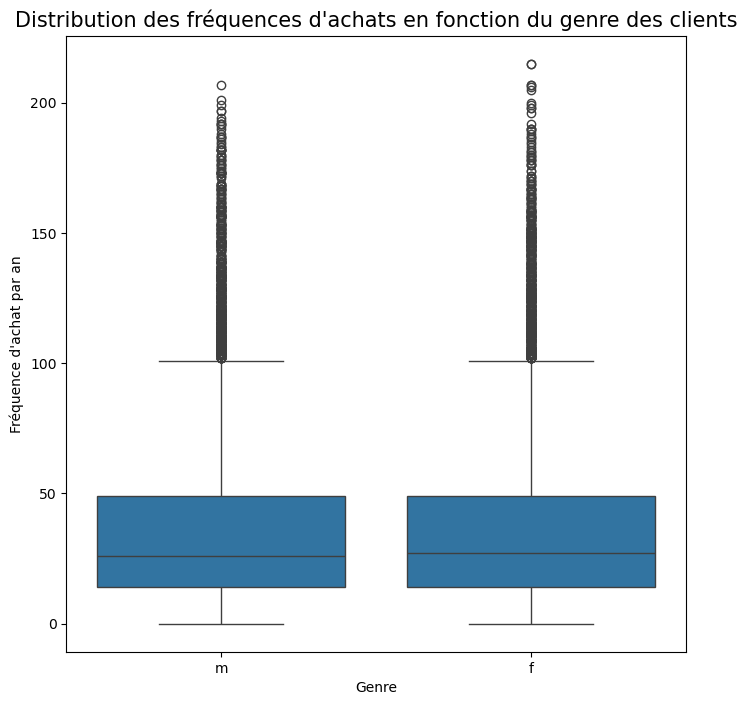

In [94]:
# Lien entre le genre d'un client et la fréquence des achats

## Choix du test : test de Student
    ## - 2 variables mixtes : genre (qualitative) et fréquence d'achat (quantitative)
    ## - 2 groupes indépendants : femmes et hommes
    ## - distribution des données non normale mais plus de 20 individus dans chaque échantillon (groupes)
    ## - variances des 2 groupes égales 


## Création du dataframe contenant les données à analyser 

df_frequences = df_stats.loc[:, ["client_id", "sex", "date", "session_id"]]                                 # récupère les colonnes utiles pour cette analyse dans un nouveau dataframe
start_date = df_frequences["date"].min()                                                                    # récupère la date de départ pour le calcul des périodes de 1 an 
                                                                                                            # => les données ne commencent pas au 01/01/2021 et ne finissent pas au 31/12/2022, nous ne pouvons donc pas utiliser les années calendaires classiques         
df_frequences["date"] = (df_frequences["date"] - start_date).dt.days                                        # compte le nombre de jours entre la date selectionnée et la date de départ
df_frequences["date"] = df_frequences["date"].apply(lambda x : "2021-2022" if x <= 365 else "2022-2023")    # affiche le nom de la période de 1 an correspondante en fonction du nombre de jours écoulés depuis la date de départ (base 365 jours = 1 an)
df_frequences = df_frequences.groupby(["client_id", "sex", "date"]).count().reset_index()                   # agrégation des données pour obtenir nombre de transactions effectuées par an par chaque client
df_frequences.rename(columns = {"session_id" : "freq_achat_an"}, inplace = True)                            # renomme la colonne "session_id" en "fréquence d'achat par an" (ou "nombre moyen de transactions par an") pour plus de clarté de l'information observée
                                                                                                            # => exemple : 6 x / an = environ tous les 2 mois

genres = df_frequences["sex"].unique().tolist()                                                             # récupère les valeurs de genre des clients ("f" et "m")


## Test de Normalité de la distibution des données dans les 2 groupes : test de Jarque-Bera (n > 2000 dans les 2 groupes)
    ## H0 = les données suivent une distribution normale (hypothèse nulle)
    ## H1 = les données ne suivent pas une distribution normale 
    ## seuil d'erreur = 5% (0.05)

for genre in  genres :
    frequences = df_frequences.loc[df_frequences["sex"] == genre, "freq_achat_an"]                         # récupère toutes les fréquences d'achats pour les clients en fonction du genre
    n_frequences = frequences.count()                                                                      # compte le nombre de valeurs de frequences d'achat parmi les valeurs du groupe
    from scipy.stats import jarque_bera
    jb_stat_frequences, p_value_frequences = jarque_bera(frequences)                                       # applique le test de Jarque-Bera sur les frequences de chaque groupe pour tester la normalité de la distribution des données
    print(f"Test de Normalité de la distribution des données :")
    print(f"Il y a {n_frequences} observations (valeurs) dans le groupe '{genre}'.")
    print(f"Résultat du test : {jb_stat_frequences : .2f}")                                                # stat = mesure l'écart des données à la normalité (plus la valeur est haute, plus la distribution s'éloigne de la normalité)
    print(f"Valeur p : {p_value_frequences : .3f}")                                                        # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
    if p_value_frequences < 0.05 :                                                                         # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
        print("Rejet de H0 : les données des fréquences d'achat des clients ne suivent pas une distribution normale.")
    else :
        print("H0 acceptée : les données des fréquences d'achat des clients suivent une distribution normale.") 
    print(f"\n")                                                                                           # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité


## Test de l'égalité des variances : test de Levene (distributions des données non normales)
    ## H0 = les variances des 2 groupes sont égales
    ## H1 = les variances des 2 groupes ne sont pas égales
    ## seuil d'erreur = 5% (0.05)

frequences_F = df_frequences.loc[df_frequences["sex"] == "f", "freq_achat_an"]                            # récupère toutes les fréquences d'achats pour les clients en fonction du genre
frequences_H = df_frequences.loc[df_frequences["sex"] == "m", "freq_achat_an"]

stats_frequences, p_value_var_frequences = stats.levene(frequences_F, frequences_H)                       # applique le test de Levene sur les variances des fréquences de chaque groupe pour tester l'égalité des variances
print(f"Test de l'égalité des variances :")
print(f"Ratio F : {stats_frequences : .2f}")
print(f"Valeur p : {p_value_var_frequences : .3f}")                                                       # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
if p_value_var_frequences < 0.05 :                                                                        # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
    print("Rejet de H0 : les variances des 2 groupes ne sont pas égales.")
else :
    print("H0 acceptée : les variances des 2 groupes sont égales.") 
print(f"\n")                                                                                              # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité


## Test de Student
    ## H0 = les moyennes des 2 groupes sont égales (ou la différence observée est non significative)
    ## H1 = les moyennes des 2 groupes ne sont pas égales (ou la différence observée est significative)
    ## seuil d'erreur = 5% (0.05)

T_test_frequences, p_value_T_test_frequences = stats.ttest_ind(frequences_F, frequences_H)                # applique le test de Student sur les données des fréquences de chaque groupe pour tester l'égalité des moyennes
print(f"Test de Student :")
print(f"Résultat du test : {T_test_frequences : .2f}")
print(f"Valeur p : {p_value_T_test_frequences : .3f}")                                                    # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
if p_value_T_test_frequences < 0.05 :                                                                     # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
    print("Rejet de H0 : la différence observée entre les 2 groupes est significative.")
else :
    print("H0 acceptée : il n'y a pas de différence entre les 2 groupes, ou la différence observée n'est pas significative.") 
print(f"\n")                                                                                              # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité


## Graphique bivarié : boîte à moustache

plt.figure(figsize = (8, 8))                                                                              # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
boxplot_frequences = sns.boxplot(data = df_frequences, x = "sex", y = "freq_achat_an")                    # création des boites à moustache représentant la distribution des fréquences d'achat en fonction du genre des clients
plt.title("Distribution des fréquences d'achats en fonction du genre des clients", fontsize = 15)         # ajoute un titre au graphique
plt.xlabel("Genre")
plt.ylabel("Fréquence d'achat par an")
plt.show()


Test de Normalité de la distribution des données :
Il y a 4118 observations (valeurs) dans le groupe 'm'.
Résultat du test :  6515.74
Valeur p :  0.000
Rejet de H0 : les données des paniers moyens des clients ne suivent pas une distribution normale.


Test de Normalité de la distribution des données :
Il y a 4478 observations (valeurs) dans le groupe 'f'.
Résultat du test :  10145.95
Valeur p :  0.000
Rejet de H0 : les données des paniers moyens des clients ne suivent pas une distribution normale.


Test de l'égalité des variances :
Ratio F :  0.17
Valeur p :  0.684
H0 acceptée : les variances des 2 groupes sont égales.


Test de Student :
Résultat du test : -0.96
Valeur p :  0.336
H0 acceptée : il n'y a pas de différence entre les 2 groupes, ou la différence observée n'est pas significative.




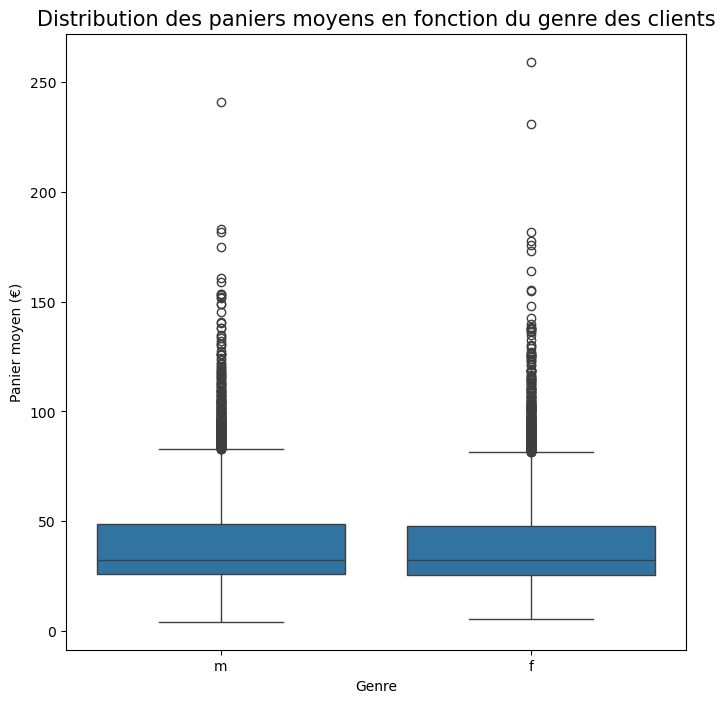

In [95]:
# Lien entre le genre d'un client et la taille du panier moyen

## Choix du test : test de Student
    ## - 2 variables mixtes : genre (qualitative) et taille du panier moyen (quantitative)
    ## - 2 groupes indépendants : femmes et hommes
    ## - distribution des données non normale mais plus de 20 individus dans chaque échantillon (groupes)
    ## - variances des 2 groupes égales 


## Création du dataframe contenant les données à analyser 

df_panier = df_stats.loc[:, ["client_id", "sex", "session_id", "price"]]                      # récupère les colonnes utiles pour cette analyse dans un nouveau dataframe
df_panier = df_panier.groupby(["client_id", "sex", "session_id"]).sum().reset_index()         # agrégation des données pour obtenir le montant total des achats de chaque client par session d'achat
df_panier.drop(columns = "session_id", inplace = True)                                        # suppression de la colonne "session_id" car nous n'en avons plus besoin pour cette analyse
df_panier = df_panier.groupby(["client_id", "sex"]).mean().round(2).reset_index()             # agrégation des données pour obtenir la taille du panier moyen de chaque client
df_panier.rename(columns = {"price" : "panier_moyen"}, inplace = True)                        # renomme la colonne "price" en panier_moyen pour plus de clarté de l'information observée

genres = df_panier["sex"].unique().tolist()                                                   # récupère les valeurs de genre des clients ("f" et "m")


## Test de Normalité de la distibution des données dans les 2 groupes : test de Jarque-Bera (n > 2000 dans les 2 groupes)
    ## H0 = les données suivent une distribution normale (hypothèse nulle)
    ## H1 = les données ne suivent pas une distribution normale 
    ## seuil d'erreur = 5% (0.05)

for genre in  genres :
    paniers = df_panier.loc[df_panier["sex"] == genre, "panier_moyen"]                        # récupère tous les paniers moyens pour les clients en fonction du genre
    n_paniers = paniers.count()                                                               # compte le nombre de valeurs de paniers moyens parmi les valeurs du groupe
    from scipy.stats import jarque_bera
    jb_stat_paniers, p_value_paniers = jarque_bera(paniers)                                   # applique le test de Jarque-Bera sur les paniers moyens de chaque groupe pour tester la normalité de la distribution des données
    print(f"Test de Normalité de la distribution des données :")
    print(f"Il y a {n_paniers} observations (valeurs) dans le groupe '{genre}'.")
    print(f"Résultat du test : {jb_stat_paniers : .2f}")                                      # stat = mesure l'écart des données à la normalité (plus la valeur est haute, plus la distribution s'éloigne de la normalité)
    print(f"Valeur p : {p_value_paniers : .3f}")                                              # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
    if p_value_paniers < 0.05 :                                                               # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
        print("Rejet de H0 : les données des paniers moyens des clients ne suivent pas une distribution normale.")
    else :
        print("H0 acceptée : les données des paniers moyens des clients suivent une distribution normale.") 
    print(f"\n")                                                                              # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité


## Test de l'égalité des variances : test de Levene (distributions des données non normales)
    ## H0 = les variances des 2 groupes sont égales
    ## H1 = les variances des 2 groupes ne sont pas égales
    ## seuil d'erreur = 5% (0.05)

paniers_F = df_panier.loc[df_panier["sex"] == "f", "panier_moyen"]                           # récupère tous les paniers moyens pour les clients en fonction du genre
paniers_H = df_panier.loc[df_panier["sex"] == "m", "panier_moyen"]

stats_paniers, p_value_var_paniers = stats.levene(paniers_F, paniers_H)                      # applique le test de Levene sur les variances des paniers moyens de chaque groupe pour tester l'égalité des variances
print(f"Test de l'égalité des variances :")
print(f"Ratio F : {stats_paniers : .2f}")
print(f"Valeur p : {p_value_var_paniers : .3f}")                                             # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
if p_value_var_paniers < 0.05 :                                                              # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
    print("Rejet de H0 : les variances des 2 groupes ne sont pas égales.")
else :
    print("H0 acceptée : les variances des 2 groupes sont égales.") 
print(f"\n")                                                                                 # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité


## Test de Student
    ## H0 = les moyennes des 2 groupes sont égales (ou la différence observée est non significative)
    ## H1 = les moyennes des 2 groupes ne sont pas égales (ou la différence observée est significative)
    ## seuil d'erreur = 5% (0.05)

T_test_paniers, p_value_T_test_paniers = stats.ttest_ind(paniers_F, paniers_H)                # applique le test de Student sur les données des paniers moyens de chaque groupe pour tester l'égalité des moyennes
print(f"Test de Student :")
print(f"Résultat du test : {T_test_paniers : .2f}")
print(f"Valeur p : {p_value_T_test_paniers : .3f}")                                           # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
if p_value_T_test_paniers < 0.05 :                                                            # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
    print("Rejet de H0 : la différence observée entre les 2 groupes est significative.")
else :
    print("H0 acceptée : il n'y a pas de différence entre les 2 groupes, ou la différence observée n'est pas significative.") 
print(f"\n")                                                                                  # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité


## Graphique bivarié : boîte à moustache

plt.figure(figsize = (8, 8))                                                                  # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
boxplot_paniers = sns.boxplot(data = df_panier, x = "sex", y = "panier_moyen")                # création des boites à moustache représentant la distribution des paniers moyens en fonction du genre des clients
plt.title("Distribution des paniers moyens en fonction du genre des clients", fontsize = 15)  # ajoute un titre au graphique
plt.xlabel("Genre")
plt.ylabel("Panier moyen (€)")
plt.show()


Test de Normalité de la distribution des données :
Il y a 4128 observations (valeurs) dans le groupe 'm'.
Résultat du test :  3824.34
Valeur p :  0.000
Rejet de H0 : les données du nombre de transactions des clients ne suivent pas une distribution normale.


Test de Normalité de la distribution des données :
Il y a 4489 observations (valeurs) dans le groupe 'f'.
Résultat du test :  4163.01
Valeur p :  0.000
Rejet de H0 : les données du nombre de transactions des clients ne suivent pas une distribution normale.


Test de l'égalité des variances :
Ratio F :  0.04
Valeur p :  0.846
H0 acceptée : les variances des 2 groupes sont égales.


Test de Student :
Résultat du test : -0.09
Valeur p :  0.926
H0 acceptée : il n'y a pas de différence entre les 2 groupes, ou la différence observée n'est pas significative.




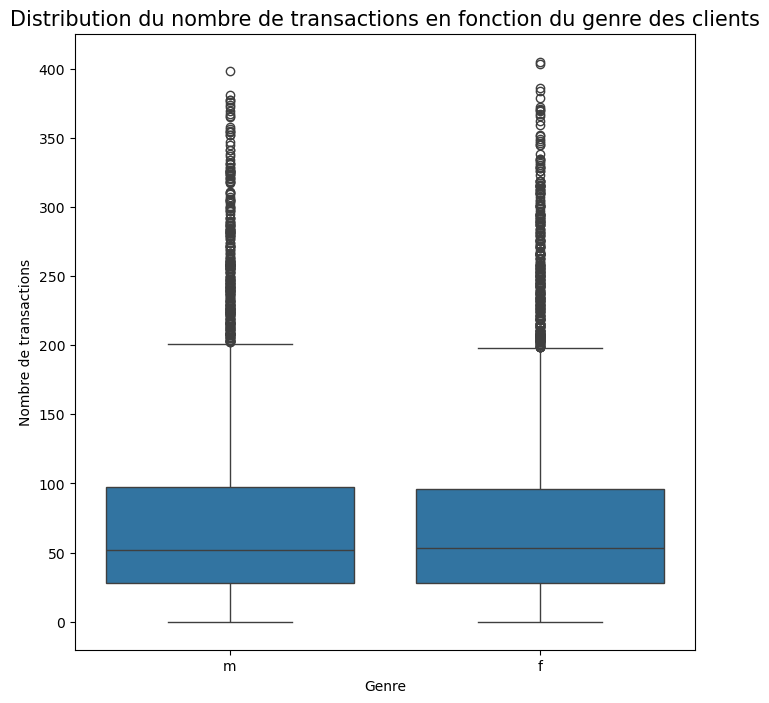

In [96]:
# Lien entre le genre d'un client et le nombre de transactions

## Choix du test : test de Student
    ## - 2 variables mixtes : genre (qualitative) et nombre de transactions (quantitative)
    ## - 2 groupes indépendants : femmes et hommes
    ## - distribution des données non normale mais plus de 20 individus dans chaque échantillon (groupes)
    ## - variances des 2 groupes égales 


## Création du dataframe contenant les données à analyser 

df_trans_stats = df_stats.loc[:, ["client_id", "sex", "session_id"]]                      # récupère les colonnes utiles pour cette analyse dans un nouveau dataframe
df_trans_stats = df_trans_stats.groupby(["client_id", "sex"]).count().reset_index()       # agrégation des données pour obtenir le nombre total de transactions de chaque client
df_trans_stats.rename(columns = {"session_id" : "nb_trans"}, inplace = True)              # renomme la colonne "session_id" en nombre de transactions pour plus de clarté de l'information observée

genres = df_trans_stats["sex"].unique().tolist()                                          # récupère les valeurs de genre des clients ("f" et "m")


## Test de Normalité de la distibution des données dans les 2 groupes : test de Jarque-Bera (n > 2000 dans les 2 groupes)
    ## H0 = les données suivent une distribution normale (hypothèse nulle)
    ## H1 = les données ne suivent pas une distribution normale 
    ## seuil d'erreur = 5% (0.05)

for genre in  genres :
    transactions = df_trans_stats.loc[df_trans_stats["sex"] == genre, "nb_trans"]          # récupère toutes les valeurs de transactions pour les clients en fonction du genre
    n_trans = transactions.count()                                                         # compte le nombre de valeurs de transactions parmi les valeurs du groupe
    from scipy.stats import jarque_bera
    jb_stat_trans, p_value_trans = jarque_bera(transactions)                               # applique le test de Jarque-Bera sur les transactions de chaque groupe pour tester la normalité de la distribution des données
    print(f"Test de Normalité de la distribution des données :")
    print(f"Il y a {n_trans} observations (valeurs) dans le groupe '{genre}'.")
    print(f"Résultat du test : {jb_stat_trans : .2f}")                                     # stat = mesure l'écart des données à la normalité (plus la valeur est haute, plus la distribution s'éloigne de la normalité)
    print(f"Valeur p : {p_value_trans : .3f}")                                             # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
    if p_value_trans < 0.05 :                                                              # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
        print("Rejet de H0 : les données du nombre de transactions des clients ne suivent pas une distribution normale.")
    else :
        print("H0 acceptée : les données du nombre de transactions des clients suivent une distribution normale.") 
    print(f"\n")                                                                           # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité


## Test de l'égalité des variances : test de Levene (distributions des données non normales)
    ## H0 = les variances des 2 groupes sont égales
    ## H1 = les variances des 2 groupes ne sont pas égales
    ## seuil d'erreur = 5% (0.05)

trans_F = df_trans_stats.loc[df_trans_stats["sex"] == "f", "nb_trans"]                      # récupère toutes lestransactions pour les clients en fonction du genre
trans_H = df_trans_stats.loc[df_trans_stats["sex"] == "m", "nb_trans"]

stats_trans, p_value_var_trans = stats.levene(trans_F, trans_H)                             # applique le test de Levene sur les variances des transactions de chaque groupe pour tester l'égalité des variances
print(f"Test de l'égalité des variances :")
print(f"Ratio F : {stats_trans : .2f}")
print(f"Valeur p : {p_value_var_trans : .3f}")                                              # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
if p_value_var_trans < 0.05 :                                                               # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
    print("Rejet de H0 : les variances des 2 groupes ne sont pas égales.")
else :
    print("H0 acceptée : les variances des 2 groupes sont égales.") 
print(f"\n")                                                                                # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité


## Test de Student
    ## H0 = les moyennes des 2 groupes sont égales (ou la différence observée est non significative)
    ## H1 = les moyennes des 2 groupes ne sont pas égales (ou la différence observée est significative)
    ## seuil d'erreur = 5% (0.05)

T_test_trans, p_value_T_test_trans = stats.ttest_ind(trans_F, trans_H)                      # applique le test de Student sur les données des transactions de chaque groupe pour tester l'égalité des moyennes
print(f"Test de Student :")
print(f"Résultat du test : {T_test_trans : .2f}")
print(f"Valeur p : {p_value_T_test_trans : .3f}")                                           # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
if p_value_T_test_trans < 0.05 :                                                            # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
    print("Rejet de H0 : la différence observée entre les 2 groupes est significative.")
else :
    print("H0 acceptée : il n'y a pas de différence entre les 2 groupes, ou la différence observée n'est pas significative.") 
print(f"\n")                                                                                # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité


## Graphique bivarié : boîte à moustache
  
plt.figure(figsize = (8, 8))                                                                # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
boxplot_trans = sns.boxplot(data = df_trans_stats, x = "sex", y = "nb_trans")               # création des boites à moustache représentant la distribution du nombre de transactions en fonction du genre des clients
plt.title("Distribution du nombre de transactions en fonction du genre des clients", fontsize = 15)  # ajoute un titre au graphique
plt.xlabel("Genre")
plt.ylabel("Nombre de transactions")
plt.show()


<div style="border: 1px solid RGB(198,131,70);" >
<h3 style="margin: auto; padding: 20px; color: RGB(214,181,136); ">6.2 - Selon l'âge des clients</h3>
</div>

Test de Normalité de la distribution des données :
Il y a 387281 observations (valeurs) dans le groupe '0'.
Résultat du test :  107876.28
Valeur p :  0.000
Rejet de H0 : les données des âges pour chaque catégorie ne suivent pas une distribution normale.


Test de Normalité de la distribution des données :
Il y a 220605 observations (valeurs) dans le groupe '1'.
Résultat du test :  3708.70
Valeur p :  0.000
Rejet de H0 : les données des âges pour chaque catégorie ne suivent pas une distribution normale.


Test de Normalité de la distribution des données :
Il y a 32848 observations (valeurs) dans le groupe '2'.
Résultat du test :  189315.40
Valeur p :  0.000
Rejet de H0 : les données des âges pour chaque catégorie ne suivent pas une distribution normale.


Test de l'égalité des variances :
Ratio F :  24746.71
Valeur p :  0.000
Rejet de H0 : les variances des groupes ne sont pas égales.


Test de Kruskal-Wallis :
Résultat du test :  71283.58
Valeur p :  0.000
Rejet de H0 : il existe au mo

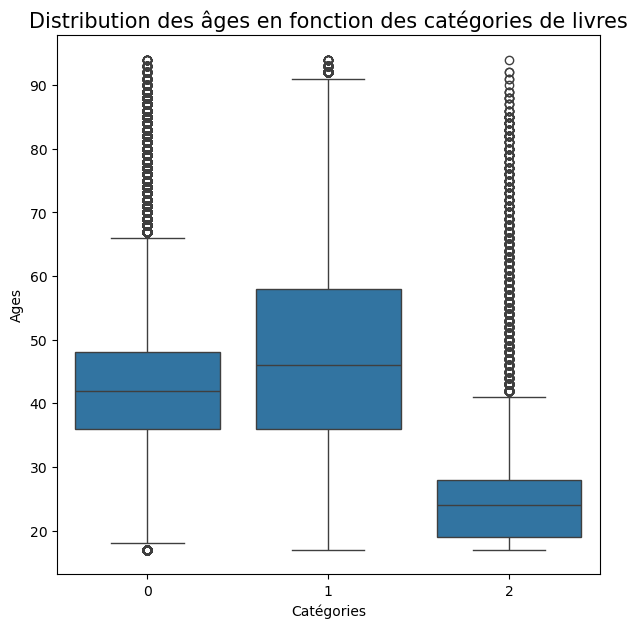

In [97]:
# Lien entre l'âge d'un client et la catégorie des livres achetés

## Choix du test : Kruskal-Wallis
    ## - 2 variables mixtes : âge (quantitative) et catégories (qualitative)
    ## - 3 groupes indépendants : 3 catégories
    ## - variances des échantillons non égales
    ## - Distribution non normale des résidus


## Création du dataframe contenant les données à analyser

df_categ_2 = df_stats.loc[:, ["age", "categ"]].dropna()                                     # récupère les colonnes utiles pour cette analyse dans un nouveau dataframe

categories = df_categ_2["categ"].unique().tolist()                                          # récupère les valeurs uniques des catégories (0 ,1, 2)


## Test de Normalité de la distibution des données dans les 2 groupes : test de Jarque-Bera (n > 2000 dans les 2 groupes)
    ## H0 = les données suivent une distribution normale (hypothèse nulle)
    ## H1 = les données ne suivent pas une distribution normale 
    ## seuil d'erreur = 5% (0.05)

for cat in  categories :
    ages = df_categ_2.loc[df_categ_2["categ"] == cat, "age"]                               # récupère toutes les valeurs d'âges présents dans chaque catégorie
    n_ages = ages.count()                                                                  # compte le nombre de valeurs d'âges trouvés parmi les valeurs du groupe
    from scipy.stats import jarque_bera
    jb_stat_age, p_value_age = jarque_bera(ages)                                           # applique le test de Jarque-Bera sur les âges de chaque groupe pour tester la normalité de la distribution des données
    print(f"Test de Normalité de la distribution des données :")
    print(f"Il y a {n_ages} observations (valeurs) dans le groupe '{cat}'.")
    print(f"Résultat du test : {jb_stat_age : .2f}")                                       # stat = mesure l'écart des données à la normalité (plus la valeur est haute, plus la distribution s'éloigne de la normalité)
    print(f"Valeur p : {p_value_age : .3f}")                                               # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
    if p_value_age < 0.05 :                                                                # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
        print("Rejet de H0 : les données des âges pour chaque catégorie ne suivent pas une distribution normale.")
    else :
        print("H0 acceptée : les données des âges pour chaque catégorie suivent une distribution normale.") 
    print(f"\n")                                                                           # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité


## Test de l'égalité des variances : test de Levene (distributions des données non normales)
    ## H0 = les variances des 2 groupes sont égales
    ## H1 = les variances des 2 groupes ne sont pas égales
    ## seuil d'erreur = 5% (0.05)

ages_cat_0 = df_categ_2.loc[df_categ_2["categ"] == 0, "age"]                               # récupère tous les âges pour chaque catégorie de livres
ages_cat_1 = df_categ_2.loc[df_categ_2["categ"] == 1, "age"]
ages_cat_2 = df_categ_2.loc[df_categ_2["categ"] == 2, "age"]

stats_ages_cat, p_value_var_ages_cat = stats.levene(ages_cat_0, ages_cat_1, ages_cat_2)    # applique le test de Levene sur les variances des âges de chaque groupe pour tester l'égalité des variances
print(f"Test de l'égalité des variances :")
print(f"Ratio F : {stats_ages_cat : .2f}")
print(f"Valeur p : {p_value_var_ages_cat : .3f}")                                          # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
if p_value_var_ages_cat < 0.05 :                                                           # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
    print("Rejet de H0 : les variances des groupes ne sont pas égales.")
else :
    print("H0 acceptée : les variances des groupes sont égales.") 
print(f"\n")                                                                               # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité          


## Test de Kruskal-Wallis
    ## H0 : les médianes des groupes sont égales
    ## H1 : les médianes des groupes ne sont pas égales pour au moins 1 groupe
    ## seuil d'erreur = 5% (0.05)

from scipy.stats import kruskal
stat_kw_ages, p_value_kw_ages = kruskal(ages_cat_0, ages_cat_1, ages_cat_2)                # applique le test de Kruskal-Wallis sur les données des âges de chaque groupe pour tester l'égalité des médianes
print(f"Test de Kruskal-Wallis :")
print(f"Résultat du test : {stat_kw_ages : .2f}")
print(f"Valeur p : {p_value_kw_ages : .3f}")                                               # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
if p_value_kw_ages < 0.05 :                                                                # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
    print("Rejet de H0 : il existe au moins une différence significative entre les groupes.")
else:
    print("H0 acceptée : il n'y a pas de différence entre les 2 groupes, ou la différence observée n'est pas significative.")
print(f"\n")                                                                               # permet de sauter 1 ligne entre les 2 affichages pour plus de lisibilité


## Graphique bivarié : boîte à moustache

plt.figure(figsize = (7, 7))                                                               # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
boxplot_âges = sns.boxplot(data = df_categ_2, x = "categ", y = "age")                      # création des boites à moustache représentant la distribution des âges en fonction de la catégorie des livresz
plt.title("Distribution des âges en fonction des catégories de livres", fontsize = 15)     # ajoute un titre au graphique
plt.xlabel("Catégories")
plt.ylabel("Ages")
plt.show()


Test de Normalité de la distribution des données :
Il y a 320 observations (valeurs) dans le groupe '66'.
Résultat du test :  0.13
Valeur p :  0.000
Rejet de H0 : les données du montant total des achats clients ne suivent pas une distribution normale.


Test de Normalité de la distribution des données :
Il y a 309 observations (valeurs) dans le groupe '67'.
Résultat du test :  0.19
Valeur p :  0.000
Rejet de H0 : les données du montant total des achats clients ne suivent pas une distribution normale.


Test de Normalité de la distribution des données :
Il y a 250 observations (valeurs) dans le groupe '68'.
Résultat du test :  0.15
Valeur p :  0.000
Rejet de H0 : les données du montant total des achats clients ne suivent pas une distribution normale.


Test de Normalité de la distribution des données :
Il y a 344 observations (valeurs) dans le groupe '65'.
Résultat du test :  0.15
Valeur p :  0.000
Rejet de H0 : les données du montant total des achats clients ne suivent pas une distribu

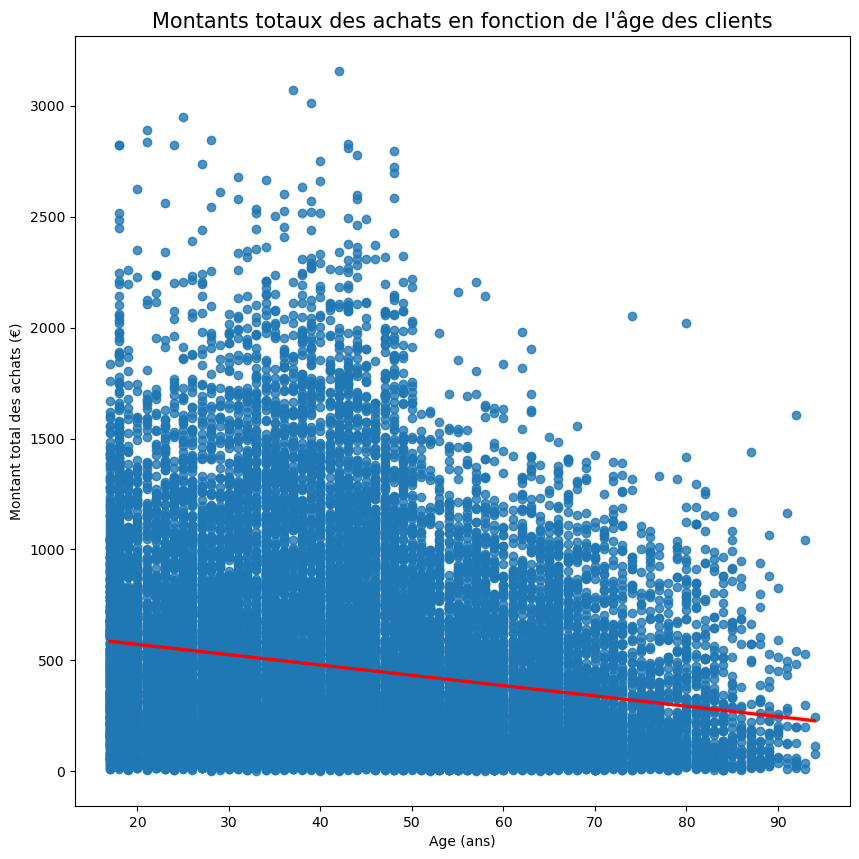

In [98]:
## Lien entre l'âge d'un client et le montant total des achats

## Choix du test : test de Spearman
    ## - 2 variables quantitatives : âge et montant des achats
    ## - distribution des données non normale dans la majorité des groupes
    ## - moins de 20 individus dans certains échantillons


## Création du dataframe contenant les données à analyser 

df_montants_2 = df_stats.loc[:, ["client_id", "age", "price"]]                                                   # récupère les colonnes utiles pour cette analyse dans un nouveau dataframe
df_montants_2 = df_montants_2.groupby(["client_id","age"]).sum().reset_index()                                   # agrégation des données pour obtenir le montant total des achats de chaque client
df_montants_2.rename(columns = {"price" : "panier_total"}, inplace = True)                                       # renomme la colonne "price" en panier_total pour plus de clarté de l'information observée

ages = df_montants_2["age"].unique().tolist()                                                                    # récupère les valeurs de ages des clients (exemple : 17, 25, 39, etc.)


## Test de Normalité de la distibution des données dans les groupes : test de Kolmogorov-Smirnov (50 < n < 2000 dans les groupes)
    ## H0 = les données suivent une distribution normale (hypothèse nulle)
    ## H1 = les données ne suivent pas une distribution normale 
    ## seuil d'erreur = 5% (0.05)

for age in  ages :
    montants = df_montants_2.loc[df_montants_2["age"] == age, "panier_total"]                                    # récupère tous les montants totaux d'achats pour les clients en fonction de leur age
    n_montants = montants.count()                                                                                # compte le nombre de valeurs de montants totaux d'achats parmi les valeurs du groupe
    from scipy.stats import kstest, norm
    mu, std = norm.fit(montants)                                                                                 # calcule la moyenne et l'écart-type des montants totaux d'achats de chaque groupe d'âge
    ks_stat_montants, p_value_montants = kstest(montants, "norm", args = (mu, std))                              # applique le test de Kolmogorov-Smirnov sur les montants totaux de chaque groupe pour tester la normalité de la distribution des données 
                                                                                                                 # => "norm" permet de comparer la distribution du groupe à une distribution normale
    print(f"Test de Normalité de la distribution des données :")
    print(f"Il y a {n_montants} observations (valeurs) dans le groupe '{age}'.")
    print(f"Résultat du test : {ks_stat_montants : .2f}")                                                        # stat = mesure l'écart des données à la normalité (plus la valeur est haute, plus la distribution s'éloigne de la normalité)
    print(f"Valeur p : {p_value_montants : .3f}")                                                                # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
    if p_value_montants < 0.05 :                                                                                 # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
        print("Rejet de H0 : les données du montant total des achats clients ne suivent pas une distribution normale.")
    else :
        print("H0 acceptée : les données du montant total des achats clients suivent une distribution normale.") 
    print(f"\n")                                                                                                 # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité


## Test de Spearman
    ## H0 = les 2 variables sont indépendantes (= 0)
    ## H1 = Les 2 variables ne sont pas indépendantes (proche de +/- 1)
    ## seuil d'erreur = 5% (0.05)

from scipy.stats import spearmanr
corr_montants, p_value_spear_montants = spearmanr(df_montants_2["age"], df_montants_2["panier_total"])           # applique le test de Spearman sur les données des montants totaux de chaque groupe pour tester l'indépendance des variables
print(f"Test de Spearman :")
print(f"Résultat du test : {corr_montants : .2f}")
print(f"Valeur p : {p_value_spear_montants : .3f}")                                                              # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
if p_value_spear_montants < 0.05 :                                                                               # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
    print("Rejet de H0 : il existe une corrélation significative entre les 2 variables (même faible).")
else :
    print("H0 acceptée : les 2 variables sont indépendantes.") 
print(f"\n")                                                                                                     # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité


## Graphique bivarié : nuage de points

plt.figure(figsize = (10, 10))                                                                                   # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
nuage_montants = sns.regplot(data = df_montants_2, x = "age", y = "panier_total", line_kws={"color": "red"}  )   # création du nuage de point représentant les montants totaux des achats en fonction de l'âge des clients
plt.title("Montants totaux des achats en fonction de l'âge des clients", fontsize = 15)                          # ajoute un titre au graphique
plt.ylabel("Montant total des achats (€)")
plt.xlabel("Age (ans)")
plt.show()


Test de Normalité de la distribution des données :
Il y a 455 observations (valeurs) dans le groupe '66'.
Résultat du test :  0.19
Valeur p :  0.000
Rejet de H0 : les données des frequences d'achat des clients ne suivent pas une distribution normale.


Test de Normalité de la distribution des données :
Il y a 381 observations (valeurs) dans le groupe '67'.
Résultat du test :  0.19
Valeur p :  0.000
Rejet de H0 : les données des frequences d'achat des clients ne suivent pas une distribution normale.


Test de Normalité de la distribution des données :
Il y a 325 observations (valeurs) dans le groupe '68'.
Résultat du test :  0.18
Valeur p :  0.000
Rejet de H0 : les données des frequences d'achat des clients ne suivent pas une distribution normale.


Test de Normalité de la distribution des données :
Il y a 433 observations (valeurs) dans le groupe '65'.
Résultat du test :  0.18
Valeur p :  0.000
Rejet de H0 : les données des frequences d'achat des clients ne suivent pas une distribution

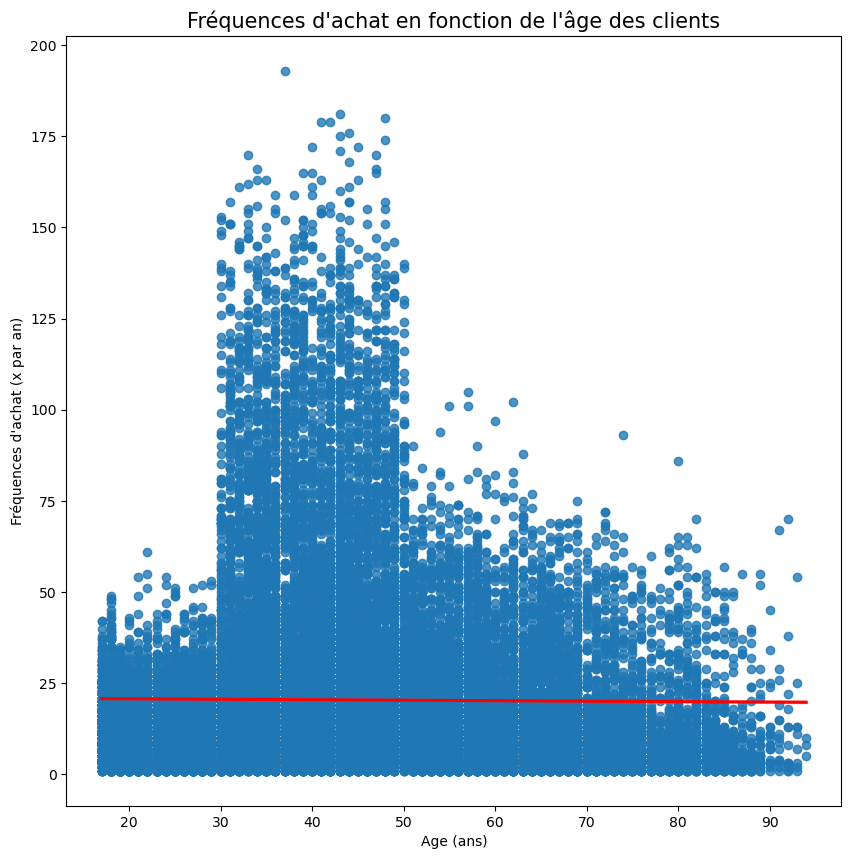

In [99]:
# Lien entre l'âge d'un client et la fréquence d'achat

## Choix du test : test de Spearman
    ## - 2 variables quantitatives : âge et fréquence d'achat
    ## - distribution des données non normale dans la majorité des groupes
    ## - moins de 20 individus dans certains échantillons


## Création du dataframe contenant les données à analyser 

df_frequences_2 = df_stats.loc[:, ["client_id", "age", "date", "session_id"]]                                        # récupère les colonnes utiles pour cette analyse dans un nouveau dataframe
start_date = df_frequences_2["date"].min()                                                                           # récupère la date de départ pour le calcul des périodes de 1 an 
                                                                                                                     # => les données ne commencent pas au 01/01/2021 et ne finissent pas au 31/12/2022, nous ne pouvons donc pas utiliser les années calendaires classiques
df_frequences_2["date"] = (df_frequences_2["date"] - start_date).dt.days                                             # compte le nombre de jours entre la date selectionnée et la date de départ
df_frequences_2["date"] = df_frequences_2["date"].apply(lambda x : "2021-2022" if x <= 365 else "2022-2023")         # affiche le nom de la période de 1 an correspondante en fonction du nombre de jours écoulés depuis la date de départ (base 365 jours = 1 an)
df_frequences_2 = df_frequences_2.groupby(["client_id", "age", "date"]).count().reset_index()                        # agrégation des données pour obtenir nombre de transactions effectuées par an par chaque client
df_frequences_2.rename(columns = {"session_id" : "freq_achat_an"}, inplace = True)                                   # renomme la colonne "session_id" en "fréquence d'achat par an" (ou "nombre moyen de transactions par an") pour plus de clarté de l'information observée
                                                                                                                     # => exemple : 6 x / an = environ tous les 2 mois

ages = df_frequences_2["age"].unique().tolist()                                                                      # récupère les valeurs de ages des clients (exemple : 17, 25, 39, etc.)


## Test de Normalité de la distibution des données dans les groupes : test de Kolmogorov-Smirnov (50 < n < 2000 dans les groupes)
    ## H0 = les données suivent une distribution normale (hypothèse nulle)
    ## H1 = les données ne suivent pas une distribution normale 
    ## seuil d'erreur = 5% (0.05)

for age in  ages :
    frequences = df_frequences_2.loc[df_frequences_2["age"] == age, "freq_achat_an"]                                  # récupère toutes les fréquences d'achats pour les clients en fonction de leur age
    n_frequences = frequences.count()                                                                                 # compte le nombre de valeurs de fréquences d'achats parmi les valeurs du groupe
    from scipy.stats import kstest, norm
    mu, std = norm.fit(frequences)                                                                                    # calcule la moyenne et l'écart-type des fréquences d'achats de chaque groupe d'âge
    ks_stat_frequences, p_value_frequences = kstest(frequences, "norm", args = (mu, std))                             # applique le test de Kolmogorov-Smirnov sur les frequences de chaque groupe pour tester la normalité de la distribution des données 
                                                                                                                      # => "norm" permet de comparer la distribution du groupe à une distribution normale
    print(f"Test de Normalité de la distribution des données :")
    print(f"Il y a {n_frequences} observations (valeurs) dans le groupe '{age}'.")
    print(f"Résultat du test : {ks_stat_frequences : .2f}")                                                           # stat = mesure l'écart des données à la normalité (plus la valeur est haute, plus la distribution s'éloigne de la normalité)
    print(f"Valeur p : {p_value_frequences : .3f}")                                                                   # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
    if p_value_frequences < 0.05 :                                                                                    # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
        print("Rejet de H0 : les données des frequences d'achat des clients ne suivent pas une distribution normale.")
    else :
        print("H0 acceptée : les données des frequences d'achat des clients suivent une distribution normale.") 
    print(f"\n")                                                                                                      # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité


## Test de Spearman
    ## H0 = les 2 variables sont indépendantes (= 0)
    ## H1 = Les 2 variables ne sont pas indépendantes (proche de +/- 1)
    ## seuil d'erreur = 5% (0.05)

from scipy.stats import spearmanr
corr_frequences, p_value_spear_frequences = spearmanr(df_frequences_2["age"], df_frequences_2["freq_achat_an"])        # applique le test de Spearman sur les données des fréquences de chaque groupe pour tester l'indépendance des variables
print(f"Test de Spearman :")
print(f"Résultat du test : {corr_frequences : .2f}")
print(f"Valeur p : {p_value_spear_frequences : .3f}")                                                                  # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
if p_value_spear_frequences < 0.05 :                                                                                   # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
    print("Rejet de H0 : il existe une corrélation significative entre les 2 variables (même faible).")
else :
    print("H0 acceptée : les 2 variables sont indépendantes.") 
print(f"\n")                                                                                                           # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité


## Graphique bivarié : nuage de points

plt.figure(figsize = (10, 10))                                                                                         # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
nuage_frequences = sns.regplot(data = df_frequences_2, x = "age", y = "freq_achat_an", line_kws={"color": "red"}  )    # création du nuage de point représentant les fréquences d'achat en fonction de l'âge des clients
plt.title("Fréquences d'achat en fonction de l'âge des clients", fontsize = 15)                                        # ajoute un titre au graphique
plt.ylabel("Fréquences d'achat (x par an)")
plt.xlabel("Age (ans)")
plt.show()


Test de Normalité de la distribution des données :
Il y a 320 observations (valeurs) dans le groupe '66'.
Résultat du test :  0.16
Valeur p :  0.000
Rejet de H0 : les données des paniers moyens des clients ne suivent pas une distribution normale.


Test de Normalité de la distribution des données :
Il y a 309 observations (valeurs) dans le groupe '67'.
Résultat du test :  0.21
Valeur p :  0.000
Rejet de H0 : les données des paniers moyens des clients ne suivent pas une distribution normale.


Test de Normalité de la distribution des données :
Il y a 250 observations (valeurs) dans le groupe '68'.
Résultat du test :  0.18
Valeur p :  0.000
Rejet de H0 : les données des paniers moyens des clients ne suivent pas une distribution normale.


Test de Normalité de la distribution des données :
Il y a 344 observations (valeurs) dans le groupe '65'.
Résultat du test :  0.16
Valeur p :  0.000
Rejet de H0 : les données des paniers moyens des clients ne suivent pas une distribution normale.


Test

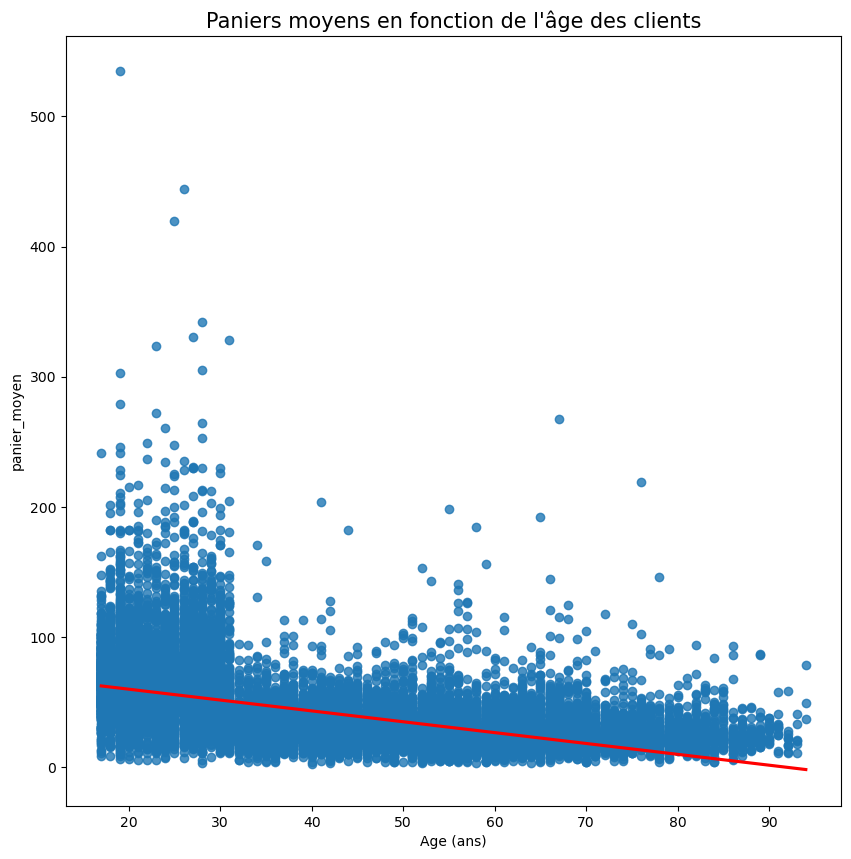

In [100]:
# Lien entre l'âge d'un client et la taille du panier moyen

## Choix du test : test de Spearman
    ## - 2 variables quantitatives : âge et taille du panier moyen
    ## - distribution des données non normale dans la majorité des groupes
    ## - moins de 20 individus dans certains échantillons


## Création du dataframe contenant les données à analyser 

df_panier_2 = df_stats.loc[:, ["client_id", "age", "session_id", "price"]]                                     # récupère les colonnes utiles pour cette analyse dans un nouveau dataframe
df_panier_2 = df_panier_2.groupby(["client_id", "age", "session_id"]).sum().reset_index()                      # agrégation des données pour obtenir le montant total des achats de chaque client par session d'achat
df_panier_2.drop(columns = "session_id", inplace = True)                                                       # suppression de la colonne "session_id" car nous n'en avons plus besoin pour cette analyse
df_panier_2 = df_panier_2.groupby(["client_id", "age"]).mean().round(2).reset_index()                          # agrégation des données pour obtenir la taille du panier moyen de chaque client
df_panier_2.rename(columns = {"price" : "panier_moyen"}, inplace = True)                                       # renomme la colonne "price" en panier_moyen pour plus de clarté de l'information observée

ages = df_panier_2["age"].unique().tolist()                                                                    # récupère les valeurs de ages des clients (exemple : 17, 25, 39, etc.)


## Test de Normalité de la distibution des données dans les groupes : test de Kolmogorov-Smirnov (50 < n < 2000 dans les groupes)
    ## H0 = les données suivent une distribution normale (hypothèse nulle)
    ## H1 = les données ne suivent pas une distribution normale 
    ## seuil d'erreur = 5% (0.05)

for age in  ages :
    paniers = df_panier_2.loc[df_panier_2["age"] == age, "panier_moyen"]                                       # récupère tous les paniers moyens pour les clients en fonction de leur age
    n_paniers = paniers.count()                                                                                # compte le nombre de valeurs de paniers moyens parmi les valeurs du groupe
    from scipy.stats import kstest, norm
    mu, std = norm.fit(paniers)                                                                                # calcule la moyenne et l'écart-type des paniers moyens de chaque groupe d'âge
    ks_stat_paniers, p_value_paniers = kstest(paniers, "norm", args = (mu, std))                               # applique le test de Kolmogorov-Smirnov sur les paniers moyens de chaque groupe pour tester la normalité de la distribution des données 
                                                                                                               # => "norm" permet de comparer la distribution du groupe à une distribution normale
    print(f"Test de Normalité de la distribution des données :")
    print(f"Il y a {n_paniers} observations (valeurs) dans le groupe '{age}'.")
    print(f"Résultat du test : {ks_stat_paniers : .2f}")                                                       # stat = mesure l'écart des données à la normalité (plus la valeur est haute, plus la distribution s'éloigne de la normalité)
    print(f"Valeur p : {p_value_paniers : .3f}")                                                               # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
    if p_value_paniers < 0.05 :                                                                                # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
        print("Rejet de H0 : les données des paniers moyens des clients ne suivent pas une distribution normale.")
    else :
        print("H0 acceptée : les données des paniers moyens des clients suivent une distribution normale.") 
    print(f"\n")                                                                                               # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité


## Test de Spearman
    ## H0 = les 2 variables sont indépendantes (= 0)
    ## H1 = Les 2 variables ne sont pas indépendantes (proche de +/- 1)
    ## seuil d'erreur = 5% (0.05)

from scipy.stats import spearmanr
corr_paniers, p_value_spear_paniers = spearmanr(df_panier_2["age"], df_panier_2["panier_moyen"])              # applique le test de Spearman sur les données des paniers moyens de chaque groupe pour tester l'indépendance des variables
print(f"Test de Spearman :")
print(f"Résultat du test : {corr_paniers : .2f}")
print(f"Valeur p : {p_value_spear_paniers : .3f}")                                                            # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
if p_value_spear_paniers < 0.05 :                                                                             # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
    print("Rejet de H0 : il existe une corrélation significative entre les 2 variables (même faible).")
else :
    print("H0 acceptée : les 2 variables sont indépendantes.") 
print(f"\n")                                                                                                  # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité


## Graphique bivarié : nuage de points

plt.figure(figsize = (10, 10))                                                                                # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
nuage_paniers = sns.regplot(data = df_panier_2, x = "age", y = "panier_moyen", line_kws={"color": "red"}  )   # création du nuage de point représentant les paniers moyens en fonction de l'âge des clients
plt.title("Paniers moyens en fonction de l'âge des clients", fontsize = 15)                                   # ajoute un titre au graphique
plt.xlabel("Paniers moyens (€)")
plt.xlabel("Age (ans)")
plt.show()


Test de Normalité de la distribution des données :
Il y a 320 observations (valeurs) dans le groupe '66'.
Résultat du test :  0.14
Valeur p :  0.000
Rejet de H0 : les données des transactions des clients ne suivent pas une distribution normale.


Test de Normalité de la distribution des données :
Il y a 309 observations (valeurs) dans le groupe '67'.
Résultat du test :  0.20
Valeur p :  0.000
Rejet de H0 : les données des transactions des clients ne suivent pas une distribution normale.


Test de Normalité de la distribution des données :
Il y a 250 observations (valeurs) dans le groupe '68'.
Résultat du test :  0.15
Valeur p :  0.000
Rejet de H0 : les données des transactions des clients ne suivent pas une distribution normale.


Test de Normalité de la distribution des données :
Il y a 344 observations (valeurs) dans le groupe '65'.
Résultat du test :  0.15
Valeur p :  0.000
Rejet de H0 : les données des transactions des clients ne suivent pas une distribution normale.


Test de Norm

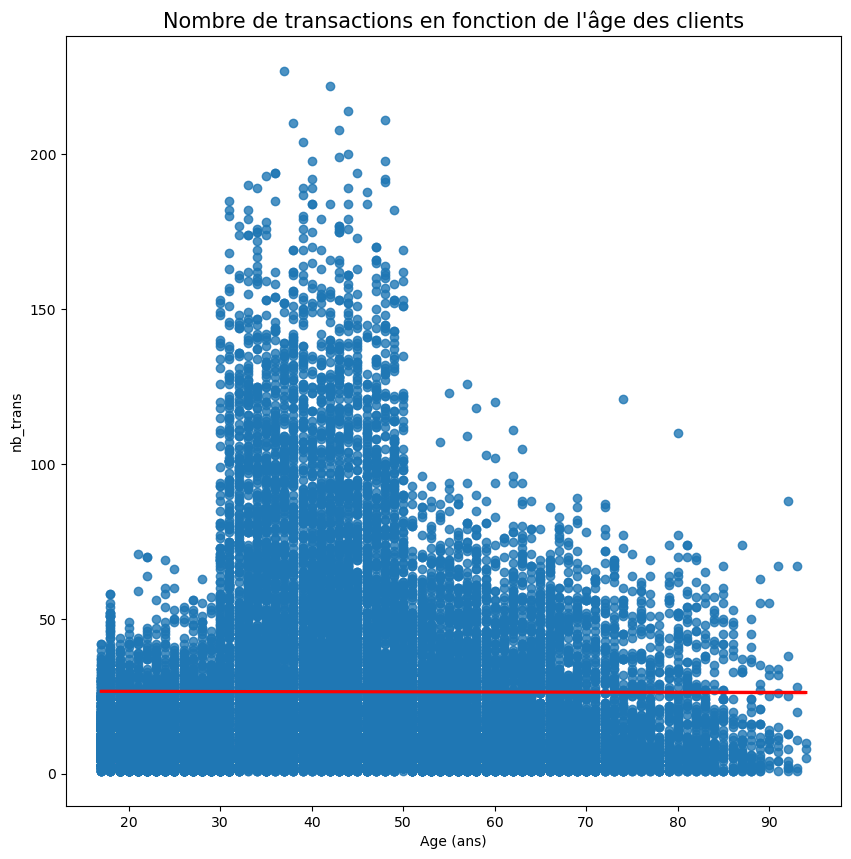

In [101]:
# Lien entre l'âge d'un client et le nombre de transactions

## Choix du test : test de Spearman
    ## - 2 variables quantitatives : âge et nombre de transactions
    ## - distribution des données non normale dans la majorité des groupes
    ## - moins de 20 individus dans certains échantillons


## Création du dataframe contenant les données à analyser 

df_trans_stats_2 = df_stats.loc[:, ["client_id", "age", "session_id"]]                                       # récupère les colonnes utiles pour cette analyse dans un nouveau dataframe
df_trans_stats_2 = df_trans_stats_2.groupby(["client_id", "age"]).count().reset_index()                      # agrégation des données pour obtenir le nombre total de transactions de chaque client
df_trans_stats_2.rename(columns = {"session_id" : "nb_trans"}, inplace = True)                               # renomme la colonne "session_id" en nombre de transactions pour plus de clarté de l'information observée

ages = df_trans_stats_2["age"].unique().tolist()                                                             # récupère les valeurs de ages des clients (exemple : 17, 25, 39, etc.)


## Test de Normalité de la distibution des données dans les groupes : test de Kolmogorov-Smirnov (50 < n < 2000 dans les groupes)
    ## H0 = les données suivent une distribution normale (hypothèse nulle)
    ## H1 = les données ne suivent pas une distribution normale 
    ## seuil d'erreur = 5% (0.05)

for age in  ages :
    transactions = df_trans_stats_2.loc[df_trans_stats_2["age"] == age, "nb_trans"]                          # récupère toutes les transactions pour les clients en fonction de leur age
    n_trans = transactions.count()                                                                           # compte le nombre de valeurs de transactions parmi les valeurs du groupe
    from scipy.stats import kstest, norm
    mu, std = norm.fit(transactions)                                                                         # calcule la moyenne et l'écart-type des transactions de chaque groupe d'âge
    ks_stat_trans, p_value_trans = kstest(transactions, "norm", args = (mu, std))                            # applique le test de Kolmogorov-Smirnov sur les transactions de chaque groupe pour tester la normalité de la distribution des données 
                                                                                                             # => "norm" permet de comparer la distribution du groupe à une distribution normale
    print(f"Test de Normalité de la distribution des données :")
    print(f"Il y a {n_trans} observations (valeurs) dans le groupe '{age}'.")
    print(f"Résultat du test : {ks_stat_trans : .2f}")                                                       # stat = mesure l'écart des données à la normalité (plus la valeur est haute, plus la distribution s'éloigne de la normalité)
    print(f"Valeur p : {p_value_trans : .3f}")                                                               # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
    if p_value_trans < 0.05 :                                                                                # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
        print("Rejet de H0 : les données des transactions des clients ne suivent pas une distribution normale.")
    else :
        print("H0 acceptée : les données des transactions des clients suivent une distribution normale.") 
    print(f"\n")                                                                                             # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité


## Test de Spearman
    ## H0 = les 2 variables sont indépendantes (= 0)
    ## H1 = Les 2 variables ne sont pas indépendantes (proche de +/- 1)
    ## seuil d'erreur = 5% (0.05)

from scipy.stats import spearmanr
corr_trans, p_value_spear_trans = spearmanr(df_trans_stats_2["age"], df_trans_stats_2["nb_trans"])           # applique le test de Spearman sur les données des transactions de chaque groupe pour tester l'indépendance des variables
print(f"Test de Spearman :")
print(f"Résultat du test : {corr_trans : .2f}")
print(f"Valeur p : {p_value_spear_trans : .3f}")                                                             # p_value = probabilité en % de risque de rejetter l'hypothèse nulle à tord => doit être > 5% (seuil d'erreur) pour valider H0
if p_value_spear_trans < 0.05 :                                                                              # teste la probabilité d'avoir raison (p_value) pour valider ou non l'hypothèse nulle
    print("Rejet de H0 : il existe une corrélation significative entre les 2 variables (même faible).")
else :
    print("H0 acceptée : les 2 variables sont indépendantes.") 
print(f"\n")                                                                                                 # permet de sauter 1 ligne entre les 2 tests pour plus de lisibilité


## Graphique bivarié : nuage de points

plt.figure(figsize = (10, 10))                                                                                # ajuste les dimensions du graphique pour plus de lisibilité (largeur et longueur en pouces)
nuage_trans = sns.regplot(data = df_trans_stats_2, x = "age", y = "nb_trans", line_kws={"color": "red"}  )   # création du nuage de point représentant lestransactions en fonction de l'âge des clients
plt.title("Nombre de transactions en fonction de l'âge des clients", fontsize = 15)                          # ajoute un titre au graphique
plt.xlabel("Nombre de transactions")
plt.xlabel("Age (ans)")
plt.show()
